s_co = 2.5
C1   = 1.949199e+22  (m^-3)
n*   = 70
J(t_max) = 5.731246e-05  (m^-3 s^-1)


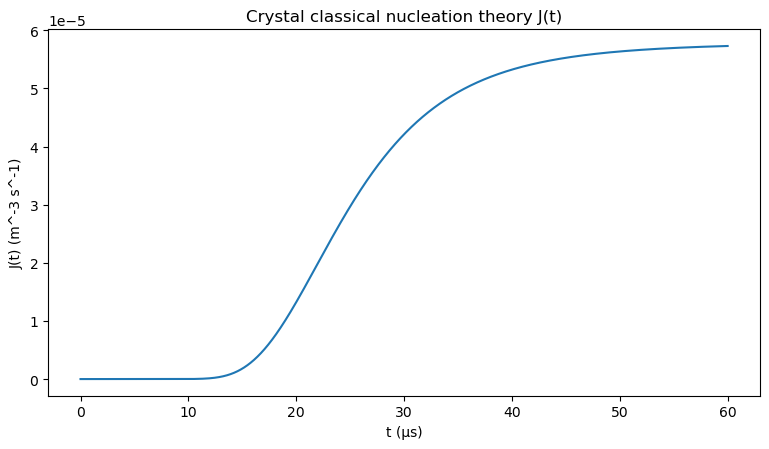

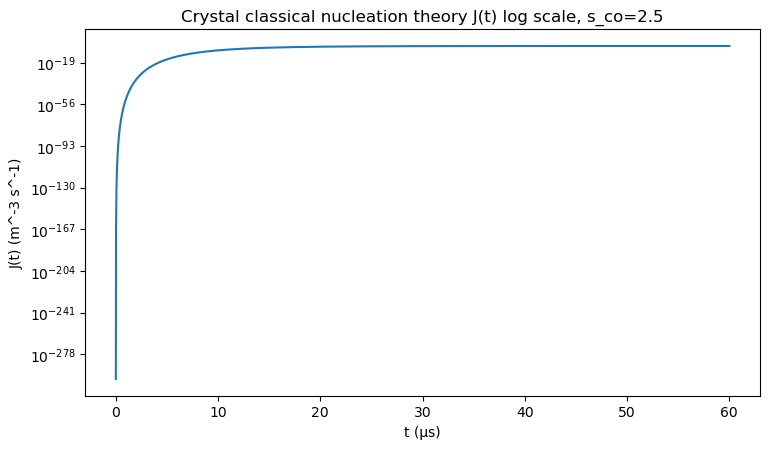

In [6]:
import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# =========================
# parameters
# =========================
T = 220.0
s_co = 2.5
gamma_co = 15.4
f0 = 1.0e5
C1_base = 1.6e21
M = 240

t_max  = 60e-6
N_eval = 3000
t_eval = np.linspace(0.0, t_max, N_eval)
t_us = t_eval * 1e6

max_step = 1e-7
rtol = 1e-8
atol = 1e-11

# =========================
# derived quantities
# =========================
C1 = C1_base * np.exp(s_co)

n_star = int(np.ceil((2.0 * gamma_co / (3.0 * s_co)) ** 3))
if n_star >= M:
    raise ValueError("n_star must be smaller than M")

def w_crystal_1s(n):
    return -s_co * n + gamma_co * (n ** (2.0 / 3.0))

n_all = np.arange(1, M + 1, dtype=float)      # 1..M
w_all = w_crystal_1s(n_all)
dw = w_all[1:] - w_all[:-1]                    # delta w for n=1..M-1

n = np.arange(1, M, dtype=float)               # 1..M-1
O = 4.0 * (n ** (2.0 / 3.0))                   # O(n)

k_plus = np.zeros(M + 1)                       # index 1..M-1 used
k_minus = np.zeros(M + 1)                      # index 2..M used

k_plus[1:M] = f0 * O * np.exp(-0.5 * dw)
k_minus[2:M+1] = f0 * O * np.exp(+0.5 * dw)

# unknowns are c2..c_{M-1}
Nvar = M - 2

# tri diagonal sparsity for BDF
S = sp.diags(
    diagonals=[np.ones(Nvar), np.ones(Nvar - 1), np.ones(Nvar - 1)],
    offsets=[0, -1, 1],
    format="csr",
    dtype=bool
)

def rhs(t, y):
    c = np.zeros(M + 1)
    c[1] = C1
    c[2:M] = y
    c[M] = 0.0

    flux = np.zeros(M + 1)
    flux[1:M] = c[1:M] * k_plus[1:M] - c[2:M+1] * k_minus[2:M+1]

    dc = np.zeros(M + 1)
    dc[2:M] = flux[1:M-1] - flux[2:M]

    return dc[2:M]

y0 = np.zeros(Nvar)

sol = solve_ivp(
    fun=rhs,
    t_span=(0.0, t_max),
    y0=y0,
    method="BDF",
    t_eval=t_eval,
    jac_sparsity=S,
    rtol=rtol,
    atol=atol,
    max_step=max_step
)

if not sol.success:
    raise RuntimeError(sol.message)

# =========================
# compute J(t) = flux at n_star
# =========================
Y = sol.y

if n_star == 1:
    c_n = np.full_like(sol.t, C1, dtype=float)
else:
    c_n = Y[n_star - 2, :]

if n_star + 1 == M:
    c_np1 = np.zeros_like(sol.t, dtype=float)
else:
    c_np1 = Y[n_star - 1, :]

J_t = c_n * k_plus[n_star] - c_np1 * k_minus[n_star + 1]

print(f"s_co = {s_co}")
print(f"C1   = {C1:.6e}  (m^-3)")
print(f"n*   = {n_star}")
print(f"J(t_max) = {J_t[-1]:.6e}  (m^-3 s^-1)")

# =========================
# plot
# =========================
plt.figure(figsize=(7.8, 4.6))
plt.plot(t_us, J_t)
plt.xlabel("t (μs)")
plt.ylabel("J(t) (m^-3 s^-1)")
plt.title(f"Crystal classical nucleation theory J(t)")
plt.tight_layout()
plt.show()

# log scale plot to see early time rise clearly
eps = 1e-300
plt.figure(figsize=(7.8, 4.6))
plt.semilogy(t_us, np.maximum(J_t, eps))
plt.xlabel("t (μs)")
plt.ylabel("J(t) (m^-3 s^-1)")
plt.title(f"Crystal classical nucleation theory J(t) log scale, s_co={s_co}")
plt.tight_layout()
plt.show()


[Stage] s_co=2.5: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…
[Done]  s_co=2.5: 전체 map 훑어보기 완료
[Progress] s_co=2.5: 출력 step 0/2999 (t=0.000 μs) 완료
[Progress] s_co=2.5: 출력 step 10/2999 (t=0.200 μs) 완료
[Progress] s_co=2.5: 출력 step 20/2999 (t=0.400 μs) 완료
[Progress] s_co=2.5: 출력 step 30/2999 (t=0.600 μs) 완료
[Progress] s_co=2.5: 출력 step 40/2999 (t=0.800 μs) 완료
[Progress] s_co=2.5: 출력 step 50/2999 (t=1.000 μs) 완료
[Progress] s_co=2.5: 출력 step 60/2999 (t=1.200 μs) 완료
[Progress] s_co=2.5: 출력 step 70/2999 (t=1.400 μs) 완료
[Progress] s_co=2.5: 출력 step 80/2999 (t=1.601 μs) 완료
[Progress] s_co=2.5: 출력 step 90/2999 (t=1.801 μs) 완료
[Progress] s_co=2.5: 출력 step 100/2999 (t=2.001 μs) 완료
[Progress] s_co=2.5: 출력 step 110/2999 (t=2.201 μs) 완료
[Progress] s_co=2.5: 출력 step 120/2999 (t=2.401 μs) 완료
[Progress] s_co=2.5: 출력 step 130/2999 (t=2.601 μs) 완료
[Progress] s_co=2.5: 출력 step 140/2999 (t=2.801 μs) 완료
[Progress] s_co=2.5: 출력 step 150/2999 (t=3.001 μs) 완료
[Progress] s_co=2.5: 출력 step 160/2999 (t=3.201 μs) 완료
[

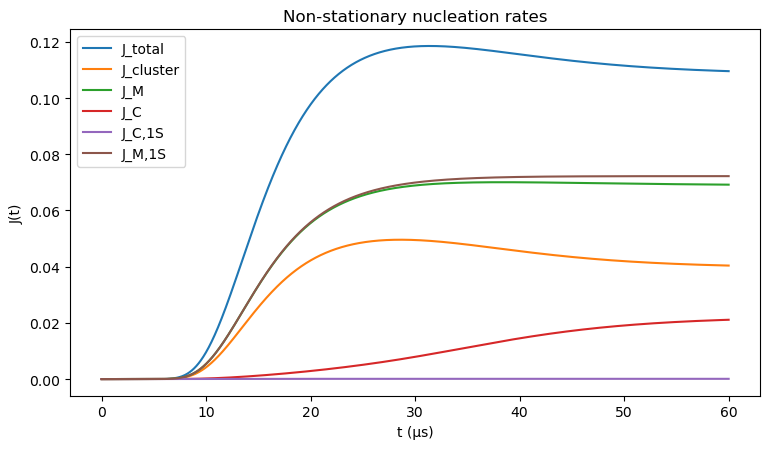

[Stage] s_co=3.0: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…
[Done]  s_co=3.0: 전체 map 훑어보기 완료
[Progress] s_co=3.0: 출력 step 0/2999 (t=0.000 μs) 완료
[Progress] s_co=3.0: 출력 step 10/2999 (t=0.200 μs) 완료
[Progress] s_co=3.0: 출력 step 20/2999 (t=0.400 μs) 완료
[Progress] s_co=3.0: 출력 step 30/2999 (t=0.600 μs) 완료
[Progress] s_co=3.0: 출력 step 40/2999 (t=0.800 μs) 완료
[Progress] s_co=3.0: 출력 step 50/2999 (t=1.000 μs) 완료
[Progress] s_co=3.0: 출력 step 60/2999 (t=1.200 μs) 완료
[Progress] s_co=3.0: 출력 step 70/2999 (t=1.400 μs) 완료
[Progress] s_co=3.0: 출력 step 80/2999 (t=1.601 μs) 완료
[Progress] s_co=3.0: 출력 step 90/2999 (t=1.801 μs) 완료
[Progress] s_co=3.0: 출력 step 100/2999 (t=2.001 μs) 완료
[Progress] s_co=3.0: 출력 step 110/2999 (t=2.201 μs) 완료
[Progress] s_co=3.0: 출력 step 120/2999 (t=2.401 μs) 완료
[Progress] s_co=3.0: 출력 step 130/2999 (t=2.601 μs) 완료
[Progress] s_co=3.0: 출력 step 140/2999 (t=2.801 μs) 완료
[Progress] s_co=3.0: 출력 step 150/2999 (t=3.001 μs) 완료
[Progress] s_co=3.0: 출력 step 160/2999 (t=3.201 μs) 완료
[

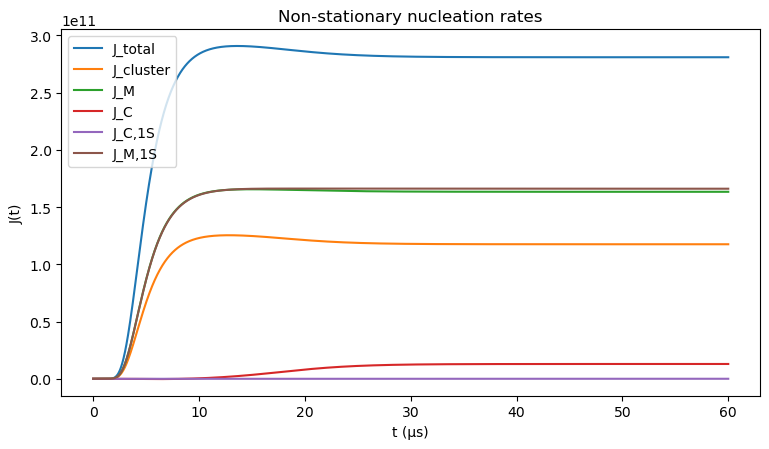

[Stage] s_co=5.0: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…
[Done]  s_co=5.0: 전체 map 훑어보기 완료
[Progress] s_co=5.0: 출력 step 0/2999 (t=0.000 μs) 완료
[Progress] s_co=5.0: 출력 step 10/2999 (t=0.200 μs) 완료
[Progress] s_co=5.0: 출력 step 20/2999 (t=0.400 μs) 완료
[Progress] s_co=5.0: 출력 step 30/2999 (t=0.600 μs) 완료
[Progress] s_co=5.0: 출력 step 40/2999 (t=0.800 μs) 완료
[Progress] s_co=5.0: 출력 step 50/2999 (t=1.000 μs) 완료
[Progress] s_co=5.0: 출력 step 60/2999 (t=1.200 μs) 완료
[Progress] s_co=5.0: 출력 step 70/2999 (t=1.400 μs) 완료
[Progress] s_co=5.0: 출력 step 80/2999 (t=1.601 μs) 완료
[Progress] s_co=5.0: 출력 step 90/2999 (t=1.801 μs) 완료
[Progress] s_co=5.0: 출력 step 100/2999 (t=2.001 μs) 완료
[Progress] s_co=5.0: 출력 step 110/2999 (t=2.201 μs) 완료
[Progress] s_co=5.0: 출력 step 120/2999 (t=2.401 μs) 완료
[Progress] s_co=5.0: 출력 step 130/2999 (t=2.601 μs) 완료
[Progress] s_co=5.0: 출력 step 140/2999 (t=2.801 μs) 완료
[Progress] s_co=5.0: 출력 step 150/2999 (t=3.001 μs) 완료
[Progress] s_co=5.0: 출력 step 160/2999 (t=3.201 μs) 완료
[

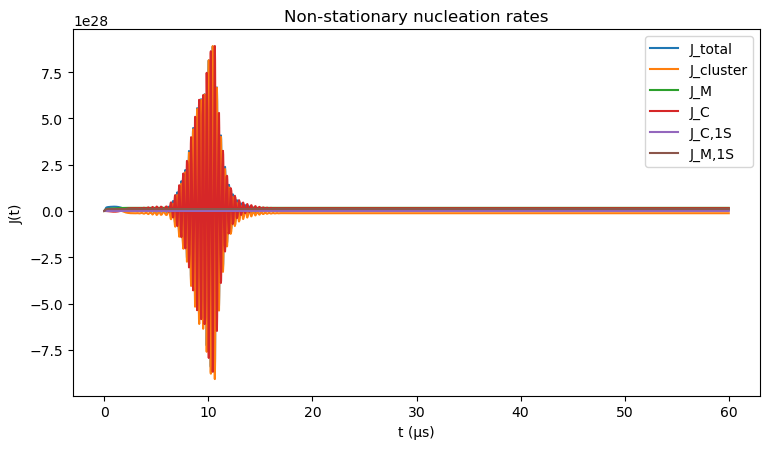

In [3]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# - Memory-safe: triangular indexing + jac_sparsity
# - Time-step: BDF (adaptive) + max_step control
# - Progress prints: stage marks + every 10 output steps
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 220.0
SCO_LIST = [2.5, 3.0, 5.0]
s_cm = 0.5
gamma_co, gamma_cm, gamma_mo = 15.4, 2.6, 12.8  # gamma_co = gamma_cm + gamma_mo
f0 = 1.0e5
g0 = 2.0e7
Q  = 0.5
C1_base = 1.6e21  # C1 = C1_base * exp(s_co)
M = 240

# runtime window & sampling
t_max  = 60e-6               # 60 microseconds
N_eval = 3000                # 출력 샘플 개수
t_eval = np.linspace(0.0, t_max, N_eval)
x_eval = f0 * t_eval         # solver works in x = f0 t
max_step = 1e-7              # sec
max_dx   = f0 * max_step     # x-domain step ceiling

# ------------------------
# 1) UTILS: triangular indexing (1 <= n <= i <= M-1)
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i,n)] = k
            idx2pair.append((i,n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo): return -s_mo * i + gamma_mo * i**(2/3)
def w_cm(n):        return -s_cm * n + gamma_cm * n**(2/3)
def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k,(i,n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1,1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2*gamma_mo / (3*s_mo))**3
    n_star   = (2*gamma_cm / (3*s_cm))**3
    ico_star = (2*gamma_co / (3*s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 3) Attachment frequencies (as specified)
# ------------------------
def f_in_val(i, s_co): return (1.0 - Q) * f0 * np.exp(s_co) * (i**(2/3))
def g_in_val(n):       return g0 * np.exp(s_cm) * (n**(2/3))
def k_ii_val(i, s_co): return Q * f0 * np.exp(s_co) * (i**(2/3))

def build_coeffs(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)
    Wmap = {(i,n): W[PAIR2IDX[(i,n)]] for (i,n) in PAIR2IDX}

    for k,(i,n) in enumerate(IDX2PAIR):
        if n < i:
            b[k] = f_in_val(i, s_co) / f0
            d[k] = g_in_val(n)       / f0
            if i >= 2:  # need (i-1,n) to exist AND n <= i-1 (holds since n<i)
                a[k] = (f_in_val(i-1, s_co)/f0) * np.exp(Wmap[(i,n)] - Wmap[(i-1,n)])
            if n >= 2:  # need (i,n-1)
                c[k] = (g_in_val(n-1)/f0)       * np.exp(Wmap[(i,n)] - Wmap[(i,n-1)])
        else:  # n == i
            if i >= 2:
                e[k] = (k_ii_val(i-1, s_co)/f0) * np.exp(Wmap[(i,i)] - Wmap[(i-1,i-1)])
            h[k] =  (k_ii_val(i,   s_co)/f0)
    return a,b,c,d,e,h

# ------------------------
# 4) Sparse Jacobian pattern (neighbor stencil)  **FIXED**
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []
    def add(r,c):
        rows.append(r); cols.append(c)

    for k,(i,n) in enumerate(IDX2PAIR):
        # self
        add(k,k)
        # (i-1, n) exists only if i-1 >= 1 and n <= i-1   <-- FIX
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        # (i+1, n) exists only if i+1 <= M-1 and n <= i+1 (always true if n<=i, but keep explicit)
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        # (i, n-1)
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        # (i, n+1) only if n+1 <= i
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        # diagonal neighbors when n == i
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)), shape=(Ntri, Ntri))
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x-domain (Eq.(6)): dF/dx = ...
# ------------------------
def dFdx(x, F_flat, a,b,c,d,e,h):
    F = F_flat
    dF = np.zeros_like(F)

    # enforce boundary F(1,1)=1
    F[PAIR2IDX[(1,1)]] = 1.0

    for k,(i,n) in enumerate(IDX2PAIR):
        val = 0.0
        # a(F_{i-1,n}-F_{i,n})
        if n < i and i >= 2:
            val += a[k]*(F[PAIR2IDX[(i-1,n)]] - F[k])
        # - b(F_{i,n}-F_{i+1,n})
        if n < i:
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            val -= b[k]*(F[k] - Fip)
        # c(F_{i,n-1}-F_{i,n})
        if n >= 2:
            val += c[k]*(F[PAIR2IDX[(i, n-1)]] - F[k])
        # - d(F_{i,n}-F_{i,n+1})
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k]*(F[k] - Finp)
        # + e(F_{i-1,i-1}-F_{i,i}) - h(F_{i,i}-F_{i+1,i+1})
        if n == i:
            if i >= 2:
                val += e[k]*(F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k]*(F[k] - Fipp)
        dF[k] = val
    return dF

# ------------------------
# 6) Fluxes I,G,K (for J(t))
# ------------------------
def fluxes_IGK(F_flat, C, s_co):
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat

    for (i,n),k in PAIR2IDX.items():
        Ckn = C[k]
        # I_{i,n} (n<i)
        if n < i:
            fval = f_in_val(i, s_co)
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            I_map[(i,n)] = fval * Ckn * (F[k] - Fip)
        # G_{i,n} (n<i)
        if n < i:
            gval = g_in_val(n)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i,n)] = gval * Ckn * (F[k] - Finp)
        # K_{i,i}
        if n == i:
            kval = k_ii_val(i, s_co)
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i,i)] = kval * Ckn * (F[k] - Fipp)
    return I_map, G_map, K_map

# ------------------------
# 7) Non-stationary rates
# ------------------------
def compute_Js(F_flat, C, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, s_co)

    gi = lambda i,n: G_map.get((i,n), 0.0)
    ii = lambda i,n: I_map.get((i,n), 0.0)
    kk = lambda i:    K_map.get((i,i), 0.0)

    # J_{d+com}
    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i,i) - gi(i, i-1)

    # J_d
    J_d = ii(i_star,1) - sum(gi(i,1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    # J_c
    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i,i)

    # 1S limits (as per user’s S35,S36 interpretation)
    J_c_1S = kk(ico_star)      # Q=1 channel
    J_d_1S = ii(i_star, 1)     # Q=0 channel

    return {"J_d+com":J_dcom, "J_com":J_com, "J_d":J_d, "J_c":J_c, "J_c,1S":J_c_1S, "J_d,1S":J_d_1S}

# ------------------------
# 8) MAIN SESSION
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co}: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…")
    W, C = make_wC(s_co)
    a,b,c,d,e,h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co}: 전체 map 훑어보기 완료")  # ①

    # Initial condition: F(1,1)=1, others 0
    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1,1)]] = 1.0

    # BDF integrate in x with jac_sparsity & max_step
    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a,b,c,d,e,h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method='BDF',
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6, atol=1e-9,
        max_step=max_dx
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    # compute nonstationary rates and print progress every 10 steps
    curves = {k: np.zeros_like(sol.t) for k in ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]}
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, s_co)
        for k in curves.keys():
            curves[k][j] = Js[k]

        if j % 10 == 0:
            print(f"[Progress] s_co={s_co}: 출력 step {j}/{len(sol.t)-1} (t={x/f0*1e6:.3f} μs) 완료")  # ②

    print(f"[Done]  s_co={s_co}: 전체 계산 완료")  # ③

    # plot
    label_map = {
        "J_d+com": "J_total",
        "J_com":   "J_cluster",
        "J_d":     "J_M",
        "J_c":     "J_C",
        "J_c,1S":  "J_C,1S",
        "J_d,1S":  "J_M,1S"
    }

    plt.figure(figsize=(7.8,4.6))
    order = ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]
    for name in order:
        plt.plot(sol.t/f0*1e6, curves[name], label=label_map[name])
    plt.xlabel("t (μs)")
    plt.ylabel("J(t)")
    plt.title(f"Non-stationary nucleation rates")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------
# 9) RUN
# ------------------------
for sco in SCO_LIST:
    run_session(sco)


[Stage] s_co=2.5: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…
[Done]  s_co=2.5: 전체 map 훑어보기 완료
[Progress] s_co=2.5: 출력 step 0/2999 (t=0.000 μs) 완료
[Progress] s_co=2.5: 출력 step 10/2999 (t=0.200 μs) 완료
[Progress] s_co=2.5: 출력 step 20/2999 (t=0.400 μs) 완료
[Progress] s_co=2.5: 출력 step 30/2999 (t=0.600 μs) 완료
[Progress] s_co=2.5: 출력 step 40/2999 (t=0.800 μs) 완료
[Progress] s_co=2.5: 출력 step 50/2999 (t=1.000 μs) 완료
[Progress] s_co=2.5: 출력 step 60/2999 (t=1.200 μs) 완료
[Progress] s_co=2.5: 출력 step 70/2999 (t=1.400 μs) 완료
[Progress] s_co=2.5: 출력 step 80/2999 (t=1.601 μs) 완료
[Progress] s_co=2.5: 출력 step 90/2999 (t=1.801 μs) 완료
[Progress] s_co=2.5: 출력 step 100/2999 (t=2.001 μs) 완료
[Progress] s_co=2.5: 출력 step 110/2999 (t=2.201 μs) 완료
[Progress] s_co=2.5: 출력 step 120/2999 (t=2.401 μs) 완료
[Progress] s_co=2.5: 출력 step 130/2999 (t=2.601 μs) 완료
[Progress] s_co=2.5: 출력 step 140/2999 (t=2.801 μs) 완료
[Progress] s_co=2.5: 출력 step 150/2999 (t=3.001 μs) 완료
[Progress] s_co=2.5: 출력 step 160/2999 (t=3.201 μs) 완료
[

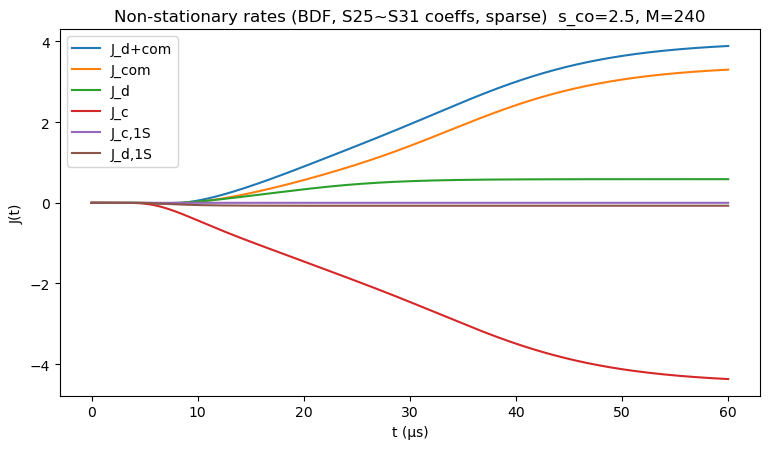

[Stage] s_co=3.0: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…
[Done]  s_co=3.0: 전체 map 훑어보기 완료
[Progress] s_co=3.0: 출력 step 0/2999 (t=0.000 μs) 완료
[Progress] s_co=3.0: 출력 step 10/2999 (t=0.200 μs) 완료
[Progress] s_co=3.0: 출력 step 20/2999 (t=0.400 μs) 완료
[Progress] s_co=3.0: 출력 step 30/2999 (t=0.600 μs) 완료
[Progress] s_co=3.0: 출력 step 40/2999 (t=0.800 μs) 완료
[Progress] s_co=3.0: 출력 step 50/2999 (t=1.000 μs) 완료
[Progress] s_co=3.0: 출력 step 60/2999 (t=1.200 μs) 완료
[Progress] s_co=3.0: 출력 step 70/2999 (t=1.400 μs) 완료
[Progress] s_co=3.0: 출력 step 80/2999 (t=1.601 μs) 완료
[Progress] s_co=3.0: 출력 step 90/2999 (t=1.801 μs) 완료
[Progress] s_co=3.0: 출력 step 100/2999 (t=2.001 μs) 완료
[Progress] s_co=3.0: 출력 step 110/2999 (t=2.201 μs) 완료
[Progress] s_co=3.0: 출력 step 120/2999 (t=2.401 μs) 완료
[Progress] s_co=3.0: 출력 step 130/2999 (t=2.601 μs) 완료
[Progress] s_co=3.0: 출력 step 140/2999 (t=2.801 μs) 완료
[Progress] s_co=3.0: 출력 step 150/2999 (t=3.001 μs) 완료
[Progress] s_co=3.0: 출력 step 160/2999 (t=3.201 μs) 완료
[

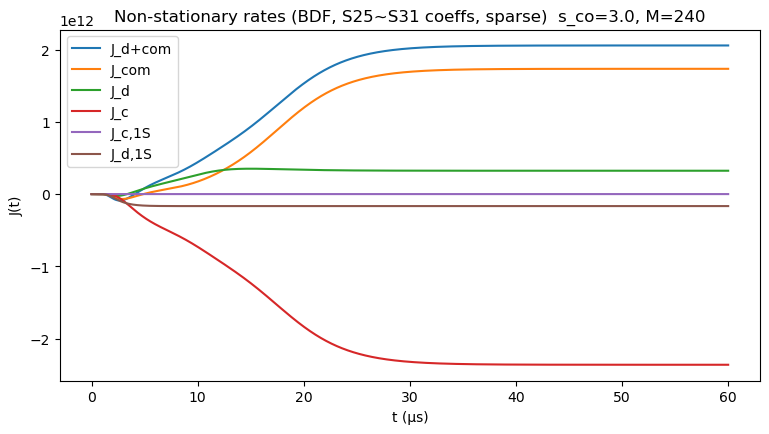

[Stage] s_co=5.0: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…
[Done]  s_co=5.0: 전체 map 훑어보기 완료
[Progress] s_co=5.0: 출력 step 0/2999 (t=0.000 μs) 완료
[Progress] s_co=5.0: 출력 step 10/2999 (t=0.200 μs) 완료
[Progress] s_co=5.0: 출력 step 20/2999 (t=0.400 μs) 완료
[Progress] s_co=5.0: 출력 step 30/2999 (t=0.600 μs) 완료
[Progress] s_co=5.0: 출력 step 40/2999 (t=0.800 μs) 완료
[Progress] s_co=5.0: 출력 step 50/2999 (t=1.000 μs) 완료
[Progress] s_co=5.0: 출력 step 60/2999 (t=1.200 μs) 완료
[Progress] s_co=5.0: 출력 step 70/2999 (t=1.400 μs) 완료
[Progress] s_co=5.0: 출력 step 80/2999 (t=1.601 μs) 완료
[Progress] s_co=5.0: 출력 step 90/2999 (t=1.801 μs) 완료
[Progress] s_co=5.0: 출력 step 100/2999 (t=2.001 μs) 완료
[Progress] s_co=5.0: 출력 step 110/2999 (t=2.201 μs) 완료
[Progress] s_co=5.0: 출력 step 120/2999 (t=2.401 μs) 완료
[Progress] s_co=5.0: 출력 step 130/2999 (t=2.601 μs) 완료
[Progress] s_co=5.0: 출력 step 140/2999 (t=2.801 μs) 완료
[Progress] s_co=5.0: 출력 step 150/2999 (t=3.001 μs) 완료
[Progress] s_co=5.0: 출력 step 160/2999 (t=3.201 μs) 완료
[

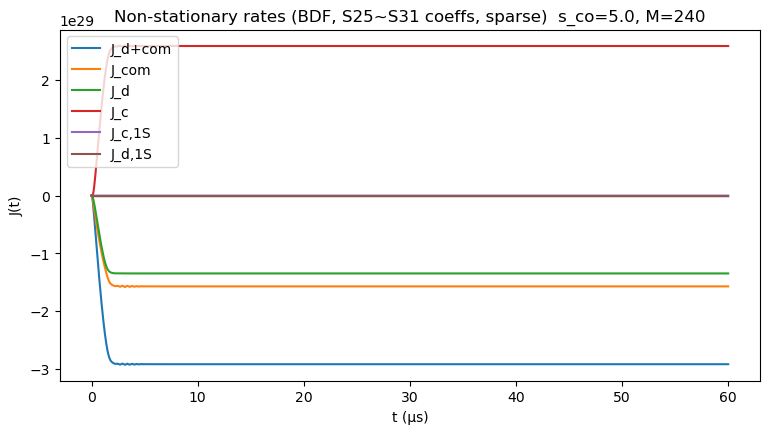

In [6]:
# ============================================================
# Two-Step Nucleation (2S) — Master equation with S25~S31 coeffs
# BDF (stiff) + sparse Jacobian + triangular indexing
# Progress prints: map scan / every 10 output steps / session done
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 220.0
SCO_LIST = [2.5, 3.0, 5.0]
s_cm = 0.5
gamma_co, gamma_cm, gamma_mo = 15.4, 2.6, 12.8
f0 = 1.0e5     # s^-1
g0 = 2.0e7     # s^-1
Q  = 0.5
L  = 200.0     # SM에서 사용
C1_base = 1.6e21         # C1 = C1_base * exp(s_co) [m^-3]
M = 240                   # size cutoff

# runtime window & sampling
t_max  = 60e-6            # 60 μs
N_eval = 3000
t_eval = np.linspace(0.0, t_max, N_eval)
x_eval = f0 * t_eval
max_step = 1e-7           # sec
max_dx   = f0 * max_step  # x-domain step ceiling

# ------------------------
# 1) Triangular indexing (1 <= n <= i <= M-1)
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i,n)] = k
            idx2pair.append((i,n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation & C(i,n)
# ------------------------
def w_mo(i, s_mo): return -s_mo * i + gamma_mo * i**(2/3)
def w_cm(n):        return -s_cm * n + gamma_cm * n**(2/3)
def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k,(i,n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1,1, s_co)
    C = C1 * np.exp(w11 - W)   # C_{i,n} = C1 exp(w11 - w_{i,n})
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2*gamma_mo / (3*s_mo))**3
    n_star   = (2*gamma_cm / (3*s_cm))**3
    ico_star = (2*gamma_co / (3*s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 3) Attachment frequencies for fluxes (physical units)
#     — S25~S31 스케일을 반영: g에 L 포함
# ------------------------
def f_in_val(i, s_co): return (1.0 - Q) * f0 * np.exp(s_co) * (i**(2/3))
def g_in_val(n):       return L * g0 * np.exp(s_cm) * (n**(2/3))
def k_ii_val(i, s_co): return Q * f0 * np.exp(s_co) * (i**(2/3))

# ------------------------
# 4) Coefficients a..h from S25~S31 (사용자 제공식 그대로 구현)
#     주의: S25~S31은 이미 무차원 계수형이므로 /f0 등을 넣지 않습니다.
# ------------------------
def build_coeffs(W_unused, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)

    def i23(x): return x**(2.0/3.0)

    for k,(i,n) in enumerate(IDX2PAIR):
        # ---- a_{i,n}
        if n < i:
            if (n == i-1) and (i >= 2):
                a[k] = (1.0 - Q) * i23(i-1) * np.exp( s_cm + gamma_mo*(i23(i) - i23(i-1)) )
            elif (n <= i-2) and (i >= 2):
                a[k] = i23(i-1) * np.exp( s_cm + gamma_mo*(i23(i) - i23(i-1)) )
        # ---- b_{i,n}
        if n == i:
            b[k] = (1.0 - Q) * i23(i) * np.exp(s_co)
        elif n <= i-1:
            b[k] = i23(i) * np.exp(s_co)
        # ---- c_{i,n}
        if n <= i-1:
            if n >= 2:
                c[k] = L * (i23(n-1)) * np.exp( gamma_cm*(i23(n) - i23(n-1)) )
            else:
                c[k] = 0.0  # c_{i,1}=0
        # ---- d_{i,n}
        if n < i:
            d[k] = L * (i23(n)) * np.exp(s_cm)
        else:
            d[k] = 0.0
        # ---- e_{i,n}
        if n == i:
            if i >= 2:
                e[k] = Q * i23(i-1) * np.exp( gamma_co*(i23(i) - i23(i-1)) )
            else:
                e[k] = 0.0
        else:
            e[k] = 0.0
        # ---- h_{i,n}
        if n == i:
            h[k] = Q * i23(i) * np.exp(s_co)
        else:
            h[k] = 0.0
    return a,b,c,d,e,h

# ------------------------
# 5) Sparse Jacobian pattern (neighbor stencil) — memory safe
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []
    def add(r,c):
        rows.append(r); cols.append(c)
    for k,(i,n) in enumerate(IDX2PAIR):
        add(k,k)  # self
        if (i-1) >= 1 and n <= (i-1): add(k, PAIR2IDX[(i-1, n)])
        if (i+1) <= (M-1) and n <= (i+1): add(k, PAIR2IDX[(i+1, n)])
        if (n-1) >= 1: add(k, PAIR2IDX[(i, n-1)])
        if (n+1) <= i: add(k, PAIR2IDX[(i, n+1)])
        if n == i:
            if (i-1) >= 1: add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1): add(k, PAIR2IDX[(i+1, i+1)])
    S = sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)), shape=(Ntri, Ntri))
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 6) RHS in x-domain
# ------------------------
def dFdx(x, F_flat, a,b,c,d,e,h):
    F = F_flat
    dF = np.zeros_like(F)
    # boundary: F(1,1) = 1 (for all x)
    F[PAIR2IDX[(1,1)]] = 1.0
    for k,(i,n) in enumerate(IDX2PAIR):
        val = 0.0
        if n < i and i >= 2:
            val += a[k]*(F[PAIR2IDX[(i-1,n)]] - F[k])
        if n < i:
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            val -= b[k]*(F[k] - Fip)
        if n >= 2:
            val += c[k]*(F[PAIR2IDX[(i, n-1)]] - F[k])
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k]*(F[k] - Finp)
        if n == i:
            if i >= 2:
                val += e[k]*(F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k]*(F[k] - Fipp)
        dF[k] = val
    return dF

# ------------------------
# 7) Fluxes for J(t)  **FIXED SIGN: growth direction is positive**
# ------------------------
def fluxes_IGK(F_flat, C, s_co):
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat
    for (i,n),k in PAIR2IDX.items():
        Ckn = C[k]
        if n < i:
            fval = f_in_val(i, s_co)
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            I_map[(i,n)] = fval * Ckn * (Fip - F[k])      # ← sign fixed
            gval = g_in_val(n)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i,n)] = gval * Ckn * (Finp - F[k])     # ← sign fixed
        if n == i:
            kval = k_ii_val(i, s_co)
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i,i)] = kval * Ckn * (Fipp - F[k])     # ← sign fixed
    return I_map, G_map, K_map

def compute_Js(F_flat, C, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, s_co)
    gi = lambda i,n: G_map.get((i,n), 0.0)
    ii = lambda i,n: I_map.get((i,n), 0.0)
    kk = lambda i:    K_map.get((i,i), 0.0)

    # J_{d+com}
    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i,i) - gi(i, i-1)
    # J_d
    J_d = ii(i_star,1) - sum(gi(i,1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d
    # J_c
    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i,i)
    # 1S (참고)
    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)
    return {"J_d+com":J_dcom, "J_com":J_com, "J_d":J_d, "J_c":J_c, "J_c,1S":J_c_1S, "J_d,1S":J_d_1S}

# ------------------------
# 8) MAIN SESSION
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co}: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…")
    W, C = make_wC(s_co)
    a,b,c,d,e,h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co}: 전체 map 훑어보기 완료")  # ①

    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1,1)]] = 1.0

    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a,b,c,d,e,h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method='BDF',
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6, atol=1e-9,
        max_step=max_dx
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    curves = {k: np.zeros_like(sol.t) for k in ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]}
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, s_co)
        for k in curves.keys():
            curves[k][j] = Js[k]
        if j % 10 == 0:
            print(f"[Progress] s_co={s_co}: 출력 step {j}/{len(sol.t)-1} (t={x/f0*1e6:.3f} μs) 완료")  # ②

    print(f"[Done]  s_co={s_co}: 전체 계산 완료")  # ③

    # plot
    plt.figure(figsize=(7.8,4.6))
    for name in ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]:
        plt.plot(sol.t/f0*1e6, curves[name], label=name)
    plt.xlabel("t (μs)")
    plt.ylabel("J(t)")
    plt.title(f"Non-stationary rates (BDF, S25~S31 coeffs, sparse)  s_co={s_co}, M={M}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return sol, curves

# ------------------------
# 9) RUN (all s_co)
# ------------------------
for sco in SCO_LIST:
    run_session(sco)


# Fe

[Stage] s_co=6.559265115469421: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…
[Done]  s_co=6.559265115469421: 전체 map 훑어보기 완료
[Progress] s_co=6.559265115469421: 출력 step 0/1799 (t=0.000 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 10/1799 (t=0.011 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 20/1799 (t=0.011 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 30/1799 (t=0.012 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 40/1799 (t=0.012 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 50/1799 (t=0.013 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 60/1799 (t=0.014 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 70/1799 (t=0.015 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 80/1799 (t=0.015 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 90/1799 (t=0.016 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 100/1799 (t=0.017 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 110/1799 (t=0.018 ns) 완료
[Progress] s_co=6.559265115469421: 출력 step 120/1799 (t=0.019 ns) 완료
[Progre

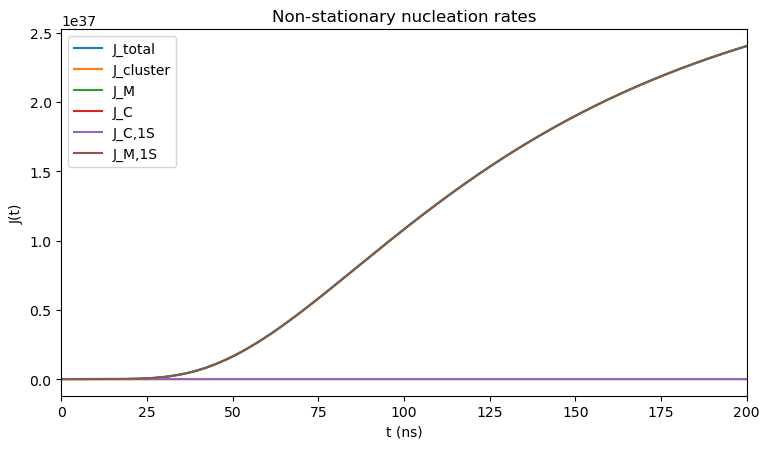

In [1]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# - Memory-safe: triangular indexing + jac_sparsity
# - Time-step: BDF (adaptive) + max_step control
# - Progress prints: stage marks + every 10 output steps
# - Updated for (T=160 K, s_co=6.5593, s_cm=5.7434, gammas, C1_base)
# - Time window tightened (ns–sub-μs) + log sampling + unit switch
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) PARAMETERS (updated)
# ------------------------
T = 160.0
SCO_LIST = [6.559265115469421]                 # single s_co
s_cm = 5.743373201230127
gamma_co, gamma_cm, gamma_mo = 27.943965123920165, 25.118212926685757, 2.8257521972344097
C1_base = 8.17e28

# kinetics (kept for physical consistency)
f0 = 1.0e5
g0 = 2.0e7
Q  = 0.5

# grid
M = 240

# runtime window & sampling (tight window; log sampling for early ps–ns)
t_max  = 2.0e-7                                  # 0.2 microseconds
N_eval = 1800
t_eval = np.r_[0.0, np.geomspace(1e-11, t_max, N_eval-1)]
x_eval = f0 * t_eval                             # solver works in x = f0 t

# integrator step ceilings
max_step = 2.5e-10                               # 0.25 ns
max_dx   = f0 * max_step

# plotting time unit: choose "ns" or "us"
TIME_UNIT = "ns"                                 # "ns" or "us"
_unit_map = {"ns": 1e9, "us": 1e6}
t_unit  = _unit_map[TIME_UNIT]
t_label = f"t ({TIME_UNIT})"

# ------------------------
# 1) UTILS: triangular indexing (1 <= n <= i <= M-1)
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i,n)] = k
            idx2pair.append((i,n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo): return -s_mo * i + gamma_mo * i**(2/3)
def w_cm(n):        return -s_cm * n + gamma_cm * n**(2/3)
def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k,(i,n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1,1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2*gamma_mo / (3*s_mo))**3
    n_star   = (2*gamma_cm / (3*s_cm))**3
    ico_star = (2*gamma_co / (3*s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 3) Attachment frequencies (as specified)
# ------------------------
def f_in_val(i, s_co): return (1.0 - Q) * f0 * np.exp(s_co) * (i**(2/3))
def g_in_val(n):       return g0 * np.exp(s_cm) * (n**(2/3))
def k_ii_val(i, s_co): return Q * f0 * np.exp(s_co) * (i**(2/3))

def build_coeffs(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)
    Wmap = {(i,n): W[PAIR2IDX[(i,n)]] for (i,n) in PAIR2IDX}

    for k,(i,n) in enumerate(IDX2PAIR):
        if n < i:
            b[k] = f_in_val(i, s_co) / f0
            d[k] = g_in_val(n)       / f0
            if i >= 2:  # need (i-1,n)
                a[k] = (f_in_val(i-1, s_co)/f0) * np.exp(Wmap[(i,n)] - Wmap[(i-1,n)])
            if n >= 2:  # need (i,n-1)
                c[k] = (g_in_val(n-1)/f0)       * np.exp(Wmap[(i,n)] - Wmap[(i,n-1)])
        else:  # n == i
            if i >= 2:
                e[k] = (k_ii_val(i-1, s_co)/f0) * np.exp(Wmap[(i,i)] - Wmap[(i-1,i-1)])
            h[k] =  (k_ii_val(i,   s_co)/f0)
    return a,b,c,d,e,h

# ------------------------
# 4) Sparse Jacobian pattern (neighbor stencil)
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []
    def add(r,c):
        rows.append(r); cols.append(c)

    for k,(i,n) in enumerate(IDX2PAIR):
        # self
        add(k,k)
        # (i-1, n) exists only if i-1 >= 1 and n <= i-1
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        # (i+1, n) exists only if i+1 <= M-1 and n <= i+1
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        # (i, n-1)
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        # (i, n+1) only if n+1 <= i
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        # diagonal neighbors when n == i
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)), shape=(Ntri, Ntri))
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x-domain (Eq.(6)): dF/dx = ...
# ------------------------
def dFdx(x, F_flat, a,b,c,d,e,h):
    F = F_flat
    dF = np.zeros_like(F)

    # enforce boundary F(1,1)=1
    F[PAIR2IDX[(1,1)]] = 1.0

    for k,(i,n) in enumerate(IDX2PAIR):
        val = 0.0
        # a(F_{i-1,n}-F_{i,n})
        if n < i and i >= 2:
            val += a[k]*(F[PAIR2IDX[(i-1,n)]] - F[k])
        # - b(F_{i,n}-F_{i+1,n})
        if n < i:
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            val -= b[k]*(F[k] - Fip)
        # c(F_{i,n-1}-F_{i,n})
        if n >= 2:
            val += c[k]*(F[PAIR2IDX[(i, n-1)]] - F[k])
        # - d(F_{i,n}-F_{i,n+1})
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k]*(F[k] - Finp)
        # + e(F_{i-1,i-1}-F_{i,i}) - h(F_{i,i}-F_{i+1,i+1})
        if n == i:
            if i >= 2:
                val += e[k]*(F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k]*(F[k] - Fipp)
        dF[k] = val
    return dF

# ------------------------
# 6) Fluxes I,G,K (for J(t))
# ------------------------
def fluxes_IGK(F_flat, C, s_co):
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat

    for (i,n),k in PAIR2IDX.items():
        Ckn = C[k]
        # I_{i,n} (n<i)
        if n < i:
            fval = f_in_val(i, s_co)
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            I_map[(i,n)] = fval * Ckn * (F[k] - Fip)
        # G_{i,n} (n<i)
        if n < i:
            gval = g_in_val(n)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i,n)] = gval * Ckn * (F[k] - Finp)
        # K_{i,i}
        if n == i:
            kval = k_ii_val(i, s_co)
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i,i)] = kval * Ckn * (F[k] - Fipp)
    return I_map, G_map, K_map

# ------------------------
# 7) Non-stationary rates
# ------------------------
def compute_Js(F_flat, C, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, s_co)

    gi = lambda i,n: G_map.get((i,n), 0.0)
    ii = lambda i,n: I_map.get((i,n), 0.0)
    kk = lambda i:    K_map.get((i,i), 0.0)

    # J_{d+com}
    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i,i) - gi(i, i-1)

    # J_d
    J_d = ii(i_star,1) - sum(gi(i,1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    # J_c
    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i,i)

    # 1S limits
    J_c_1S = kk(ico_star)      # Q=1 channel
    J_d_1S = ii(i_star, 1)     # Q=0 channel

    return {"J_d+com":J_dcom, "J_com":J_com, "J_d":J_d, "J_c":J_c, "J_c,1S":J_c_1S, "J_d,1S":J_d_1S}

# ------------------------
# 8) MAIN SESSION
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co}: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…")
    W, C = make_wC(s_co)
    a,b,c,d,e,h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co}: 전체 map 훑어보기 완료")  # ①

    # Initial condition: F(1,1)=1, others 0
    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1,1)]] = 1.0

    # BDF integrate in x with jac_sparsity & max_step
    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a,b,c,d,e,h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method='BDF',
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6, atol=1e-9,
        max_step=max_dx
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    # compute nonstationary rates and print progress every 10 steps
    curves = {k: np.zeros_like(sol.t) for k in ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]}
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, s_co)
        for k in curves.keys():
            curves[k][j] = Js[k]
        if j % 10 == 0:
            print(f"[Progress] s_co={s_co}: 출력 step {j}/{len(sol.t)-1} (t={x/f0*t_unit:.3f} {TIME_UNIT}) 완료")  # ②

    print(f"[Done]  s_co={s_co}: 전체 계산 완료")  # ③

    # plot
    label_map = {
        "J_d+com": "J_total",
        "J_com":   "J_cluster",
        "J_d":     "J_M",
        "J_c":     "J_C",
        "J_c,1S":  "J_C,1S",
        "J_d,1S":  "J_M,1S"
    }

    plt.figure(figsize=(7.8,4.6))
    order = ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]
    for name in order:
        plt.plot(sol.t/f0 * t_unit, curves[name], label=label_map[name])
    plt.xlabel(t_label)
    plt.ylabel("J(t)")
    plt.title("Non-stationary nucleation rates")
    plt.xlim(0.0, t_max * t_unit)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------
# 9) RUN
# ------------------------
for sco in SCO_LIST:
    run_session(sco)


[Stage] s_co=6.559265115469421 map 준비 시작
[Done]  s_co=6.559265115469421 준비 완료
[Progress] s_co=6.559265115469421 step 0/2000  t=0.000 ps
[Progress] s_co=6.559265115469421 step 100/2000  t=3.000 ps
[Progress] s_co=6.559265115469421 step 200/2000  t=6.000 ps
[Progress] s_co=6.559265115469421 step 300/2000  t=9.000 ps
[Progress] s_co=6.559265115469421 step 400/2000  t=12.000 ps
[Progress] s_co=6.559265115469421 step 500/2000  t=15.000 ps
[Progress] s_co=6.559265115469421 step 600/2000  t=18.000 ps
[Progress] s_co=6.559265115469421 step 700/2000  t=21.000 ps
[Progress] s_co=6.559265115469421 step 800/2000  t=24.000 ps
[Progress] s_co=6.559265115469421 step 900/2000  t=27.000 ps
[Progress] s_co=6.559265115469421 step 1000/2000  t=30.000 ps
[Progress] s_co=6.559265115469421 step 1100/2000  t=33.000 ps
[Progress] s_co=6.559265115469421 step 1200/2000  t=36.000 ps
[Progress] s_co=6.559265115469421 step 1300/2000  t=39.000 ps
[Progress] s_co=6.559265115469421 step 1400/2000  t=42.000 ps
[Progres

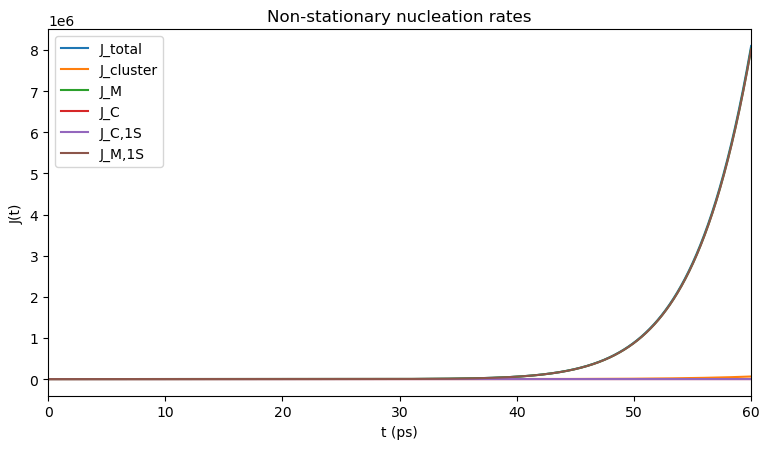

In [1]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# Units
# - Input time knobs in ps: t_max, max_step, dt_ps
# - Internal integration uses x = f0 * t (t in seconds)
# - Display/log uses ps
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 160.0
SCO_LIST = [6.559265115469421]                 # single s_co
s_cm = 5.743373201230127
gamma_co, gamma_cm, gamma_mo = 27.943965123920165, 25.118212926685757, 2.8257521972344097
C1_base = 8.17e28

# kinetics
f0 = 1.0e5
g0 = 2.0e7
Q  = 0.5

# grid
M = 240

# ------------------------
# runtime window and sampling  ps → s 변환은 ps2s 사용
# ------------------------
t_max  = 60.0                 # [ps] total time window
STEPS  = 2000                 # number of steps
dt_ps  = t_max / STEPS        # [ps] = 0.03 ps
ps2s   = 1e-12                # ps → s

# 등간격 샘플링 0 .. 60 ps  2001 포인트  초 단위로 변환 후 사용
t_eval = np.linspace(0.0, t_max, STEPS + 1) * ps2s  # [s]
x_eval = f0 * t_eval                                 # x = f0 * t

# ------------------------
# integrator step ceiling
# ------------------------
max_step = dt_ps                                     # [ps] 0.03 ps
max_dx   = f0 * (max_step * ps2s)

# ------------------------
# plotting unit
# ------------------------
TIME_UNIT = "ps"
_unit_map = {"ps": 1e12, "ns": 1e9, "us": 1e6}
t_unit  = _unit_map[TIME_UNIT]
t_label = f"t ({TIME_UNIT})"

# ------------------------
# 1) triangular indexing  1 <= n <= i <= M-1
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i,n)] = k
            idx2pair.append((i,n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo): return -s_mo * i + gamma_mo * i**(2/3)
def w_cm(n):        return -s_cm * n + gamma_cm * n**(2/3)
def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k,(i,n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1,1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2*gamma_mo / (3*s_mo))**3
    n_star   = (2*gamma_cm / (3*s_cm))**3
    ico_star = (2*gamma_co / (3*s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 3) Attachment frequencies
# ------------------------
def f_in_val(i, s_co): return (1.0 - Q) * f0 * np.exp(s_co) * (i**(2/3))
def g_in_val(n):       return g0 * np.exp(s_cm) * (n**(2/3))
def k_ii_val(i, s_co): return Q * f0 * np.exp(s_co) * (i**(2/3))

def build_coeffs(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)
    Wmap = {(i,n): W[PAIR2IDX[(i,n)]] for (i,n) in PAIR2IDX}

    for k,(i,n) in enumerate(IDX2PAIR):
        if n < i:
            b[k] = f_in_val(i, s_co) / f0
            d[k] = g_in_val(n)       / f0
            if i >= 2:
                a[k] = (f_in_val(i-1, s_co)/f0) * np.exp(Wmap[(i,n)] - Wmap[(i-1,n)])
            if n >= 2:
                c[k] = (g_in_val(n-1)/f0)       * np.exp(Wmap[(i,n)] - Wmap[(i,n-1)])
        else:  # n == i
            if i >= 2:
                e[k] = (k_ii_val(i-1, s_co)/f0) * np.exp(Wmap[(i,i)] - Wmap[(i-1,i-1)])
            h[k] =  (k_ii_val(i,   s_co)/f0)
    return a,b,c,d,e,h

# ------------------------
# 4) Sparse Jacobian pattern
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []
    def add(r,c):
        rows.append(r); cols.append(c)

    for k,(i,n) in enumerate(IDX2PAIR):
        add(k,k)
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)), shape=(Ntri, Ntri))
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x domain: dF/dx
# ------------------------
def dFdx(x, F_flat, a,b,c,d,e,h):
    F = F_flat
    dF = np.zeros_like(F)

    # boundary F(1,1)=1
    F[PAIR2IDX[(1,1)]] = 1.0

    for k,(i,n) in enumerate(IDX2PAIR):
        val = 0.0
        if n < i and i >= 2:
            val += a[k]*(F[PAIR2IDX[(i-1,n)]] - F[k])
        if n < i:
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            val -= b[k]*(F[k] - Fip)
        if n >= 2:
            val += c[k]*(F[PAIR2IDX[(i, n-1)]] - F[k])
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k]*(F[k] - Finp)
        if n == i:
            if i >= 2:
                val += e[k]*(F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k]*(F[k] - Fipp)
        dF[k] = val
    return dF

# ------------------------
# 6) Fluxes I, G, K
# ------------------------
def fluxes_IGK(F_flat, C, s_co):
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat

    for (i,n),k in PAIR2IDX.items():
        Ckn = C[k]
        if n < i:
            fval = f_in_val(i, s_co)
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            I_map[(i,n)] = fval * Ckn * (F[k] - Fip)
        if n < i:
            gval = g_in_val(n)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i,n)] = gval * Ckn * (F[k] - Finp)
        if n == i:
            kval = k_ii_val(i, s_co)
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i,i)] = kval * Ckn * (F[k] - Fipp)
    return I_map, G_map, K_map

# ------------------------
# 7) Non-stationary rates
# ------------------------
def compute_Js(F_flat, C, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, s_co)

    gi = lambda i,n: G_map.get((i,n), 0.0)
    ii = lambda i,n: I_map.get((i,n), 0.0)
    kk = lambda i:    K_map.get((i,i), 0.0)

    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i,i) - gi(i, i-1)

    J_d = ii(i_star,1) - sum(gi(i,1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i,i)

    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)

    return {"J_d+com":J_dcom, "J_com":J_com, "J_d":J_d, "J_c":J_c, "J_c,1S":J_c_1S, "J_d,1S":J_d_1S}

# ------------------------
# 8) MAIN
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co} map 준비 시작")
    W, C = make_wC(s_co)
    a,b,c,d,e,h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co} 준비 완료")

    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1,1)]] = 1.0

    # integrate in x domain
    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a,b,c,d,e,h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method='BDF',
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6, atol=1e-9,
        max_step=max_dx
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    curves = {k: np.zeros_like(sol.t) for k in ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]}
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, s_co)
        for k in curves.keys():
            curves[k][j] = Js[k]
        if j % 100 == 0:
            # sol.t 는 x 이므로 t = x/f0  표시 단위는 ps
            t_disp = (x / f0) * t_unit
            print(f"[Progress] s_co={s_co} step {j}/{len(sol.t)-1}  t={t_disp:.3f} {TIME_UNIT}")

    print(f"[Done]  s_co={s_co} 계산 완료")

    label_map = {
        "J_d+com": "J_total",
        "J_com":   "J_cluster",
        "J_d":     "J_M",
        "J_c":     "J_C",
        "J_c,1S":  "J_C,1S",
        "J_d,1S":  "J_M,1S"
    }

    plt.figure(figsize=(7.8,4.6))
    order = ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]
    # x축은 (sol.t/f0) [s] 를 ps 로 변환하여 플롯
    t_disp_all = (sol.t / f0) * t_unit
    for name in order:
        plt.plot(t_disp_all, curves[name], label=label_map[name])
    plt.xlabel(t_label)
    plt.ylabel("J(t)")
    plt.title("Non-stationary nucleation rates")
    plt.xlim(0.0, t_max)  # 이미 ps 단위로 변환된 축
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------
# 9) RUN
# ------------------------
for sco in SCO_LIST:
    run_session(sco)


[Stage] s_co=6.559265115469421 map 준비 시작
[Done]  s_co=6.559265115469421 준비 완료
[Progress] s_co=6.559265115469421 step 0/6000  t=0.000 ps
[Progress] s_co=6.559265115469421 step 100/6000  t=0.500 ps
[Progress] s_co=6.559265115469421 step 200/6000  t=1.000 ps
[Progress] s_co=6.559265115469421 step 300/6000  t=1.500 ps
[Progress] s_co=6.559265115469421 step 400/6000  t=2.000 ps
[Progress] s_co=6.559265115469421 step 500/6000  t=2.500 ps
[Progress] s_co=6.559265115469421 step 600/6000  t=3.000 ps
[Progress] s_co=6.559265115469421 step 700/6000  t=3.500 ps
[Progress] s_co=6.559265115469421 step 800/6000  t=4.000 ps
[Progress] s_co=6.559265115469421 step 900/6000  t=4.500 ps
[Progress] s_co=6.559265115469421 step 1000/6000  t=5.000 ps
[Progress] s_co=6.559265115469421 step 1100/6000  t=5.500 ps
[Progress] s_co=6.559265115469421 step 1200/6000  t=6.000 ps
[Progress] s_co=6.559265115469421 step 1300/6000  t=6.500 ps
[Progress] s_co=6.559265115469421 step 1400/6000  t=7.000 ps
[Progress] s_co=6.5

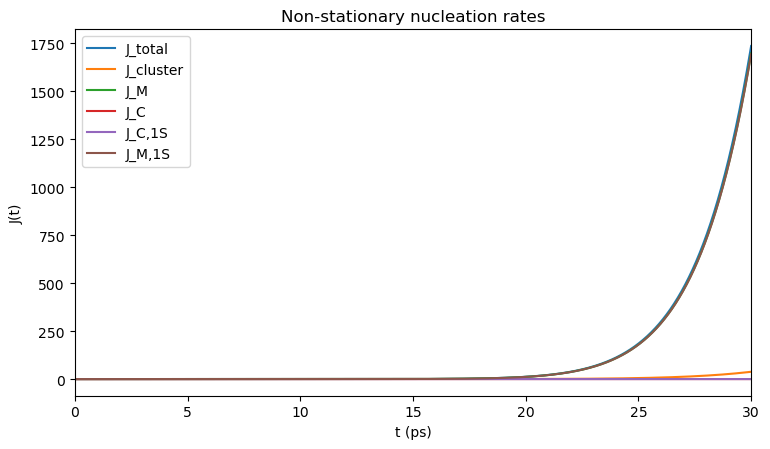

In [3]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# Units
# - Input time knobs in ps: t_max, max_step, dt_ps
# - Internal integration uses x = f0 * t (t in seconds)
# - Display/log uses ps
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 160.0
SCO_LIST = [6.559265115469421]                 # single s_co
s_cm = 5.743373201230127
gamma_co, gamma_cm, gamma_mo = 27.943965123920165, 25.118212926685757, 2.8257521972344097
C1_base = 8.17e28

# kinetics
f0 = 1.0e5
g0 = 2.0e7
Q  = 0.5

# grid
M = 240

# ------------------------
# runtime window and sampling  (ps 입력 → s 변환은 ps2s 사용)
# ------------------------
t_max  = 30.0                 # [ps] total time window (was 60.0)
STEPS  = 6000                 # number of steps (was 2000)
dt_ps  = t_max / STEPS        # [ps] = 10/3000 ≈ 0.003333... ps ≈ 3.33 fs
ps2s   = 1e-12                # ps → s

# 등간격 샘플링 0 .. t_max ps  (STEPS+1 포인트)  초 단위로 변환 후 사용
t_eval = np.linspace(0.0, t_max, STEPS + 1) * ps2s  # [s]
x_eval = f0 * t_eval                                 # x = f0 * t

# ------------------------
# integrator step ceiling
# ------------------------
max_step = dt_ps                                     # [ps] ≈ 0.003333 ps
max_dx   = f0 * (max_step * ps2s)                    # x-domain step upper bound

# ------------------------
# plotting unit
# ------------------------
TIME_UNIT = "ps"
_unit_map = {"ps": 1e12, "ns": 1e9, "us": 1e6}
t_unit  = _unit_map[TIME_UNIT]
t_label = f"t ({TIME_UNIT})"

# ------------------------
# 1) triangular indexing  1 <= n <= i <= M-1
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i,n)] = k
            idx2pair.append((i,n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo): return -s_mo * i + gamma_mo * i**(2/3)
def w_cm(n):        return -s_cm * n + gamma_cm * n**(2/3)
def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k,(i,n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1,1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2*gamma_mo / (3*s_mo))**3
    n_star   = (2*gamma_cm / (3*s_cm))**3
    ico_star = (2*gamma_co / (3*s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 3) Attachment frequencies
# ------------------------
def f_in_val(i, s_co): return (1.0 - Q) * f0 * np.exp(s_co) * (i**(2/3))
def g_in_val(n):       return g0 * np.exp(s_cm) * (n**(2/3))
def k_ii_val(i, s_co): return Q * f0 * np.exp(s_co) * (i**(2/3))

def build_coeffs(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)
    Wmap = {(i,n): W[PAIR2IDX[(i,n)]] for (i,n) in PAIR2IDX}

    for k,(i,n) in enumerate(IDX2PAIR):
        if n < i:
            b[k] = f_in_val(i, s_co) / f0
            d[k] = g_in_val(n)       / f0
            if i >= 2:
                a[k] = (f_in_val(i-1, s_co)/f0) * np.exp(Wmap[(i,n)] - Wmap[(i-1,n)])
            if n >= 2:
                c[k] = (g_in_val(n-1)/f0)       * np.exp(Wmap[(i,n)] - Wmap[(i,n-1)])
        else:  # n == i
            if i >= 2:
                e[k] = (k_ii_val(i-1, s_co)/f0) * np.exp(Wmap[(i,i)] - Wmap[(i-1,i-1)])
            h[k] =  (k_ii_val(i,   s_co)/f0)
    return a,b,c,d,e,h

# ------------------------
# 4) Sparse Jacobian pattern
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []
    def add(r,c):
        rows.append(r); cols.append(c)

    for k,(i,n) in enumerate(IDX2PAIR):
        add(k,k)
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)), shape=(Ntri, Ntri))
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x domain: dF/dx
# ------------------------
def dFdx(x, F_flat, a,b,c,d,e,h):
    F = F_flat
    dF = np.zeros_like(F)

    # boundary F(1,1)=1
    F[PAIR2IDX[(1,1)]] = 1.0

    for k,(i,n) in enumerate(IDX2PAIR):
        val = 0.0
        if n < i and i >= 2:
            val += a[k]*(F[PAIR2IDX[(i-1,n)]] - F[k])
        if n < i:
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            val -= b[k]*(F[k] - Fip)
        if n >= 2:
            val += c[k]*(F[PAIR2IDX[(i, n-1)]] - F[k])
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k]*(F[k] - Finp)
        if n == i:
            if i >= 2:
                val += e[k]*(F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k]*(F[k] - Fipp)
        dF[k] = val
    return dF

# ------------------------
# 6) Fluxes I, G, K
# ------------------------
def fluxes_IGK(F_flat, C, s_co):
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat

    for (i,n),k in PAIR2IDX.items():
        Ckn = C[k]
        if n < i:
            fval = f_in_val(i, s_co)
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            I_map[(i,n)] = fval * Ckn * (F[k] - Fip)
        if n < i:
            gval = g_in_val(n)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i,n)] = gval * Ckn * (F[k] - Finp)
        if n == i:
            kval = k_ii_val(i, s_co)
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i,i)] = kval * Ckn * (F[k] - Fipp)
    return I_map, G_map, K_map

# ------------------------
# 7) Non-stationary rates
# ------------------------
def compute_Js(F_flat, C, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, s_co)

    gi = lambda i,n: G_map.get((i,n), 0.0)
    ii = lambda i,n: I_map.get((i,n), 0.0)
    kk = lambda i:    K_map.get((i,i), 0.0)

    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i,i) - gi(i, i-1)

    J_d = ii(i_star,1) - sum(gi(i,1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i,i)

    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)

    return {"J_d+com":J_dcom, "J_com":J_com, "J_d":J_d, "J_c":J_c, "J_c,1S":J_c_1S, "J_d,1S":J_d_1S}

# ------------------------
# 8) MAIN
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co} map 준비 시작")
    W, C = make_wC(s_co)
    a,b,c,d,e,h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co} 준비 완료")

    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1,1)]] = 1.0

    # integrate in x domain
    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a,b,c,d,e,h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method='BDF',
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6, atol=1e-9,
        max_step=max_dx
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    curves = {k: np.zeros_like(sol.t) for k in ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]}
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, s_co)
        for k in curves.keys():
            curves[k][j] = Js[k]
        if j % 100 == 0:
            # sol.t 는 x 이므로 t = x/f0  표시 단위는 ps
            t_disp = (x / f0) * t_unit
            print(f"[Progress] s_co={s_co} step {j}/{len(sol.t)-1}  t={t_disp:.3f} {TIME_UNIT}")

    print(f"[Done]  s_co={s_co} 계산 완료")

    label_map = {
        "J_d+com": "J_total",
        "J_com":   "J_cluster",
        "J_d":     "J_M",
        "J_c":     "J_C",
        "J_c,1S":  "J_C,1S",
        "J_d,1S":  "J_M,1S"
    }

    plt.figure(figsize=(7.8,4.6))
    order = ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]
    # x축은 (sol.t/f0) [s] 를 ps 로 변환하여 플롯
    t_disp_all = (sol.t / f0) * t_unit
    for name in order:
        plt.plot(t_disp_all, curves[name], label=label_map[name])
    plt.xlabel(t_label)
    plt.ylabel("J(t)")
    plt.title("Non-stationary nucleation rates")
    plt.xlim(0.0, t_max)  # ps 단위
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------
# 9) RUN
# ------------------------
for sco in SCO_LIST:
    run_session(sco)


[Stage] s_co=6.559265115469421 map 준비 시작
[Done]  s_co=6.559265115469421 준비 완료
[Progress] s_co=6.559265115469421 step 0/9000  t=0.000 ps
[Progress] s_co=6.559265115469421 step 100/9000  t=0.222 ps
[Progress] s_co=6.559265115469421 step 200/9000  t=0.444 ps
[Progress] s_co=6.559265115469421 step 300/9000  t=0.667 ps
[Progress] s_co=6.559265115469421 step 400/9000  t=0.889 ps
[Progress] s_co=6.559265115469421 step 500/9000  t=1.111 ps
[Progress] s_co=6.559265115469421 step 600/9000  t=1.333 ps
[Progress] s_co=6.559265115469421 step 700/9000  t=1.556 ps
[Progress] s_co=6.559265115469421 step 800/9000  t=1.778 ps
[Progress] s_co=6.559265115469421 step 900/9000  t=2.000 ps
[Progress] s_co=6.559265115469421 step 1000/9000  t=2.222 ps
[Progress] s_co=6.559265115469421 step 1100/9000  t=2.444 ps
[Progress] s_co=6.559265115469421 step 1200/9000  t=2.667 ps
[Progress] s_co=6.559265115469421 step 1300/9000  t=2.889 ps
[Progress] s_co=6.559265115469421 step 1400/9000  t=3.111 ps
[Progress] s_co=6.5

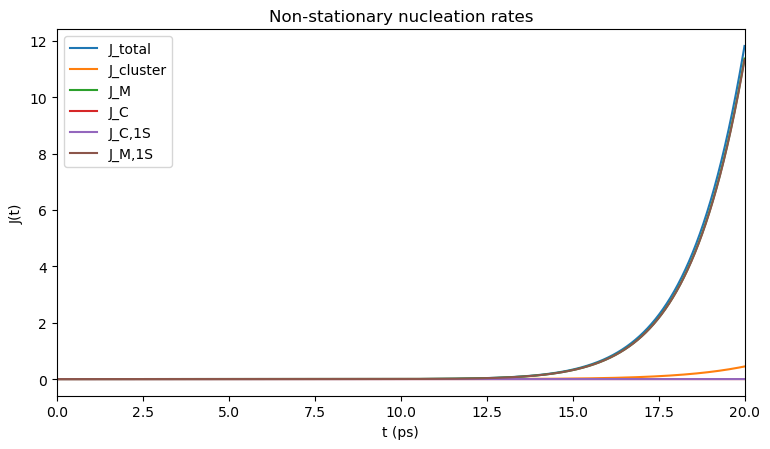

In [4]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# Units
# - Input time knobs in ps: t_max, max_step, dt_ps
# - Internal integration uses x = f0 * t (t in seconds)
# - Display/log uses ps
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 160.0
SCO_LIST = [6.559265115469421]                 # single s_co
s_cm = 5.743373201230127
gamma_co, gamma_cm, gamma_mo = 27.943965123920165, 25.118212926685757, 2.8257521972344097
C1_base = 8.17e28

# kinetics
f0 = 1.0e5
g0 = 2.0e7
Q  = 0.5

# grid
M = 240

# ------------------------
# runtime window and sampling  (ps 입력 → s 변환은 ps2s 사용)
# ------------------------
t_max  = 20.0                 # [ps] total time window (was 60.0)
STEPS  = 9000                 # number of steps (was 2000)
dt_ps  = t_max / STEPS        # [ps] = 10/3000 ≈ 0.003333... ps ≈ 3.33 fs
ps2s   = 1e-12                # ps → s

# 등간격 샘플링 0 .. t_max ps  (STEPS+1 포인트)  초 단위로 변환 후 사용
t_eval = np.linspace(0.0, t_max, STEPS + 1) * ps2s  # [s]
x_eval = f0 * t_eval                                 # x = f0 * t

# ------------------------
# integrator step ceiling
# ------------------------
max_step = dt_ps                                     # [ps] ≈ 0.003333 ps
max_dx   = f0 * (max_step * ps2s)                    # x-domain step upper bound

# ------------------------
# plotting unit
# ------------------------
TIME_UNIT = "ps"
_unit_map = {"ps": 1e12, "ns": 1e9, "us": 1e6}
t_unit  = _unit_map[TIME_UNIT]
t_label = f"t ({TIME_UNIT})"

# ------------------------
# 1) triangular indexing  1 <= n <= i <= M-1
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i,n)] = k
            idx2pair.append((i,n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo): return -s_mo * i + gamma_mo * i**(2/3)
def w_cm(n):        return -s_cm * n + gamma_cm * n**(2/3)
def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k,(i,n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1,1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2*gamma_mo / (3*s_mo))**3
    n_star   = (2*gamma_cm / (3*s_cm))**3
    ico_star = (2*gamma_co / (3*s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 3) Attachment frequencies
# ------------------------
def f_in_val(i, s_co): return (1.0 - Q) * f0 * np.exp(s_co) * (i**(2/3))
def g_in_val(n):       return g0 * np.exp(s_cm) * (n**(2/3))
def k_ii_val(i, s_co): return Q * f0 * np.exp(s_co) * (i**(2/3))

def build_coeffs(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)
    Wmap = {(i,n): W[PAIR2IDX[(i,n)]] for (i,n) in PAIR2IDX}

    for k,(i,n) in enumerate(IDX2PAIR):
        if n < i:
            b[k] = f_in_val(i, s_co) / f0
            d[k] = g_in_val(n)       / f0
            if i >= 2:
                a[k] = (f_in_val(i-1, s_co)/f0) * np.exp(Wmap[(i,n)] - Wmap[(i-1,n)])
            if n >= 2:
                c[k] = (g_in_val(n-1)/f0)       * np.exp(Wmap[(i,n)] - Wmap[(i,n-1)])
        else:  # n == i
            if i >= 2:
                e[k] = (k_ii_val(i-1, s_co)/f0) * np.exp(Wmap[(i,i)] - Wmap[(i-1,i-1)])
            h[k] =  (k_ii_val(i,   s_co)/f0)
    return a,b,c,d,e,h

# ------------------------
# 4) Sparse Jacobian pattern
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []
    def add(r,c):
        rows.append(r); cols.append(c)

    for k,(i,n) in enumerate(IDX2PAIR):
        add(k,k)
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)), shape=(Ntri, Ntri))
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x domain: dF/dx
# ------------------------
def dFdx(x, F_flat, a,b,c,d,e,h):
    F = F_flat
    dF = np.zeros_like(F)

    # boundary F(1,1)=1
    F[PAIR2IDX[(1,1)]] = 1.0

    for k,(i,n) in enumerate(IDX2PAIR):
        val = 0.0
        if n < i and i >= 2:
            val += a[k]*(F[PAIR2IDX[(i-1,n)]] - F[k])
        if n < i:
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            val -= b[k]*(F[k] - Fip)
        if n >= 2:
            val += c[k]*(F[PAIR2IDX[(i, n-1)]] - F[k])
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k]*(F[k] - Finp)
        if n == i:
            if i >= 2:
                val += e[k]*(F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k]*(F[k] - Fipp)
        dF[k] = val
    return dF

# ------------------------
# 6) Fluxes I, G, K
# ------------------------
def fluxes_IGK(F_flat, C, s_co):
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat

    for (i,n),k in PAIR2IDX.items():
        Ckn = C[k]
        if n < i:
            fval = f_in_val(i, s_co)
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            I_map[(i,n)] = fval * Ckn * (F[k] - Fip)
        if n < i:
            gval = g_in_val(n)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i,n)] = gval * Ckn * (F[k] - Finp)
        if n == i:
            kval = k_ii_val(i, s_co)
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i,i)] = kval * Ckn * (F[k] - Fipp)
    return I_map, G_map, K_map

# ------------------------
# 7) Non-stationary rates
# ------------------------
def compute_Js(F_flat, C, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, s_co)

    gi = lambda i,n: G_map.get((i,n), 0.0)
    ii = lambda i,n: I_map.get((i,n), 0.0)
    kk = lambda i:    K_map.get((i,i), 0.0)

    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i,i) - gi(i, i-1)

    J_d = ii(i_star,1) - sum(gi(i,1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i,i)

    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)

    return {"J_d+com":J_dcom, "J_com":J_com, "J_d":J_d, "J_c":J_c, "J_c,1S":J_c_1S, "J_d,1S":J_d_1S}

# ------------------------
# 8) MAIN
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co} map 준비 시작")
    W, C = make_wC(s_co)
    a,b,c,d,e,h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co} 준비 완료")

    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1,1)]] = 1.0

    # integrate in x domain
    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a,b,c,d,e,h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method='BDF',
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6, atol=1e-9,
        max_step=max_dx
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    curves = {k: np.zeros_like(sol.t) for k in ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]}
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, s_co)
        for k in curves.keys():
            curves[k][j] = Js[k]
        if j % 100 == 0:
            # sol.t 는 x 이므로 t = x/f0  표시 단위는 ps
            t_disp = (x / f0) * t_unit
            print(f"[Progress] s_co={s_co} step {j}/{len(sol.t)-1}  t={t_disp:.3f} {TIME_UNIT}")

    print(f"[Done]  s_co={s_co} 계산 완료")

    label_map = {
        "J_d+com": "J_total",
        "J_com":   "J_cluster",
        "J_d":     "J_M",
        "J_c":     "J_C",
        "J_c,1S":  "J_C,1S",
        "J_d,1S":  "J_M,1S"
    }

    plt.figure(figsize=(7.8,4.6))
    order = ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]
    # x축은 (sol.t/f0) [s] 를 ps 로 변환하여 플롯
    t_disp_all = (sol.t / f0) * t_unit
    for name in order:
        plt.plot(t_disp_all, curves[name], label=label_map[name])
    plt.xlabel(t_label)
    plt.ylabel("J(t)")
    plt.title("Non-stationary nucleation rates")
    plt.xlim(0.0, t_max)  # ps 단위
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------
# 9) RUN
# ------------------------
for sco in SCO_LIST:
    run_session(sco)

[TIME] X_MAX=0.500 → t_max=14081.0 ps, dt≈2.500 ps, steps=5633, max_dx=8.876e-05
[Stage] s_co=6.559265115469421 map 준비 시작
[Done]  s_co=6.559265115469421 준비 완료
[Progress] s_co=6.559265115469421 step 0/5633  t=0.000 ps
[Progress] s_co=6.559265115469421 step 100/5633  t=249.973 ps
[Progress] s_co=6.559265115469421 step 200/5633  t=499.946 ps
[Progress] s_co=6.559265115469421 step 300/5633  t=749.919 ps
[Progress] s_co=6.559265115469421 step 400/5633  t=999.892 ps
[Progress] s_co=6.559265115469421 step 500/5633  t=1249.865 ps
[Progress] s_co=6.559265115469421 step 600/5633  t=1499.838 ps
[Progress] s_co=6.559265115469421 step 700/5633  t=1749.811 ps
[Progress] s_co=6.559265115469421 step 800/5633  t=1999.784 ps
[Progress] s_co=6.559265115469421 step 900/5633  t=2249.757 ps
[Progress] s_co=6.559265115469421 step 1000/5633  t=2499.730 ps
[Progress] s_co=6.559265115469421 step 1100/5633  t=2749.703 ps
[Progress] s_co=6.559265115469421 step 1200/5633  t=2999.676 ps
[Progress] s_co=6.5592651154

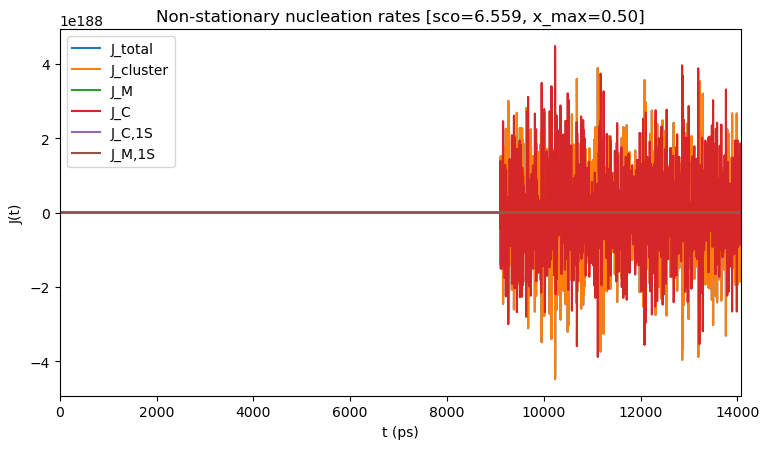

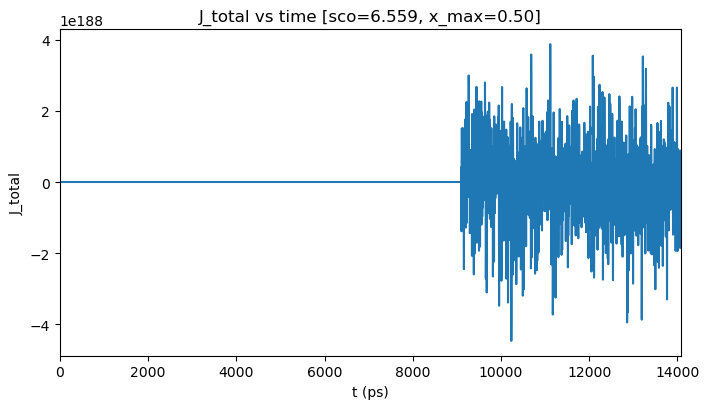

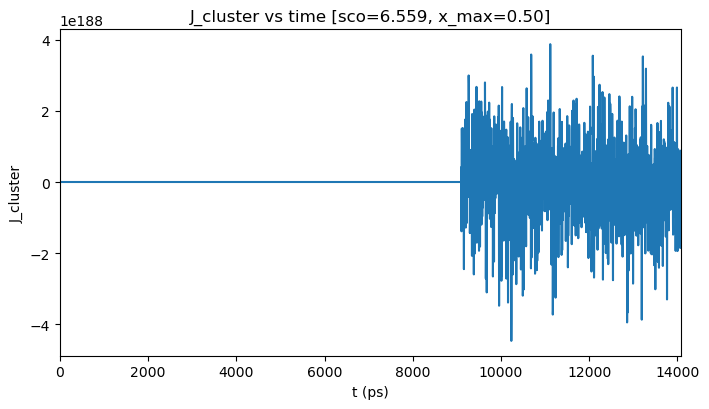

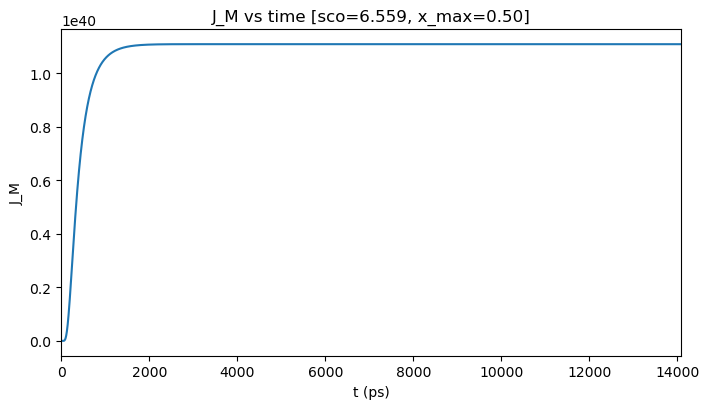

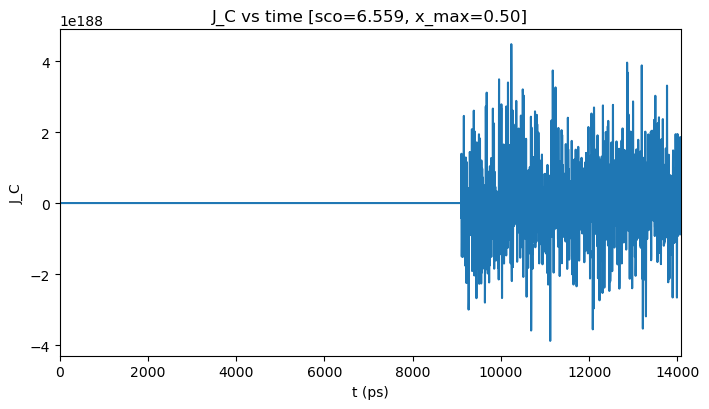

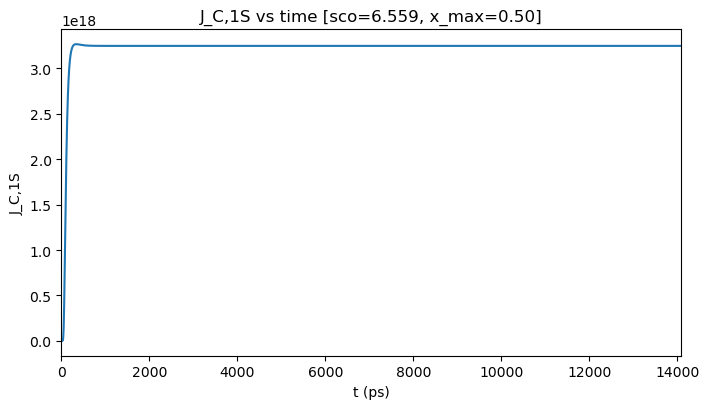

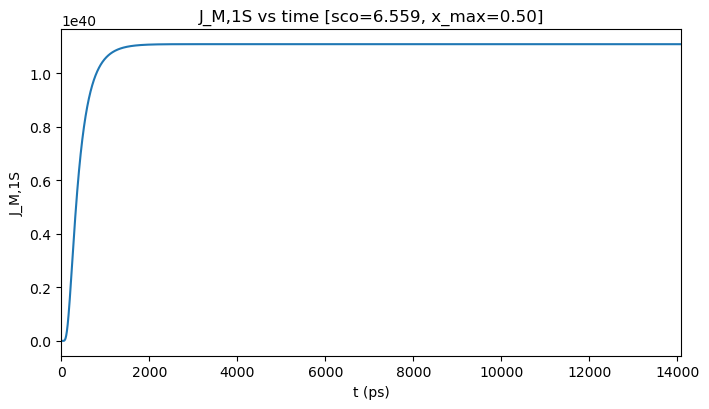

In [2]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# Induction + pre-steady window: set X_MAX (in x = f0 * t units)
# - ps2s fixed to ps→s
# - t_max is derived from X_MAX and f0
# - plotting xlim matches selected TIME_UNIT exactly
# - (추가) 전체 J 한 장 + 각 J 개별 그림 출력
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 160.0
SCO_LIST = [6.559265115469421]                 # single s_co
s_cm = 5.743373201230127
gamma_co, gamma_cm, gamma_mo = 27.943965123920165, 25.118212926685757, 2.8257521972344097
C1_base = 8.17e28

# kinetics
# (필요 시 업데이트) f0, g0 는 이전 계산 결과/선택값 사용
f0 = 3.550889e7       # [s^-1]
g0 = 7.101778e9       # [s^-1]
Q  = 0.5

# grid
M = 240

# ------------------------
# 0.5) RUNTIME WINDOW (x = f0 * t) & SAMPLING
# ------------------------
# 목표 구간: induction + pre-steady  →  x_max ~ 0.5 (권장; 1.0이면 steady 직전까지)
X_MAX = 0.5

# 시간 단위/변환
ps2s   = 1e-12                             # ps → s  (일관성 교정)
TIME_UNIT = "ps"                           # "ps" | "ns" | "us"
_unit_map = {"ps": 1e12, "ns": 1e9, "us": 1e6}
t_unit  = _unit_map[TIME_UNIT]
t_label = f"t ({TIME_UNIT})"

# x_max → t_max(ps)
t_max = X_MAX / f0 / ps2s                  # [ps]  because: t_max(s) = X_MAX/f0;  ×(1e12 ps/s)
# 표본 간격 목표 (권장: 2.5 ps 부근; 필요 시 조정)
DT_PS_TARGET = 2.5
STEPS  = int(np.ceil(t_max / DT_PS_TARGET))
STEPS  = max(STEPS, 1000)                  # 너무 작지 않게 하한 설정
dt_ps  = t_max / STEPS                     # [ps]
t_eval = np.linspace(0.0, t_max, STEPS + 1) * ps2s     # [s]
x_eval = f0 * t_eval                                    # x-domain

# integrator step ceiling (x-domain)
max_step_ps = dt_ps
max_dx      = f0 * (max_step_ps * ps2s)

print(f"[TIME] X_MAX={X_MAX:.3f} → t_max={t_max:.1f} ps, dt≈{dt_ps:.3f} ps, steps={STEPS}, max_dx={max_dx:.3e}")

# 저장 옵션
SAVE_FIG = False   # True로 두면 PNG 저장

# ------------------------
# 1) triangular indexing  1 <= n <= i <= M-1
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i,n)] = k
            idx2pair.append((i,n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo): return -s_mo * i + gamma_mo * i**(2/3)
def w_cm(n):        return -s_cm * n + gamma_cm * n**(2/3)
def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k,(i,n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1,1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2*gamma_mo / (3*s_mo))**3
    n_star   = (2*gamma_cm / (3*s_cm))**3
    ico_star = (2*gamma_co / (3*s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 3) Attachment frequencies
# ------------------------
def f_in_val(i, s_co): return (1.0 - Q) * f0 * np.exp(s_co) * (i**(2/3))
def g_in_val(n):       return g0 * np.exp(s_cm) * (n**(2/3))
def k_ii_val(i, s_co): return Q * f0 * np.exp(s_co) * (i**(2/3))

def build_coeffs(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)
    Wmap = {(i,n): W[PAIR2IDX[(i,n)]] for (i,n) in PAIR2IDX}

    for k,(i,n) in enumerate(IDX2PAIR):
        if n < i:
            b[k] = f_in_val(i, s_co) / f0
            d[k] = g_in_val(n)       / f0
            if i >= 2:
                a[k] = (f_in_val(i-1, s_co)/f0) * np.exp(Wmap[(i,n)] - Wmap[(i-1,n)])
            if n >= 2:
                c[k] = (g_in_val(n-1)/f0)       * np.exp(Wmap[(i,n)] - Wmap[(i,n-1)])
        else:  # n == i
            if i >= 2:
                e[k] = (k_ii_val(i-1, s_co)/f0) * np.exp(Wmap[(i,i)] - Wmap[(i-1,i-1)])
            h[k] =  (k_ii_val(i,   s_co)/f0)
    return a,b,c,d,e,h

# ------------------------
# 4) Sparse Jacobian pattern
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []
    def add(r,c):
        rows.append(r); cols.append(c)

    for k,(i,n) in enumerate(IDX2PAIR):
        add(k,k)
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)), shape=(Ntri, Ntri))
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x domain: dF/dx
# ------------------------
def dFdx(x, F_flat, a,b,c,d,e,h):
    F = F_flat
    dF = np.zeros_like(F)

    # boundary F(1,1)=1
    F[PAIR2IDX[(1,1)]] = 1.0

    for k,(i,n) in enumerate(IDX2PAIR):
        val = 0.0
        if n < i and i >= 2:
            val += a[k]*(F[PAIR2IDX[(i-1,n)]] - F[k])
        if n < i:
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            val -= b[k]*(F[k] - Fip)
        if n >= 2:
            val += c[k]*(F[PAIR2IDX[(i, n-1)]] - F[k])
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k]*(F[k] - Finp)
        if n == i:
            if i >= 2:
                val += e[k]*(F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k]*(F[k] - Fipp)
        dF[k] = val
    return dF

# ------------------------
# 6) Fluxes I, G, K
# ------------------------
def fluxes_IGK(F_flat, C, s_co):
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat

    for (i,n),k in PAIR2IDX.items():
        Ckn = C[k]
        if n < i:
            fval = f_in_val(i, s_co)
            Fip = F[PAIR2IDX[(i+1,n)]] if (i+1 <= M-1) else 0.0
            I_map[(i,n)] = fval * Ckn * (F[k] - Fip)
        if n < i:
            gval = g_in_val(n)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i,n)] = gval * Ckn * (F[k] - Finp)
        if n == i:
            kval = k_ii_val(i, s_co)
            Fipp = F[PAIR2IDX[(i+1,i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i,i)] = kval * Ckn * (F[k] - Fipp)
    return I_map, G_map, K_map

# ------------------------
# 7) Non-stationary rates
# ------------------------
def compute_Js(F_flat, C, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, s_co)

    gi = lambda i,n: G_map.get((i,n), 0.0)
    ii = lambda i,n: I_map.get((i,n), 0.0)
    kk = lambda i:    K_map.get((i,i), 0.0)

    # J_{d+com}
    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i,i) - gi(i, i-1)

    # J_d
    J_d = ii(i_star,1) - sum(gi(i,1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    # J_c
    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i,i)

    # 1S limits
    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)

    return {"J_d+com":J_dcom, "J_com":J_com, "J_d":J_d, "J_c":J_c, "J_c,1S":J_c_1S, "J_d,1S":J_d_1S}

# ------------------------
# 8) Plot helpers
# ------------------------
LABEL_MAP = {
    "J_d+com": "J_total",
    "J_com":   "J_cluster",
    "J_d":     "J_M",
    "J_c":     "J_C",
    "J_c,1S":  "J_C,1S",
    "J_d,1S":  "J_M,1S",
}
PLOT_ORDER = ["J_d+com","J_com","J_d","J_c","J_c,1S","J_d,1S"]

def plot_all_and_each(t_ps, curves, tag="", t_max_ps=None):
    """t_ps: 선택 단위로 변환한 시간축 (sol.t/f0 * t_unit)
       t_max_ps: 원래 ps 단위의 t_max (xlim을 TIME_UNIT에 맞춰 변환)"""
    # xlim 변환: ps → 선택 단위
    if t_max_ps is None:
        xlim_max = t_ps[-1] if len(t_ps) else None
    else:
        # t_display = t_ps * (t_unit / 1e12)
        xlim_max = t_max_ps * (t_unit / 1e12)

    # 1) 전체 J 한 장
    plt.figure(figsize=(7.8,4.6))
    for name in PLOT_ORDER:
        if name in curves:
            plt.plot(t_ps, curves[name], label=LABEL_MAP[name])
    plt.xlabel(t_label); plt.ylabel("J(t)")
    ttl = "Non-stationary nucleation rates"
    if tag: ttl += f" [{tag}]"
    plt.title(ttl)
    if xlim_max is not None:
        plt.xlim(0.0, xlim_max)
    plt.legend()
    plt.tight_layout()
    if SAVE_FIG:
        plt.savefig(f"J_all{('_'+tag) if tag else ''}.png", dpi=200)
    plt.show()

    # 2) 각 J 개별 그림
    for name in PLOT_ORDER:
        if name not in curves: 
            continue
        plt.figure(figsize=(7.2,4.2))
        plt.plot(t_ps, curves[name])
        plt.xlabel(t_label); plt.ylabel(LABEL_MAP[name])
        ttl = f"{LABEL_MAP[name]} vs time"
        if tag: ttl += f" [{tag}]"
        plt.title(ttl)
        if xlim_max is not None:
            plt.xlim(0.0, xlim_max)
        plt.tight_layout()
        if SAVE_FIG:
            safe = name.replace(',', '_').replace('+','_')
            plt.savefig(f"{safe}{('_'+tag) if tag else ''}.png", dpi=200)
        plt.show()

# ------------------------
# 9) MAIN
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co} map 준비 시작")
    W, C = make_wC(s_co)
    a,b,c,d,e,h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co} 준비 완료")

    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1,1)]] = 1.0

    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a,b,c,d,e,h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method='BDF',
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6, atol=1e-9,
        max_step=max_dx
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    curves = {nm: np.zeros_like(sol.t) for nm in PLOT_ORDER}
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, s_co)
        for nm in curves.keys():
            curves[nm][j] = Js[nm]
        if j % 100 == 0:
            t_disp = (x / f0) * t_unit  # selected unit
            print(f"[Progress] s_co={s_co} step {j}/{len(sol.t)-1}  t={t_disp:.3f} {TIME_UNIT}")

    print(f"[Done]  s_co={s_co} 계산 완료")

    # 시간 축 변환 (선택 단위로)
    t_disp_all = (sol.t / f0) * t_unit
    plot_all_and_each(t_disp_all, curves, tag=f"sco={s_co:.3f}, x_max={X_MAX:.2f}", t_max_ps=t_max)

# ------------------------
# 10) RUN
# ------------------------
for sco in SCO_LIST:
    run_session(sco)


# New method using CNT cluster model master equation

[Stage] s_co=6.559265115469421 map 준비 시작
[Done]  s_co=6.559265115469421 준비 완료
[Progress] s_co=6.559265115469421 step 0/2000  t=0.000 ps
[Progress] s_co=6.559265115469421 step 100/2000  t=5.000 ps
[Progress] s_co=6.559265115469421 step 200/2000  t=10.000 ps
[Progress] s_co=6.559265115469421 step 300/2000  t=15.000 ps
[Progress] s_co=6.559265115469421 step 400/2000  t=20.000 ps
[Progress] s_co=6.559265115469421 step 500/2000  t=25.000 ps
[Progress] s_co=6.559265115469421 step 600/2000  t=30.000 ps
[Progress] s_co=6.559265115469421 step 700/2000  t=35.000 ps
[Progress] s_co=6.559265115469421 step 800/2000  t=40.000 ps
[Progress] s_co=6.559265115469421 step 900/2000  t=45.000 ps
[Progress] s_co=6.559265115469421 step 1000/2000  t=50.000 ps
[Progress] s_co=6.559265115469421 step 1100/2000  t=55.000 ps
[Progress] s_co=6.559265115469421 step 1200/2000  t=60.000 ps
[Progress] s_co=6.559265115469421 step 1300/2000  t=65.000 ps
[Progress] s_co=6.559265115469421 step 1400/2000  t=70.000 ps
[Progr

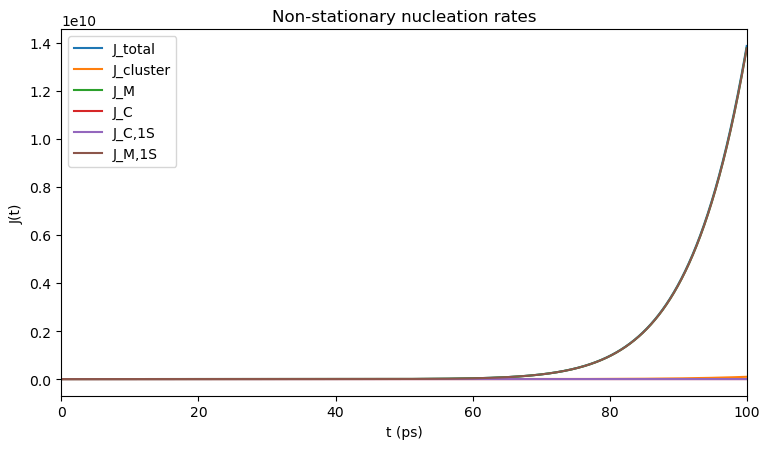

In [3]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# Units
# - Input time knobs in ps: t_max, max_step, dt_ps
# - Internal integration uses x = f0 * t (t in seconds)
# - Display/log uses ps
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 160.0
SCO_LIST = [6.559265115469421]                 # single s_co
s_cm = 5.743373201230127
gamma_co, gamma_cm, gamma_mo = 27.943965123920165, 25.118212926685757, 2.8257521972344097
C1_base = 8.17e28

# kinetics
f0 = 1.2165e8
g0 = 5.6e7
Q  = 0.5

# grid
M = 240

# ------------------------
# runtime window and sampling  ps → s 변환은 ps2s 사용
# ------------------------
t_max  = 100.0                 # [ps] total time window
STEPS  = 2000                 # number of steps
dt_ps  = t_max / STEPS        # [ps] = 0.03 ps
ps2s   = 1e-12                # ps → s

# 등간격 샘플링 0 .. 60 ps  2001 포인트  초 단위로 변환 후 사용
t_eval = np.linspace(0.0, t_max, STEPS + 1) * ps2s  # [s]
x_eval = f0 * t_eval                                 # x = f0 * t

# ------------------------
# integrator step ceiling
# ------------------------
max_step = dt_ps                                     # [ps] 0.03 ps
max_dx   = f0 * (max_step * ps2s)

# ------------------------
# plotting unit
# ------------------------
TIME_UNIT = "ps"
_unit_map = {"ps": 1e12, "ns": 1e9, "us": 1e6}
t_unit  = _unit_map[TIME_UNIT]
t_label = f"t ({TIME_UNIT})"

# ------------------------
# 1) triangular indexing  1 <= n <= i <= M-1
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i, n)] = k
            idx2pair.append((i, n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo):
    return -s_mo * i + gamma_mo * i**(2/3)

def w_cm(n):
    return -s_cm * n + gamma_cm * n**(2/3)

def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k, (i, n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1, 1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2 * gamma_mo / (3 * s_mo))**3
    n_star   = (2 * gamma_cm / (3 * s_cm))**3
    ico_star = (2 * gamma_co / (3 * s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 3) Attachment frequencies (w(i,n)을 사용하는 형태로 변경)
# ------------------------
def build_Wmap(W):
    """(i,n) → w(i,n) 매핑"""
    return {(i, n): W[PAIR2IDX[(i, n)]] for (i, n) in PAIR2IDX}

def f_in_val(i, n, s_co, Wmap):
    """
    f(i,n) = const * exp( (w(i,n) - w(i+1,n))/2 ) * i^(2/3)
    여기서 const = (1-Q)*f0 에 흡수
    """
    w_in = Wmap[(i, n)]
    # 경계에서 i+1 이 정의되지 않는 경우, w(i+1,n) 대신 w(i,n)을 사용 → exp(...) = 1
    w_ip1n = Wmap.get((i+1, n), w_in)
    return (1.0 - Q) * f0 * np.exp(0.5 * (w_in - w_ip1n)) * (i ** (2/3))

def g_in_val(i, n, Wmap):
    """
    g(i,n) = const * exp( (w(i,n) - w(i,n+1))/2 ) * n^(2/3)
    여기서 const = g0 에 흡수
    """
    w_in = Wmap[(i, n)]
    # 경계에서 n+1 이 정의되지 않는 경우, w(i,n+1) 대신 w(i,n)을 사용 → exp(...) = 1
    w_innp1 = Wmap.get((i, n+1), w_in)
    return g0 * np.exp(0.5 * (w_in - w_innp1)) * (n ** (2/3))

def k_ii_val(i, s_co, Wmap):
    """
    k(i,i)는 f 계열과 같은 prefactor에 Q를 곱해 분기하는 형태로 유지
    """
    w_ii = Wmap[(i, i)]
    w_ip1ip1 = Wmap.get((i+1, i+1), w_ii)
    return Q * f0 * np.exp(0.5 * (w_ii - w_ip1ip1)) * (i ** (2/3))

def build_coeffs(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)
    Wmap = build_Wmap(W)

    for k, (i, n) in enumerate(IDX2PAIR):
        if n < i:
            # forward flux 계수 (i → i+1, n 고정)
            b[k] = f_in_val(i, n, s_co, Wmap) / f0
            # forward flux 계수 (n → n+1, i 고정)
            d[k] = g_in_val(i, n, Wmap) / f0

            # backward (i-1,n) → (i,n)
            if i >= 2:
                a[k] = (f_in_val(i-1, n, s_co, Wmap) / f0) \
                       * np.exp(Wmap[(i, n)] - Wmap[(i-1, n)])

            # backward (i,n-1) → (i,n)
            if n >= 2:
                c[k] = (g_in_val(i, n-1, Wmap) / f0) \
                       * np.exp(Wmap[(i, n)] - Wmap[(i, n-1)])

        else:  # n == i (diagonal: (i,i))
            if i >= 2:
                e[k] = (k_ii_val(i-1, s_co, Wmap) / f0) \
                       * np.exp(Wmap[(i, i)] - Wmap[(i-1, i-1)])
            h[k] = (k_ii_val(i, s_co, Wmap) / f0)

    return a, b, c, d, e, h

# ------------------------
# 4) Sparse Jacobian pattern
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []

    def add(r, c):
        rows.append(r)
        cols.append(c)

    for k, (i, n) in enumerate(IDX2PAIR):
        add(k, k)
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)),
                      shape=(Ntri, Ntri))
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x domain: dF/dx
# ------------------------
def dFdx(x, F_flat, a, b, c, d, e, h):
    F = F_flat
    dF = np.zeros_like(F)

    # boundary F(1,1)=1
    F[PAIR2IDX[(1, 1)]] = 1.0

    for k, (i, n) in enumerate(IDX2PAIR):
        val = 0.0
        if n < i and i >= 2:
            val += a[k] * (F[PAIR2IDX[(i-1, n)]] - F[k])
        if n < i:
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            val -= b[k] * (F[k] - Fip)
        if n >= 2:
            val += c[k] * (F[PAIR2IDX[(i, n-1)]] - F[k])
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k] * (F[k] - Finp)
        if n == i:
            if i >= 2:
                val += e[k] * (F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k] * (F[k] - Fipp)
        dF[k] = val
    return dF

# ------------------------
# 6) Fluxes I, G, K
# ------------------------
def fluxes_IGK(F_flat, C, W, s_co):
    I_map = {}
    G_map = {}
    K_map = {}
    F = F_flat
    Wmap = build_Wmap(W)

    for (i, n), k in PAIR2IDX.items():
        Ckn = C[k]

        if n < i:
            # I: M → MO 방향 flux (i 증가)
            fval = f_in_val(i, n, s_co, Wmap)
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            I_map[(i, n)] = fval * Ckn * (F[k] - Fip)

        if n < i:
            # G: MO → CM 방향 flux (n 증가)
            gval = g_in_val(i, n, Wmap)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i, n)] = gval * Ckn * (F[k] - Finp)

        if n == i:
            # K: diagonal (i,i) ↔ (i+1,i+1)
            kval = k_ii_val(i, s_co, Wmap)
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i, i)] = kval * Ckn * (F[k] - Fipp)

    return I_map, G_map, K_map

# ------------------------
# 7) Non-stationary rates
# ------------------------
def compute_Js(F_flat, C, W, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, W, s_co)

    gi = lambda i, n: G_map.get((i, n), 0.0)
    ii = lambda i, n: I_map.get((i, n), 0.0)
    kk = lambda i: K_map.get((i, i), 0.0)

    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i, i) - gi(i, i-1)

    J_d = ii(i_star, 1) - sum(gi(i, 1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i, i)

    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)

    return {
        "J_d+com": J_dcom,
        "J_com":   J_com,
        "J_d":     J_d,
        "J_c":     J_c,
        "J_c,1S":  J_c_1S,
        "J_d,1S":  J_d_1S,
    }

# ------------------------
# 8) MAIN
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co} map 준비 시작")
    W, C = make_wC(s_co)
    a, b, c, d, e, h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co} 준비 완료")

    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1, 1)]] = 1.0

    # integrate in x domain
    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a, b, c, d, e, h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method="BDF",
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6,
        atol=1e-9,
        max_step=max_dx,
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    curves = {
        k: np.zeros_like(sol.t)
        for k in ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]
    }
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, W, s_co)
        for k in curves.keys():
            curves[k][j] = Js[k]
        if j % 100 == 0:
            # sol.t 는 x 이므로 t = x/f0  표시 단위는 ps
            t_disp = (x / f0) * t_unit
            print(f"[Progress] s_co={s_co} step {j}/{len(sol.t)-1}  t={t_disp:.3f} {TIME_UNIT}")

    print(f"[Done]  s_co={s_co} 계산 완료")

    label_map = {
        "J_d+com": "J_total",
        "J_com":   "J_cluster",
        "J_d":     "J_M",
        "J_c":     "J_C",
        "J_c,1S":  "J_C,1S",
        "J_d,1S":  "J_M,1S",
    }

    plt.figure(figsize=(7.8, 4.6))
    order = ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]
    # x축은 (sol.t/f0) [s] 를 ps 로 변환하여 플롯
    t_disp_all = (sol.t / f0) * t_unit
    for name in order:
        plt.plot(t_disp_all, curves[name], label=label_map[name])
    plt.xlabel(t_label)
    plt.ylabel("J(t)")
    plt.title("Non-stationary nucleation rates")
    plt.xlim(0.0, t_max)  # 이미 ps 단위로 변환된 축
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------
# 9) RUN
# ------------------------
if __name__ == "__main__":
    for sco in SCO_LIST:
        run_session(sco)


[Stage] s_co=6.559265115469421 map 준비 시작
[Done]  s_co=6.559265115469421 준비 완료
[Progress] s_co=6.559265115469421 step 0/2000  t=0.000 ps
[Progress] s_co=6.559265115469421 step 100/2000  t=5.000 ps
[Progress] s_co=6.559265115469421 step 200/2000  t=10.000 ps
[Progress] s_co=6.559265115469421 step 300/2000  t=15.000 ps
[Progress] s_co=6.559265115469421 step 400/2000  t=20.000 ps
[Progress] s_co=6.559265115469421 step 500/2000  t=25.000 ps
[Progress] s_co=6.559265115469421 step 600/2000  t=30.000 ps
[Progress] s_co=6.559265115469421 step 700/2000  t=35.000 ps
[Progress] s_co=6.559265115469421 step 800/2000  t=40.000 ps
[Progress] s_co=6.559265115469421 step 900/2000  t=45.000 ps
[Progress] s_co=6.559265115469421 step 1000/2000  t=50.000 ps
[Progress] s_co=6.559265115469421 step 1100/2000  t=55.000 ps
[Progress] s_co=6.559265115469421 step 1200/2000  t=60.000 ps
[Progress] s_co=6.559265115469421 step 1300/2000  t=65.000 ps
[Progress] s_co=6.559265115469421 step 1400/2000  t=70.000 ps
[Progr

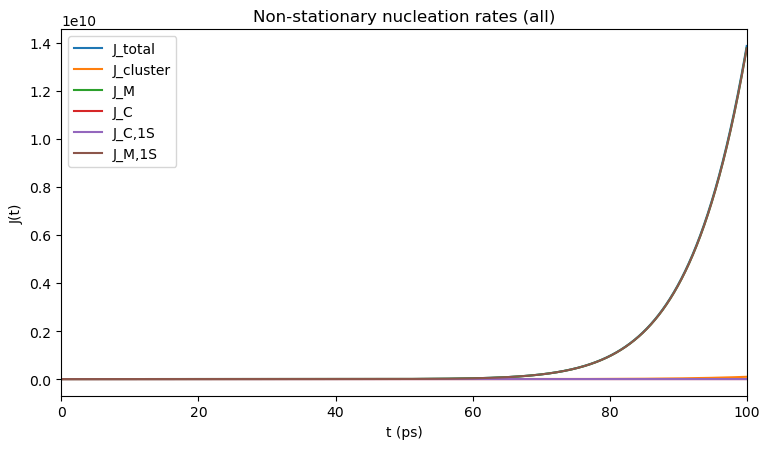

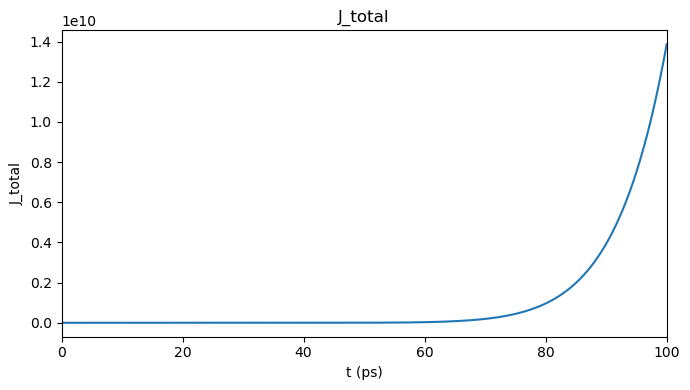

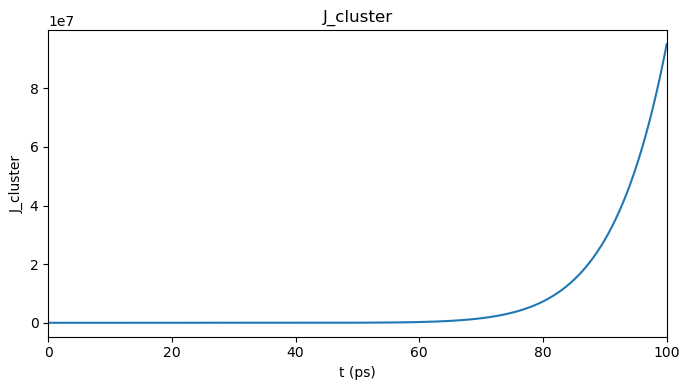

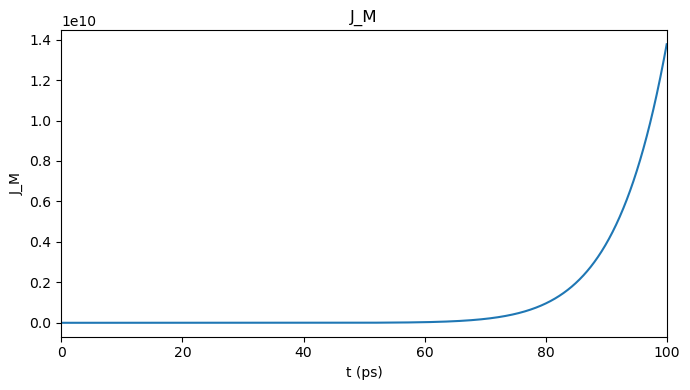

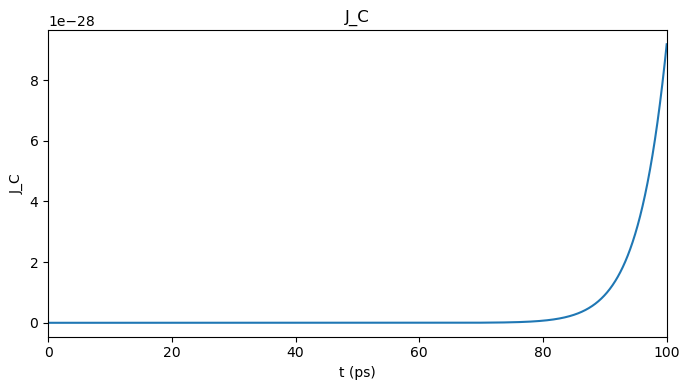

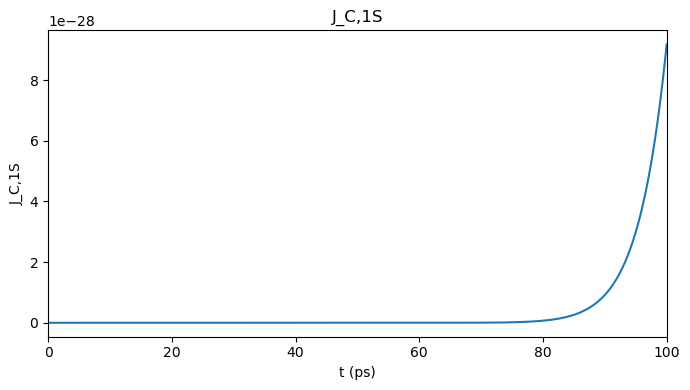

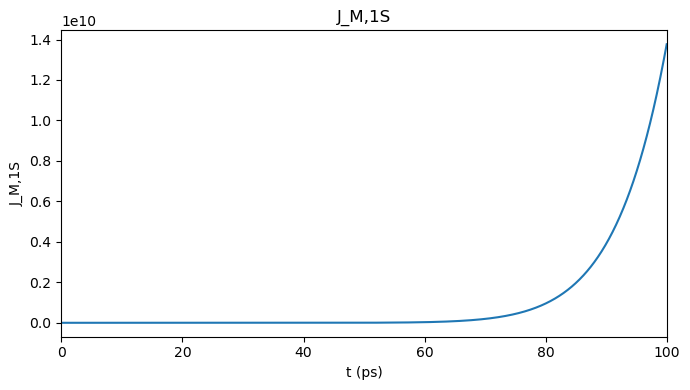

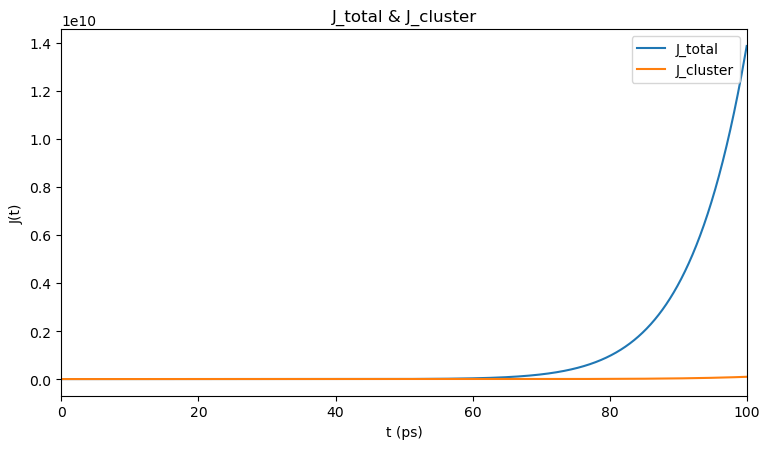

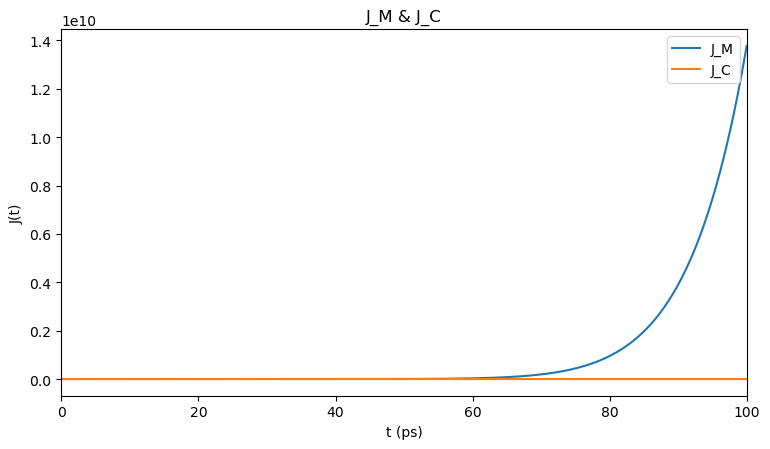

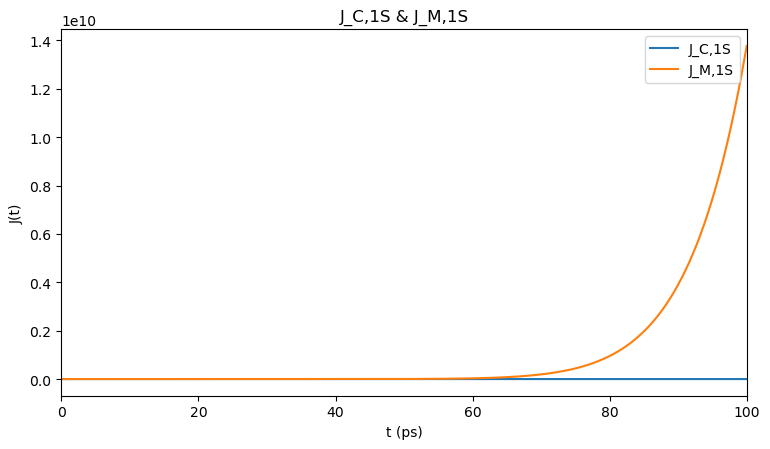

In [4]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# Units
# - Input time knobs in ps: t_max, max_step, dt_ps
# - Internal integration uses x = f0 * t (t in seconds)
# - Display/log uses ps
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 160.0
SCO_LIST = [6.559265115469421]                 # single s_co
s_cm = 5.743373201230127
gamma_co, gamma_cm, gamma_mo = 27.943965123920165, 25.118212926685757, 2.8257521972344097
C1_base = 8.17e28

# kinetics (from MD + CNT mapping)
f0 = 1.2165e8        # [1/s]
g0 = 5.6e7          # [1/s]
Q  = 0.5

# grid
M = 240

# ------------------------
# runtime window and sampling  ps → s 변환은 ps2s 사용
# ------------------------
t_max  = 100.0                 # [ps] total time window
STEPS  = 2000                  # number of steps
dt_ps  = t_max / STEPS         # [ps] = 0.05 ps
ps2s   = 1e-12                 # ps → s

# 등간격 샘플링 0 .. t_max ps  2001 포인트  초 단위로 변환 후 사용
t_eval = np.linspace(0.0, t_max, STEPS + 1) * ps2s  # [s]
x_eval = f0 * t_eval                                 # x = f0 * t

# ------------------------
# integrator step ceiling
# ------------------------
max_step = dt_ps                                     # [ps]
max_dx   = f0 * (max_step * ps2s)

# ------------------------
# plotting unit
# ------------------------
TIME_UNIT = "ps"
_unit_map = {"ps": 1e12, "ns": 1e9, "us": 1e6}
t_unit  = _unit_map[TIME_UNIT]
t_label = f"t ({TIME_UNIT})"

# ------------------------
# 1) triangular indexing  1 <= n <= i <= M-1
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i, n)] = k
            idx2pair.append((i, n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo):
    return -s_mo * i + gamma_mo * i**(2/3)

def w_cm(n):
    return -s_cm * n + gamma_cm * n**(2/3)

def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k, (i, n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1, 1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2 * gamma_mo / (3 * s_mo))**3
    n_star   = (2 * gamma_cm / (3 * s_cm))**3
    ico_star = (2 * gamma_co / (3 * s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 3) Attachment frequencies
# ------------------------
def build_Wmap(W):
    """(i,n) → w(i,n) 매핑"""
    return {(i, n): W[PAIR2IDX[(i, n)]] for (i, n) in PAIR2IDX}

def f_in_val(i, n, s_co, Wmap):
    """
    f(i,n) = const * exp( (w(i,n) - w(i+1,n))/2 ) * i^(2/3)
    여기서 const = (1-Q)*f0 에 흡수
    """
    w_in = Wmap[(i, n)]
    # 경계에서 i+1 이 정의되지 않는 경우, w(i+1,n) 대신 w(i,n)을 사용 → exp(...) = 1
    w_ip1n = Wmap.get((i+1, n), w_in)
    return (1.0 - Q) * f0 * np.exp(0.5 * (w_in - w_ip1n)) * (i ** (2/3))

def g_in_val(i, n, Wmap):
    """
    g(i,n) = const * exp( (w(i,n) - w(i,n+1))/2 ) * n^(2/3)
    여기서 const = g0 에 흡수
    """
    w_in = Wmap[(i, n)]
    # 경계에서 n+1 이 정의되지 않는 경우, w(i,n+1) 대신 w(i,n)을 사용 → exp(...) = 1
    w_innp1 = Wmap.get((i, n+1), w_in)
    return g0 * np.exp(0.5 * (w_in - w_innp1)) * (n ** (2/3))

def k_ii_val(i, s_co, Wmap):
    """
    k(i,i)는 f 계열과 같은 prefactor에 Q를 곱해 분기하는 형태로 유지
    """
    w_ii = Wmap[(i, i)]
    w_ip1ip1 = Wmap.get((i+1, i+1), w_ii)
    return Q * f0 * np.exp(0.5 * (w_ii - w_ip1ip1)) * (i ** (2/3))

def build_coeffs(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)
    Wmap = build_Wmap(W)

    for k, (i, n) in enumerate(IDX2PAIR):
        if n < i:
            # forward flux 계수 (i → i+1, n 고정)
            b[k] = f_in_val(i, n, s_co, Wmap) / f0
            # forward flux 계수 (n → n+1, i 고정)
            d[k] = g_in_val(i, n, Wmap) / f0

            # backward (i-1,n) → (i,n)
            if i >= 2:
                a[k] = (f_in_val(i-1, n, s_co, Wmap) / f0) \
                       * np.exp(Wmap[(i, n)] - Wmap[(i-1, n)])

            # backward (i,n-1) → (i,n)
            if n >= 2:
                c[k] = (g_in_val(i, n-1, Wmap) / f0) \
                       * np.exp(Wmap[(i, n)] - Wmap[(i, n-1)])

        else:  # n == i (diagonal: (i,i))
            if i >= 2:
                e[k] = (k_ii_val(i-1, s_co, Wmap) / f0) \
                       * np.exp(Wmap[(i, i)] - Wmap[(i-1, i-1)])
            h[k] = (k_ii_val(i, s_co, Wmap) / f0)

    return a, b, c, d, e, h

# ------------------------
# 4) Sparse Jacobian pattern
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []

    def add(r, c):
        rows.append(r)
        cols.append(c)

    for k, (i, n) in enumerate(IDX2PAIR):
        add(k, k)
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)),
                      shape=(Ntri, Ntri))
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x domain: dF/dx
# ------------------------
def dFdx(x, F_flat, a, b, c, d, e, h):
    F = F_flat
    dF = np.zeros_like(F)

    # boundary F(1,1)=1
    F[PAIR2IDX[(1, 1)]] = 1.0

    for k, (i, n) in enumerate(IDX2PAIR):
        val = 0.0
        if n < i and i >= 2:
            val += a[k] * (F[PAIR2IDX[(i-1, n)]] - F[k])
        if n < i:
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            val -= b[k] * (F[k] - Fip)
        if n >= 2:
            val += c[k] * (F[PAIR2IDX[(i, n-1)]] - F[k])
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k] * (F[k] - Finp)
        if n == i:
            if i >= 2:
                val += e[k] * (F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k] * (F[k] - Fipp)
        dF[k] = val
    return dF

# ------------------------
# 6) Fluxes I, G, K
# ------------------------
def fluxes_IGK(F_flat, C, W, s_co):
    I_map = {}
    G_map = {}
    K_map = {}
    F = F_flat
    Wmap = build_Wmap(W)

    for (i, n), k in PAIR2IDX.items():
        Ckn = C[k]

        if n < i:
            # I: M → MO 방향 flux (i 증가)
            fval = f_in_val(i, n, s_co, Wmap)
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            I_map[(i, n)] = fval * Ckn * (F[k] - Fip)

        if n < i:
            # G: MO → CM 방향 flux (n 증가)
            gval = g_in_val(i, n, Wmap)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i, n)] = gval * Ckn * (F[k] - Finp)

        if n == i:
            # K: diagonal (i,i) ↔ (i+1,i+1)
            kval = k_ii_val(i, s_co, Wmap)
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i, i)] = kval * Ckn * (F[k] - Fipp)

    return I_map, G_map, K_map

# ------------------------
# 7) Non-stationary rates
# ------------------------
def compute_Js(F_flat, C, W, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, W, s_co)

    gi = lambda i, n: G_map.get((i, n), 0.0)
    ii = lambda i, n: I_map.get((i, n), 0.0)
    kk = lambda i: K_map.get((i, i), 0.0)

    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i, i) - gi(i, i-1)

    J_d = ii(i_star, 1) - sum(gi(i, 1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i, i)

    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)

    return {
        "J_d+com": J_dcom,
        "J_com":   J_com,
        "J_d":     J_d,
        "J_c":     J_c,
        "J_c,1S":  J_c_1S,
        "J_d,1S":  J_d_1S,
    }

# ------------------------
# 8) MAIN
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co} map 준비 시작")
    W, C = make_wC(s_co)
    a, b, c, d, e, h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co} 준비 완료")

    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1, 1)]] = 1.0

    # integrate in x domain
    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a, b, c, d, e, h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method="BDF",
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6,
        atol=1e-9,
        max_step=max_dx,
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    curves = {
        k: np.zeros_like(sol.t)
        for k in ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]
    }
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, W, s_co)
        for k in curves.keys():
            curves[k][j] = Js[k]
        if j % 100 == 0:
            # sol.t 는 x 이므로 t = x/f0  표시 단위는 ps
            t_disp = (x / f0) * t_unit
            print(f"[Progress] s_co={s_co} step {j}/{len(sol.t)-1}  t={t_disp:.3f} {TIME_UNIT}")

    print(f"[Done]  s_co={s_co} 계산 완료")

    label_map = {
        "J_d+com": "J_total",
        "J_com":   "J_cluster",
        "J_d":     "J_M",
        "J_c":     "J_C",
        "J_c,1S":  "J_C,1S",
        "J_d,1S":  "J_M,1S",
    }
    order = ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]

    # 시간축 (ps 단위)
    t_disp_all = (sol.t / f0) * t_unit

    # --------- (1) 전체 곡선 한 번에 ---------
    plt.figure(figsize=(7.8, 4.6))
    for name in order:
        plt.plot(t_disp_all, curves[name], label=label_map[name])
    plt.xlabel(t_label)
    plt.ylabel("J(t)")
    plt.title("Non-stationary nucleation rates (all)")
    plt.xlim(0.0, t_max)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------- (2) 각 곡선을 개별 플롯 ---------
    for name in order:
        plt.figure(figsize=(7.0, 4.0))
        plt.plot(t_disp_all, curves[name])
        plt.xlabel(t_label)
        plt.ylabel(label_map[name])
        plt.title(label_map[name])
        plt.xlim(0.0, t_max)
        plt.tight_layout()
        plt.show()

    # --------- (3) 두 개씩 묶어서 플롯 ---------
    pair_sets = [
        ("J_d+com", "J_com"),     # total vs cluster
        ("J_d", "J_c"),           # metastable vs crystalline
        ("J_c,1S", "J_d,1S"),     # 1-step CNT limits
    ]
    for pair in pair_sets:
        plt.figure(figsize=(7.8, 4.6))
        for name in pair:
            plt.plot(t_disp_all, curves[name], label=label_map[name])
        plt.xlabel(t_label)
        plt.ylabel("J(t)")
        title_pair = " & ".join(label_map[n] for n in pair)
        plt.title(title_pair)
        plt.xlim(0.0, t_max)
        plt.legend()
        plt.tight_layout()
        plt.show()

# ------------------------
# 9) RUN
# ------------------------
if __name__ == "__main__":
    for sco in SCO_LIST:
        run_session(sco)


[Stage] s_co=6.559265115469421 map 준비 시작
[Done]  s_co=6.559265115469421 준비 완료
[Progress] s_co=6.559265115469421 step 0/2000  t=0.000 ps
[Progress] s_co=6.559265115469421 step 100/2000  t=5.000 ps
[Progress] s_co=6.559265115469421 step 200/2000  t=10.000 ps
[Progress] s_co=6.559265115469421 step 300/2000  t=15.000 ps
[Progress] s_co=6.559265115469421 step 400/2000  t=20.000 ps
[Progress] s_co=6.559265115469421 step 500/2000  t=25.000 ps
[Progress] s_co=6.559265115469421 step 600/2000  t=30.000 ps
[Progress] s_co=6.559265115469421 step 700/2000  t=35.000 ps
[Progress] s_co=6.559265115469421 step 800/2000  t=40.000 ps
[Progress] s_co=6.559265115469421 step 900/2000  t=45.000 ps
[Progress] s_co=6.559265115469421 step 1000/2000  t=50.000 ps
[Progress] s_co=6.559265115469421 step 1100/2000  t=55.000 ps
[Progress] s_co=6.559265115469421 step 1200/2000  t=60.000 ps
[Progress] s_co=6.559265115469421 step 1300/2000  t=65.000 ps
[Progress] s_co=6.559265115469421 step 1400/2000  t=70.000 ps
[Progr

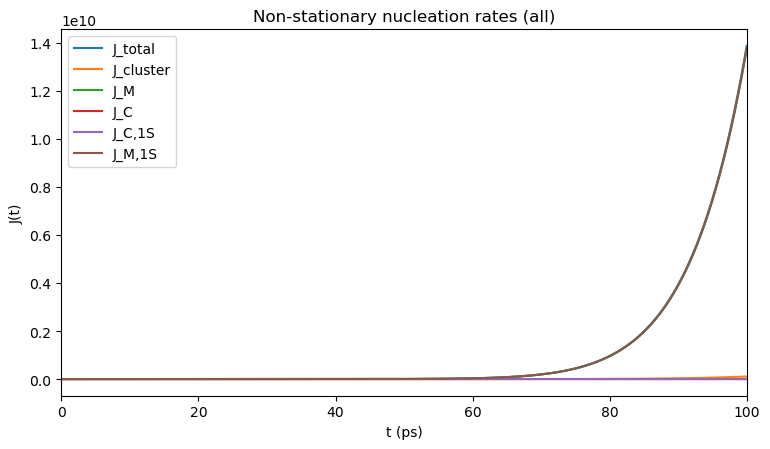

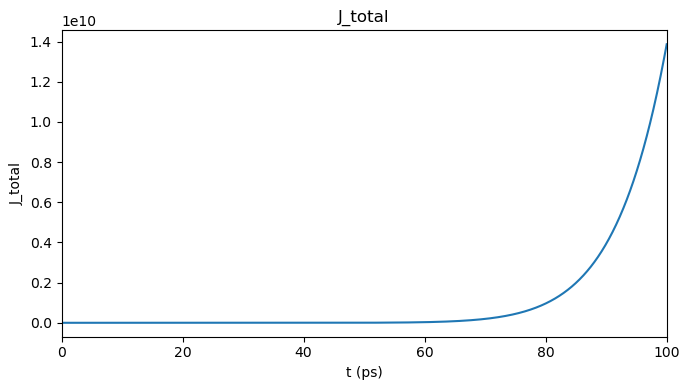

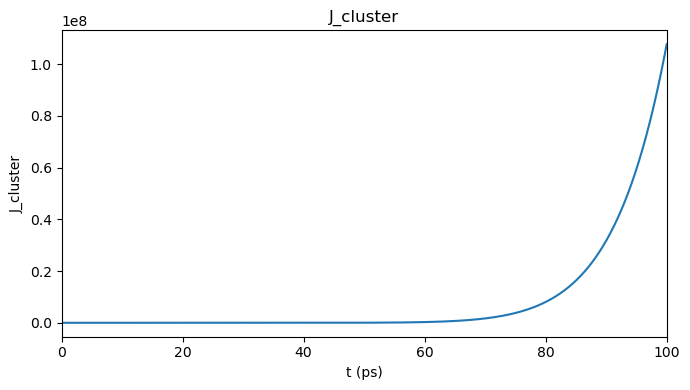

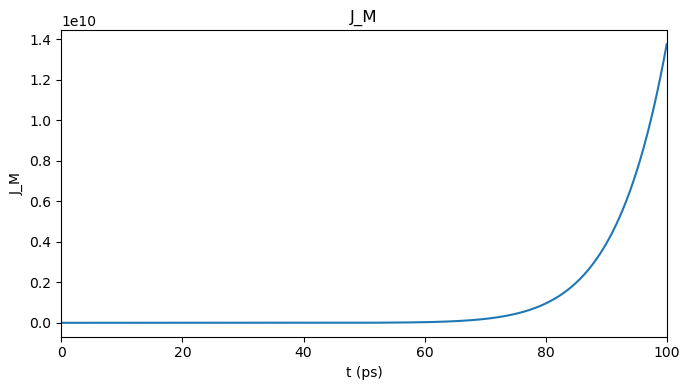

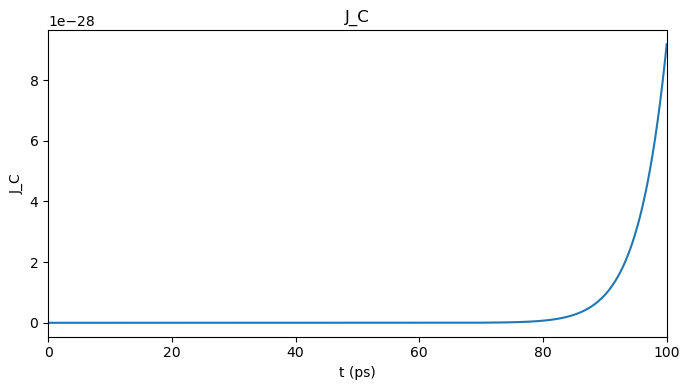

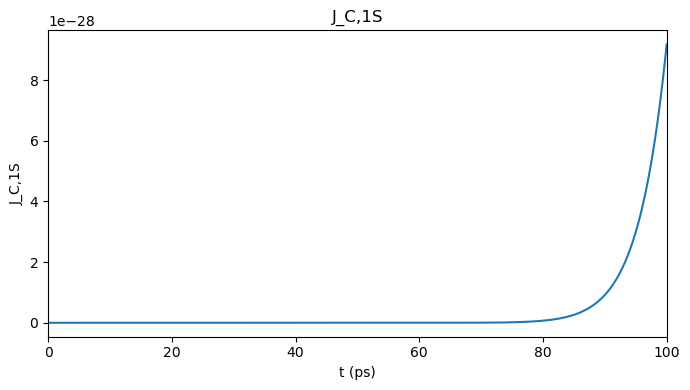

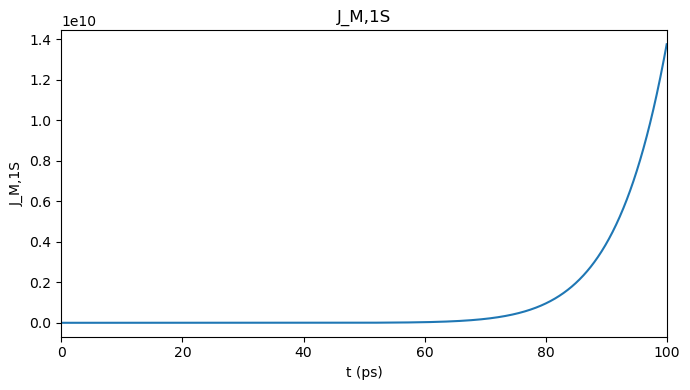

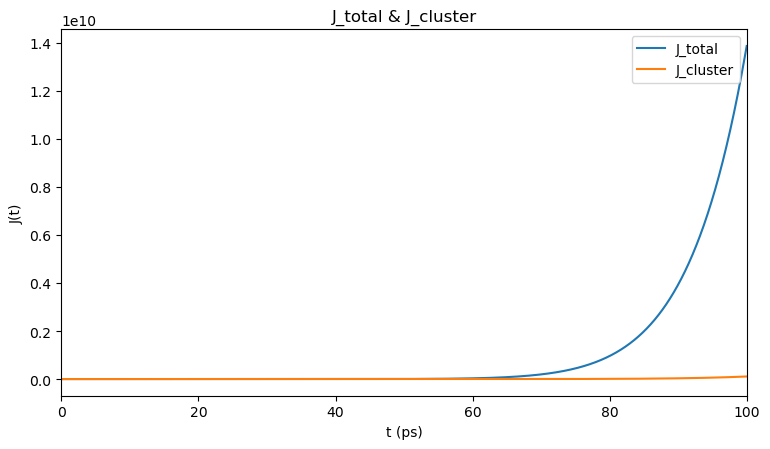

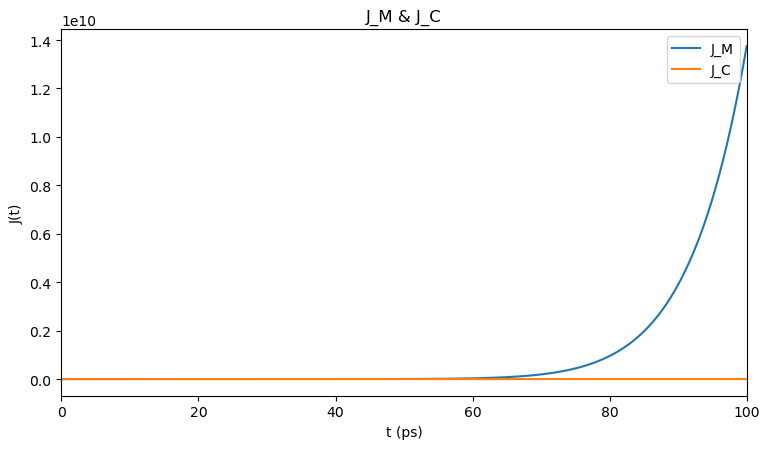

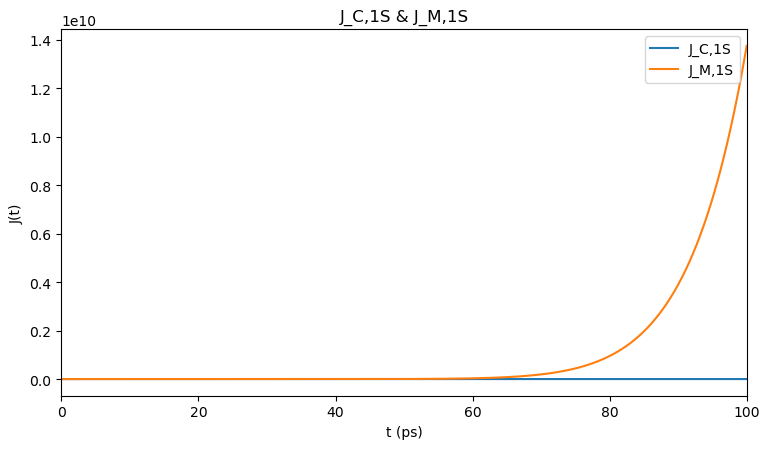

In [5]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# Units
# - Input time knobs in ps: t_max, max_step, dt_ps
# - Internal integration uses x = f0 * t (t in seconds)
# - Display/log uses ps
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 160.0
SCO_LIST = [6.559265115469421]                 # single s_co
s_cm = 5.743373201230127
gamma_co, gamma_cm, gamma_mo = 27.943965123920165, 25.118212926685757, 2.8257521972344097
C1_base = 8.17e28

# kinetics (from MD + CNT mapping)
f0 = 1.2165e8        # [1/s]
g0 = 4.0e7          # [1/s]
Q  = 0.5

# grid
M = 240

# ------------------------
# runtime window and sampling  ps → s 변환은 ps2s 사용
# ------------------------
t_max  = 100.0                 # [ps] total time window
STEPS  = 2000                  # number of steps
dt_ps  = t_max / STEPS         # [ps] = 0.05 ps
ps2s   = 1e-12                 # ps → s

# 등간격 샘플링 0 .. t_max ps  2001 포인트  초 단위로 변환 후 사용
t_eval = np.linspace(0.0, t_max, STEPS + 1) * ps2s  # [s]
x_eval = f0 * t_eval                                 # x = f0 * t

# ------------------------
# integrator step ceiling
# ------------------------
max_step = dt_ps                                     # [ps]
max_dx   = f0 * (max_step * ps2s)

# ------------------------
# plotting unit
# ------------------------
TIME_UNIT = "ps"
_unit_map = {"ps": 1e12, "ns": 1e9, "us": 1e6}
t_unit  = _unit_map[TIME_UNIT]
t_label = f"t ({TIME_UNIT})"

# ------------------------
# 1) triangular indexing  1 <= n <= i <= M-1
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i, n)] = k
            idx2pair.append((i, n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo):
    return -s_mo * i + gamma_mo * i**(2/3)

def w_cm(n):
    return -s_cm * n + gamma_cm * n**(2/3)

def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k, (i, n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1, 1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2 * gamma_mo / (3 * s_mo))**3
    n_star   = (2 * gamma_cm / (3 * s_cm))**3
    ico_star = (2 * gamma_co / (3 * s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 3) Attachment frequencies
# ------------------------
def build_Wmap(W):
    """(i,n) → w(i,n) 매핑"""
    return {(i, n): W[PAIR2IDX[(i, n)]] for (i, n) in PAIR2IDX}

def f_in_val(i, n, s_co, Wmap):
    """
    f(i,n) = const * exp( (w(i,n) - w(i+1,n))/2 ) * i^(2/3)
    여기서 const = (1-Q)*f0 에 흡수
    """
    w_in = Wmap[(i, n)]
    # 경계에서 i+1 이 정의되지 않는 경우, w(i+1,n) 대신 w(i,n)을 사용 → exp(...) = 1
    w_ip1n = Wmap.get((i+1, n), w_in)
    return (1.0 - Q) * f0 * np.exp(0.5 * (w_in - w_ip1n)) * (i ** (2/3))

def g_in_val(i, n, Wmap):
    """
    g(i,n) = const * exp( (w(i,n) - w(i,n+1))/2 ) * n^(2/3)
    여기서 const = g0 에 흡수
    """
    w_in = Wmap[(i, n)]
    # 경계에서 n+1 이 정의되지 않는 경우, w(i,n+1) 대신 w(i,n)을 사용 → exp(...) = 1
    w_innp1 = Wmap.get((i, n+1), w_in)
    return g0 * np.exp(0.5 * (w_in - w_innp1)) * (n ** (2/3))

def k_ii_val(i, s_co, Wmap):
    """
    k(i,i)는 f 계열과 같은 prefactor에 Q를 곱해 분기하는 형태로 유지
    """
    w_ii = Wmap[(i, i)]
    w_ip1ip1 = Wmap.get((i+1, i+1), w_ii)
    return Q * f0 * np.exp(0.5 * (w_ii - w_ip1ip1)) * (i ** (2/3))

def build_coeffs(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)
    Wmap = build_Wmap(W)

    for k, (i, n) in enumerate(IDX2PAIR):
        if n < i:
            # forward flux 계수 (i → i+1, n 고정)
            b[k] = f_in_val(i, n, s_co, Wmap) / f0
            # forward flux 계수 (n → n+1, i 고정)
            d[k] = g_in_val(i, n, Wmap) / f0

            # backward (i-1,n) → (i,n)
            if i >= 2:
                a[k] = (f_in_val(i-1, n, s_co, Wmap) / f0) \
                       * np.exp(Wmap[(i, n)] - Wmap[(i-1, n)])

            # backward (i,n-1) → (i,n)
            if n >= 2:
                c[k] = (g_in_val(i, n-1, Wmap) / f0) \
                       * np.exp(Wmap[(i, n)] - Wmap[(i, n-1)])

        else:  # n == i (diagonal: (i,i))
            if i >= 2:
                e[k] = (k_ii_val(i-1, s_co, Wmap) / f0) \
                       * np.exp(Wmap[(i, i)] - Wmap[(i-1, i-1)])
            h[k] = (k_ii_val(i, s_co, Wmap) / f0)

    return a, b, c, d, e, h

# ------------------------
# 4) Sparse Jacobian pattern
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []

    def add(r, c):
        rows.append(r)
        cols.append(c)

    for k, (i, n) in enumerate(IDX2PAIR):
        add(k, k)
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)),
                      shape=(Ntri, Ntri))
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x domain: dF/dx
# ------------------------
def dFdx(x, F_flat, a, b, c, d, e, h):
    F = F_flat
    dF = np.zeros_like(F)

    # boundary F(1,1)=1
    F[PAIR2IDX[(1, 1)]] = 1.0

    for k, (i, n) in enumerate(IDX2PAIR):
        val = 0.0
        if n < i and i >= 2:
            val += a[k] * (F[PAIR2IDX[(i-1, n)]] - F[k])
        if n < i:
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            val -= b[k] * (F[k] - Fip)
        if n >= 2:
            val += c[k] * (F[PAIR2IDX[(i, n-1)]] - F[k])
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k] * (F[k] - Finp)
        if n == i:
            if i >= 2:
                val += e[k] * (F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k] * (F[k] - Fipp)
        dF[k] = val
    return dF

# ------------------------
# 6) Fluxes I, G, K
# ------------------------
def fluxes_IGK(F_flat, C, W, s_co):
    I_map = {}
    G_map = {}
    K_map = {}
    F = F_flat
    Wmap = build_Wmap(W)

    for (i, n), k in PAIR2IDX.items():
        Ckn = C[k]

        if n < i:
            # I: M → MO 방향 flux (i 증가)
            fval = f_in_val(i, n, s_co, Wmap)
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            I_map[(i, n)] = fval * Ckn * (F[k] - Fip)

        if n < i:
            # G: MO → CM 방향 flux (n 증가)
            gval = g_in_val(i, n, Wmap)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i, n)] = gval * Ckn * (F[k] - Finp)

        if n == i:
            # K: diagonal (i,i) ↔ (i+1,i+1)
            kval = k_ii_val(i, s_co, Wmap)
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i, i)] = kval * Ckn * (F[k] - Fipp)

    return I_map, G_map, K_map

# ------------------------
# 7) Non-stationary rates
# ------------------------
def compute_Js(F_flat, C, W, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, W, s_co)

    gi = lambda i, n: G_map.get((i, n), 0.0)
    ii = lambda i, n: I_map.get((i, n), 0.0)
    kk = lambda i: K_map.get((i, i), 0.0)

    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i, i) - gi(i, i-1)

    J_d = ii(i_star, 1) - sum(gi(i, 1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i, i)

    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)

    return {
        "J_d+com": J_dcom,
        "J_com":   J_com,
        "J_d":     J_d,
        "J_c":     J_c,
        "J_c,1S":  J_c_1S,
        "J_d,1S":  J_d_1S,
    }

# ------------------------
# 8) MAIN
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co} map 준비 시작")
    W, C = make_wC(s_co)
    a, b, c, d, e, h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co} 준비 완료")

    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1, 1)]] = 1.0

    # integrate in x domain
    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a, b, c, d, e, h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method="BDF",
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6,
        atol=1e-9,
        max_step=max_dx,
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    curves = {
        k: np.zeros_like(sol.t)
        for k in ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]
    }
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, W, s_co)
        for k in curves.keys():
            curves[k][j] = Js[k]
        if j % 100 == 0:
            # sol.t 는 x 이므로 t = x/f0  표시 단위는 ps
            t_disp = (x / f0) * t_unit
            print(f"[Progress] s_co={s_co} step {j}/{len(sol.t)-1}  t={t_disp:.3f} {TIME_UNIT}")

    print(f"[Done]  s_co={s_co} 계산 완료")

    label_map = {
        "J_d+com": "J_total",
        "J_com":   "J_cluster",
        "J_d":     "J_M",
        "J_c":     "J_C",
        "J_c,1S":  "J_C,1S",
        "J_d,1S":  "J_M,1S",
    }
    order = ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]

    # 시간축 (ps 단위)
    t_disp_all = (sol.t / f0) * t_unit

    # --------- (1) 전체 곡선 한 번에 ---------
    plt.figure(figsize=(7.8, 4.6))
    for name in order:
        plt.plot(t_disp_all, curves[name], label=label_map[name])
    plt.xlabel(t_label)
    plt.ylabel("J(t)")
    plt.title("Non-stationary nucleation rates (all)")
    plt.xlim(0.0, t_max)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------- (2) 각 곡선을 개별 플롯 ---------
    for name in order:
        plt.figure(figsize=(7.0, 4.0))
        plt.plot(t_disp_all, curves[name])
        plt.xlabel(t_label)
        plt.ylabel(label_map[name])
        plt.title(label_map[name])
        plt.xlim(0.0, t_max)
        plt.tight_layout()
        plt.show()

    # --------- (3) 두 개씩 묶어서 플롯 ---------
    pair_sets = [
        ("J_d+com", "J_com"),     # total vs cluster
        ("J_d", "J_c"),           # metastable vs crystalline
        ("J_c,1S", "J_d,1S"),     # 1-step CNT limits
    ]
    for pair in pair_sets:
        plt.figure(figsize=(7.8, 4.6))
        for name in pair:
            plt.plot(t_disp_all, curves[name], label=label_map[name])
        plt.xlabel(t_label)
        plt.ylabel("J(t)")
        title_pair = " & ".join(label_map[n] for n in pair)
        plt.title(title_pair)
        plt.xlim(0.0, t_max)
        plt.legend()
        plt.tight_layout()
        plt.show()

# ------------------------
# 9) RUN
# ------------------------
if __name__ == "__main__":
    for sco in SCO_LIST:
        run_session(sco)


[Stage] s_co=6.559265115469421 map 준비 시작
[Done]  s_co=6.559265115469421 준비 완료
[Progress] s_co=6.559265115469421 step 0/2000  t=0.000 ps
[Progress] s_co=6.559265115469421 step 100/2000  t=5.000 ps
[Progress] s_co=6.559265115469421 step 200/2000  t=10.000 ps
[Progress] s_co=6.559265115469421 step 300/2000  t=15.000 ps
[Progress] s_co=6.559265115469421 step 400/2000  t=20.000 ps
[Progress] s_co=6.559265115469421 step 500/2000  t=25.000 ps
[Progress] s_co=6.559265115469421 step 600/2000  t=30.000 ps
[Progress] s_co=6.559265115469421 step 700/2000  t=35.000 ps
[Progress] s_co=6.559265115469421 step 800/2000  t=40.000 ps
[Progress] s_co=6.559265115469421 step 900/2000  t=45.000 ps
[Progress] s_co=6.559265115469421 step 1000/2000  t=50.000 ps
[Progress] s_co=6.559265115469421 step 1100/2000  t=55.000 ps
[Progress] s_co=6.559265115469421 step 1200/2000  t=60.000 ps
[Progress] s_co=6.559265115469421 step 1300/2000  t=65.000 ps
[Progress] s_co=6.559265115469421 step 1400/2000  t=70.000 ps
[Progr

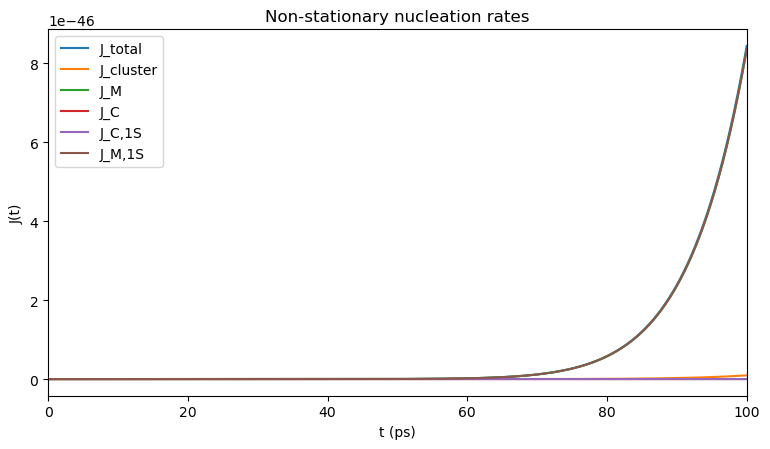

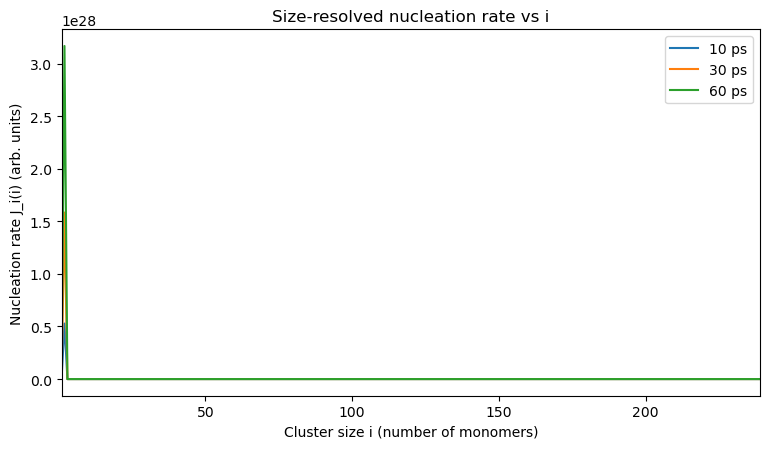

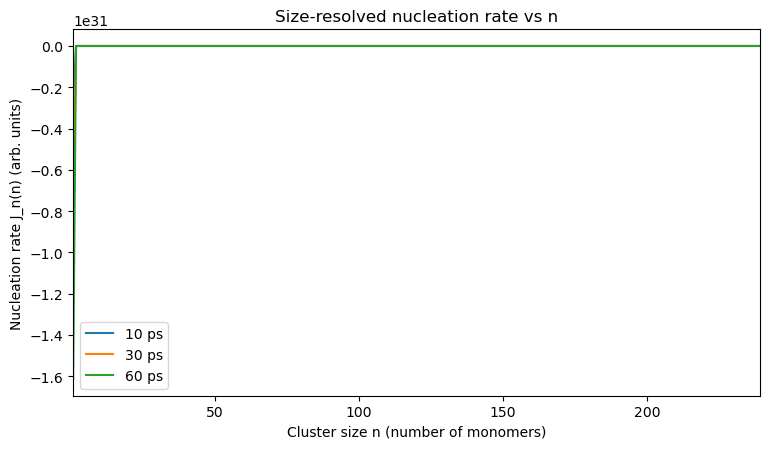

In [1]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# (time traces + size-resolved nucleation rates vs i, n)
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 160.0
SCO_LIST = [6.559265115469421]                 # single s_co
s_cm = 5.743373201230127
gamma_co, gamma_cm, gamma_mo = 27.943965123920165, 25.118212926685757, 2.8257521972344097
C1_base = 8.17e28

# kinetics
f0 = 6.85e3
g0 = 2.1e6
Q  = 0.5

# grid
M = 240

# ------------------------
# runtime window and sampling
# ------------------------
t_max  = 100.0                 # [ps] total time window
STEPS  = 2000                  # number of steps
dt_ps  = t_max / STEPS         # [ps]
ps2s   = 1e-12                 # ps → s

t_eval = np.linspace(0.0, t_max, STEPS + 1) * ps2s  # [s]
x_eval = f0 * t_eval                                 # x = f0 * t

# integrator step ceiling
max_step = dt_ps                                     # [ps]
max_dx   = f0 * (max_step * ps2s)

# plotting unit
TIME_UNIT = "ps"
_unit_map = {"ps": 1e12, "ns": 1e9, "us": 1e6}
t_unit  = _unit_map[TIME_UNIT]
t_label = f"t ({TIME_UNIT})"

# ------------------------
# 1) triangular indexing  1 <= n <= i <= M-1
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i, n)] = k
            idx2pair.append((i, n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo):
    return -s_mo * i + gamma_mo * i**(2/3)

def w_cm(n):
    return -s_cm * n + gamma_cm * n**(2/3)

def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k, (i, n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1, 1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2 * gamma_mo / (3 * s_mo))**3
    n_star   = (2 * gamma_cm / (3 * s_cm))**3
    ico_star = (2 * gamma_co / (3 * s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 3) Attachment frequencies
# ------------------------
def build_Wmap(W):
    """(i,n) → w(i,n)"""
    return {(i, n): W[PAIR2IDX[(i, n)]] for (i, n) in PAIR2IDX}

def f_in_val(i, n, s_co, Wmap):
    w_in = Wmap[(i, n)]
    w_ip1n = Wmap.get((i+1, n), w_in)
    return (1.0 - Q) * f0 * np.exp(0.5 * (w_in - w_ip1n)) * (i ** (2/3))

def g_in_val(i, n, Wmap):
    w_in = Wmap[(i, n)]
    w_innp1 = Wmap.get((i, n+1), w_in)
    return g0 * np.exp(0.5 * (w_in - w_innp1)) * (n ** (2/3))

def k_ii_val(i, s_co, Wmap):
    w_ii = Wmap[(i, i)]
    w_ip1ip1 = Wmap.get((i+1, i+1), w_ii)
    return Q * f0 * np.exp(0.5 * (w_ii - w_ip1ip1)) * (i ** (2/3))

def build_coeffs(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)
    Wmap = build_Wmap(W)

    for k, (i, n) in enumerate(IDX2PAIR):
        if n < i:
            b[k] = f_in_val(i, n, s_co, Wmap) / f0
            d[k] = g_in_val(i, n, Wmap) / f0
            if i >= 2:
                a[k] = (f_in_val(i-1, n, s_co, Wmap) / f0) \
                       * np.exp(Wmap[(i, n)] - Wmap[(i-1, n)])
            if n >= 2:
                c[k] = (g_in_val(i, n-1, Wmap) / f0) \
                       * np.exp(Wmap[(i, n)] - Wmap[(i, n-1)])
        else:  # n == i
            if i >= 2:
                e[k] = (k_ii_val(i-1, s_co, Wmap) / f0) \
                       * np.exp(Wmap[(i, i)] - Wmap[(i-1, i-1)])
            h[k] = (k_ii_val(i, s_co, Wmap) / f0)
    return a, b, c, d, e, h

# ------------------------
# 4) Sparse Jacobian pattern
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []

    def add(r, c):
        rows.append(r); cols.append(c)

    for k, (i, n) in enumerate(IDX2PAIR):
        add(k, k)
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)),
                      shape=(Ntri, Ntri))
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x domain: dF/dx
# ------------------------
def dFdx(x, F_flat, a, b, c, d, e, h):
    F = F_flat
    dF = np.zeros_like(F)

    # boundary F(1,1)=1
    F[PAIR2IDX[(1, 1)]] = 1.0

    for k, (i, n) in enumerate(IDX2PAIR):
        val = 0.0
        if n < i and i >= 2:
            val += a[k] * (F[PAIR2IDX[(i-1, n)]] - F[k])
        if n < i:
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            val -= b[k] * (F[k] - Fip)
        if n >= 2:
            val += c[k] * (F[PAIR2IDX[(i, n-1)]] - F[k])
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k] * (F[k] - Finp)
        if n == i:
            if i >= 2:
                val += e[k] * (F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k] * (F[k] - Fipp)
        dF[k] = val
    return dF

# ------------------------
# 6) Fluxes I, G, K
# ------------------------
def fluxes_IGK(F_flat, C, W, s_co):
    I_map = {}
    G_map = {}
    K_map = {}
    F = F_flat
    Wmap = build_Wmap(W)

    for (i, n), k in PAIR2IDX.items():
        Ckn = C[k]

        if n < i:
            fval = f_in_val(i, n, s_co, Wmap)
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            I_map[(i, n)] = fval * Ckn * (F[k] - Fip)

        if n < i:
            gval = g_in_val(i, n, Wmap)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i, n)] = gval * Ckn * (F[k] - Finp)

        if n == i:
            kval = k_ii_val(i, s_co, Wmap)
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i, i)] = kval * Ckn * (F[k] - Fipp)

    return I_map, G_map, K_map

# ------------------------
# 7) Non-stationary rates (scalar J(t))
# ------------------------
def compute_Js(F_flat, C, W, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, W, s_co)

    gi = lambda i, n: G_map.get((i, n), 0.0)
    ii = lambda i, n: I_map.get((i, n), 0.0)
    kk = lambda i: K_map.get((i, i), 0.0)

    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i, i) - gi(i, i-1)

    J_d = ii(i_star, 1) - sum(gi(i, 1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i, i)

    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)

    return {
        "J_d+com": J_dcom,
        "J_com":   J_com,
        "J_d":     J_d,
        "J_c":     J_c,
        "J_c,1S":  J_c_1S,
        "J_d,1S":  J_d_1S,
    }

# ------------------------
# 8) Size-resolved nucleation rate distributions
# ------------------------
def size_flux_distributions(F_flat, C, W, s_co):
    """
    From F_flat, C, W, s_co, compute
      J_i(i) = sum_n I(i,n)
      J_n(n) = sum_i G(i,n)
    as functions of size i and n respectively.
    """
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, W, s_co)

    Ji = np.zeros(M - 1)   # i = 1..M-1
    Jn = np.zeros(M - 1)   # n = 1..M-1

    # i-direction flux summed over n
    for (i, n), J in I_map.items():
        if 1 <= i <= M - 1:
            Ji[i - 1] += J

    # n-direction flux summed over i
    for (i, n), J in G_map.items():
        if 1 <= n <= M - 1:
            Jn[n - 1] += J

    return Ji, Jn

# (diag_Z_from_F 는 더 이상 사용하지 않지만, 필요하면 참고용으로 남겨둠)
def diag_Z_from_F(F_flat, C):
    Z_flat = C * F_flat
    Z_diag = np.zeros(M-1)
    for i in range(1, M):
        Z_diag[i-1] = Z_flat[PAIR2IDX[(i, i)]]
    return Z_diag

# ------------------------
# 9) MAIN
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co} map 준비 시작")
    W, C = make_wC(s_co)
    a, b, c, d, e, h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co} 준비 완료")

    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1, 1)]] = 1.0

    # integrate in x domain
    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a, b, c, d, e, h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method="BDF",
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6,
        atol=1e-9,
        max_step=max_dx,
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    # ---- (A) time-dependent J(t) ----
    curves = {
        k: np.zeros_like(sol.t)
        for k in ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]
    }
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, W, s_co)
        for k in curves.keys():
            curves[k][j] = Js[k]
        if j % 100 == 0:
            t_disp = (x / f0) * t_unit
            print(f"[Progress] s_co={s_co} step {j}/{len(sol.t)-1}  t={t_disp:.3f} {TIME_UNIT}")

    print(f"[Done]  s_co={s_co} 계산 완료")

    label_map = {
        "J_d+com": "J_total",
        "J_com":   "J_cluster",
        "J_d":     "J_M",
        "J_c":     "J_C",
        "J_c,1S":  "J_C,1S",
        "J_d,1S":  "J_M,1S",
    }

    # time axis in plotting unit
    t_disp_all = (sol.t / f0) * t_unit

    plt.figure(figsize=(7.8, 4.6))
    order = ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]
    for name in order:
        plt.plot(t_disp_all, curves[name], label=label_map[name])
    plt.xlabel(t_label)
    plt.ylabel("J(t)")
    plt.title("Non-stationary nucleation rates")
    plt.xlim(0.0, t_max)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- (B) size-resolved nucleation rates at 10, 30, 60 ps ----

    target_times_ps = [10.0, 30.0, 60.0]
    Ji_list = []   # J_i(i,t)
    Jn_list = []   # J_n(n,t)

    for t_ps in target_times_ps:
        # find closest index in solution
        j = int(round(t_ps / dt_ps))
        j = max(0, min(j, len(sol.t) - 1))

        F_now = sol.y[:, j]
        Ji, Jn = size_flux_distributions(F_now, C, W, s_co)
        Ji_list.append(Ji)
        Jn_list.append(Jn)

    i_array = np.arange(1, M)  # i = 1..M-1
    n_array = np.arange(1, M)  # n = 1..M-1

    # (B1) nucleation rate vs i
    plt.figure(figsize=(7.8, 4.6))
    for Ji, t_ps in zip(Ji_list, target_times_ps):
        plt.plot(i_array, Ji, label=f"{t_ps:.0f} ps")
    plt.xlabel("Cluster size i (number of monomers)")
    plt.ylabel("Nucleation rate J_i(i) (arb. units)")
    plt.title("Size-resolved nucleation rate vs i")
    plt.xlim(1, M - 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # (B2) nucleation rate vs n
    plt.figure(figsize=(7.8, 4.6))
    for Jn, t_ps in zip(Jn_list, target_times_ps):
        plt.plot(n_array, Jn, label=f"{t_ps:.0f} ps")
    plt.xlabel("Cluster size n (number of monomers)")
    plt.ylabel("Nucleation rate J_n(n) (arb. units)")
    plt.title("Size-resolved nucleation rate vs n")
    plt.xlim(1, M - 1)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    for sco in SCO_LIST:
        run_session(sco)


# Compare Old f(i,n) vs New f(i,n)

[Stage] s_co=2.5: precomputing W, C, coeffs, sparsity …
[Done]  s_co=2.5: coefficients (old & new) ready
[Solve] s_co=2.5: integrating OLD kinetics …
[Solve] s_co=2.5: integrating NEW kinetics …
[Progress] s_co=2.5: step 0/2999 (t=0.000 μs) done
[Progress] s_co=2.5: step 10/2999 (t=0.200 μs) done
[Progress] s_co=2.5: step 20/2999 (t=0.400 μs) done
[Progress] s_co=2.5: step 30/2999 (t=0.600 μs) done
[Progress] s_co=2.5: step 40/2999 (t=0.800 μs) done
[Progress] s_co=2.5: step 50/2999 (t=1.000 μs) done
[Progress] s_co=2.5: step 60/2999 (t=1.200 μs) done
[Progress] s_co=2.5: step 70/2999 (t=1.400 μs) done
[Progress] s_co=2.5: step 80/2999 (t=1.601 μs) done
[Progress] s_co=2.5: step 90/2999 (t=1.801 μs) done
[Progress] s_co=2.5: step 100/2999 (t=2.001 μs) done
[Progress] s_co=2.5: step 110/2999 (t=2.201 μs) done
[Progress] s_co=2.5: step 120/2999 (t=2.401 μs) done
[Progress] s_co=2.5: step 130/2999 (t=2.601 μs) done
[Progress] s_co=2.5: step 140/2999 (t=2.801 μs) done
[Progress] s_co=2.5: 

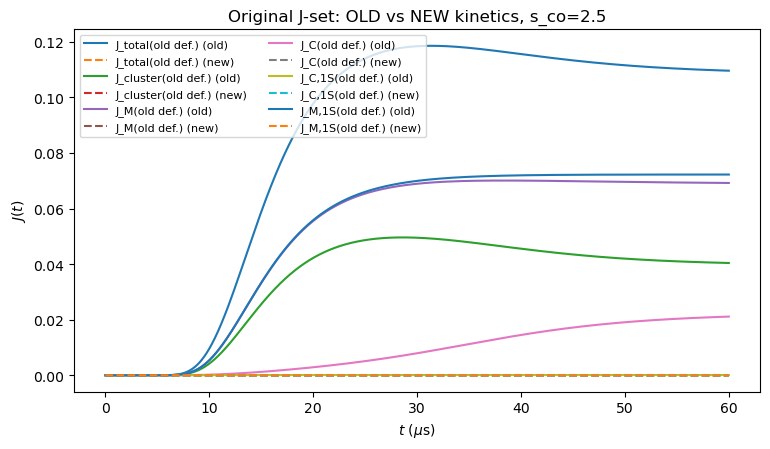

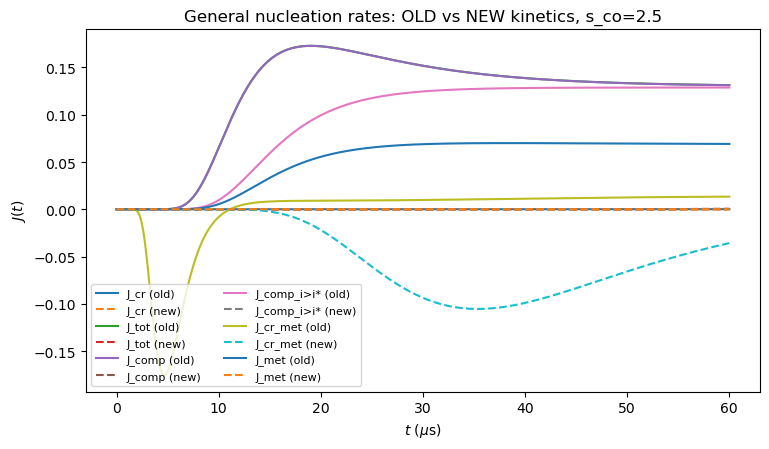

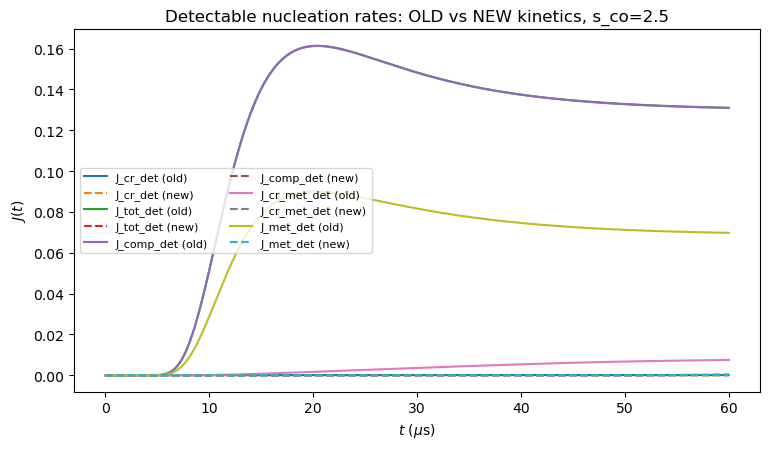

[Stage] s_co=3.0: precomputing W, C, coeffs, sparsity …
[Done]  s_co=3.0: coefficients (old & new) ready
[Solve] s_co=3.0: integrating OLD kinetics …
[Solve] s_co=3.0: integrating NEW kinetics …
[Progress] s_co=3.0: step 0/2999 (t=0.000 μs) done
[Progress] s_co=3.0: step 10/2999 (t=0.200 μs) done
[Progress] s_co=3.0: step 20/2999 (t=0.400 μs) done
[Progress] s_co=3.0: step 30/2999 (t=0.600 μs) done
[Progress] s_co=3.0: step 40/2999 (t=0.800 μs) done
[Progress] s_co=3.0: step 50/2999 (t=1.000 μs) done
[Progress] s_co=3.0: step 60/2999 (t=1.200 μs) done
[Progress] s_co=3.0: step 70/2999 (t=1.400 μs) done
[Progress] s_co=3.0: step 80/2999 (t=1.601 μs) done
[Progress] s_co=3.0: step 90/2999 (t=1.801 μs) done
[Progress] s_co=3.0: step 100/2999 (t=2.001 μs) done
[Progress] s_co=3.0: step 110/2999 (t=2.201 μs) done
[Progress] s_co=3.0: step 120/2999 (t=2.401 μs) done
[Progress] s_co=3.0: step 130/2999 (t=2.601 μs) done
[Progress] s_co=3.0: step 140/2999 (t=2.801 μs) done
[Progress] s_co=3.0: 

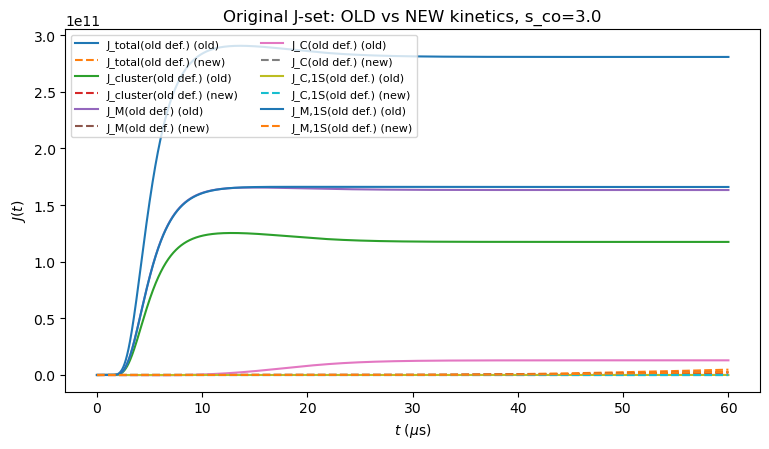

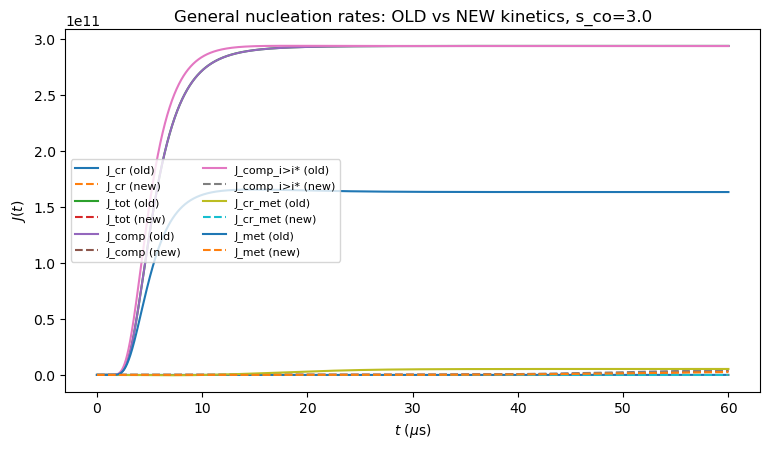

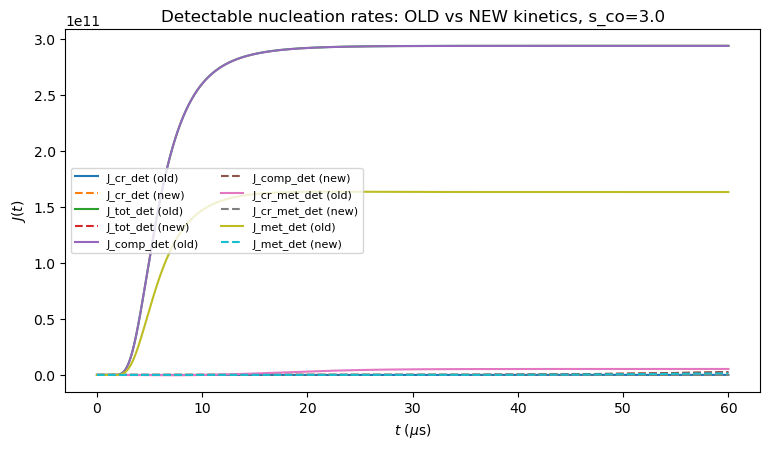

[Stage] s_co=5.0: precomputing W, C, coeffs, sparsity …
[Done]  s_co=5.0: coefficients (old & new) ready
[Solve] s_co=5.0: integrating OLD kinetics …
[Solve] s_co=5.0: integrating NEW kinetics …
[Progress] s_co=5.0: step 0/2999 (t=0.000 μs) done
[Progress] s_co=5.0: step 10/2999 (t=0.200 μs) done
[Progress] s_co=5.0: step 20/2999 (t=0.400 μs) done
[Progress] s_co=5.0: step 30/2999 (t=0.600 μs) done
[Progress] s_co=5.0: step 40/2999 (t=0.800 μs) done
[Progress] s_co=5.0: step 50/2999 (t=1.000 μs) done
[Progress] s_co=5.0: step 60/2999 (t=1.200 μs) done
[Progress] s_co=5.0: step 70/2999 (t=1.400 μs) done
[Progress] s_co=5.0: step 80/2999 (t=1.601 μs) done
[Progress] s_co=5.0: step 90/2999 (t=1.801 μs) done
[Progress] s_co=5.0: step 100/2999 (t=2.001 μs) done
[Progress] s_co=5.0: step 110/2999 (t=2.201 μs) done
[Progress] s_co=5.0: step 120/2999 (t=2.401 μs) done
[Progress] s_co=5.0: step 130/2999 (t=2.601 μs) done
[Progress] s_co=5.0: step 140/2999 (t=2.801 μs) done
[Progress] s_co=5.0: 

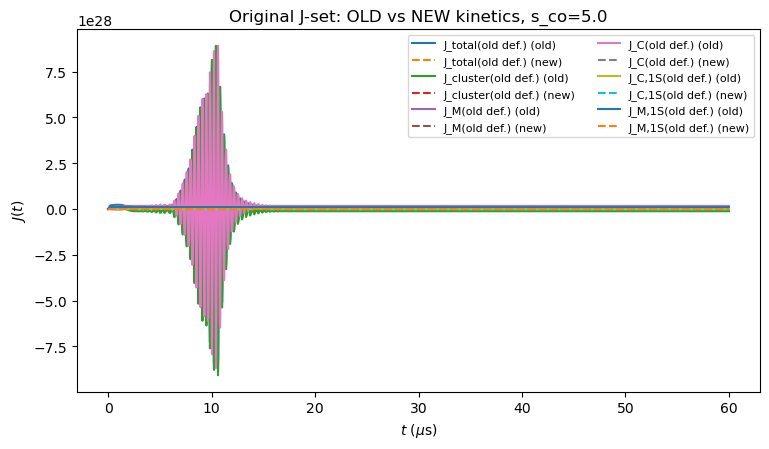

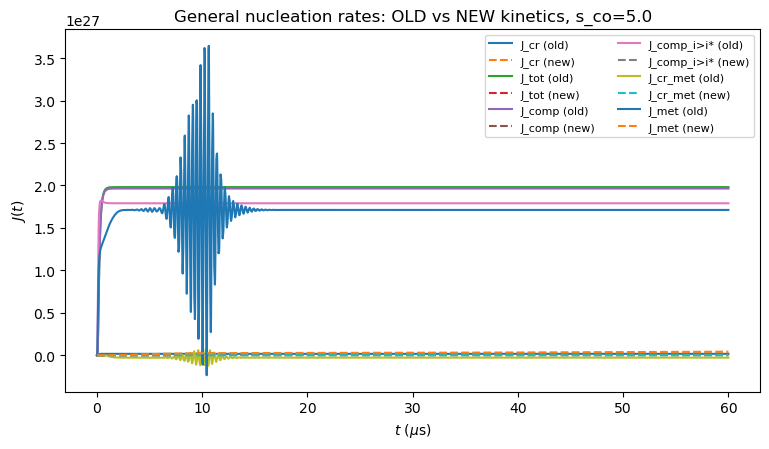

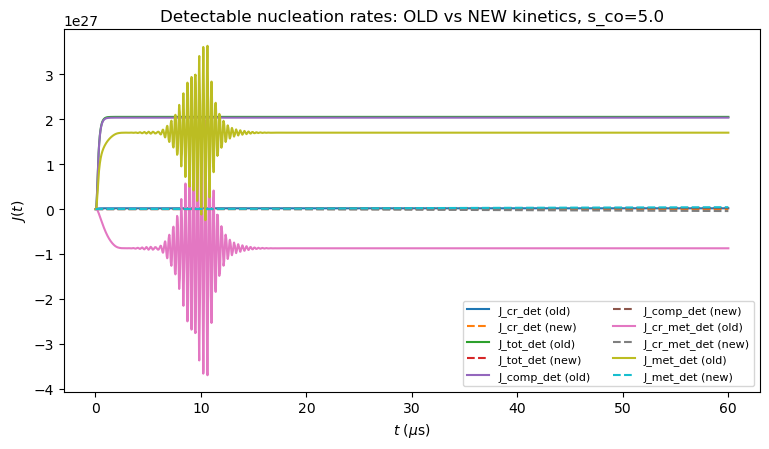

In [1]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# Old vs New kinetics (attachment frequencies) comparison
# - Old: power-law fi ~ i^(2/3), gi ~ n^(2/3), ki ~ i^(2/3)
# - New: Boltzmann-symmetric rates with exp[-Δw/2]
# - Uses SciencePlots style if available
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Optional: SciencePlots for nicer figures
# ------------------------------------------------------------
try:
    import scienceplots  # pip install SciencePlots
    plt.style.use(['science', 'no-latex'])  # or ['science', 'notebook']
except Exception:
    # Fallback to default matplotlib style if SciencePlots not installed
    pass

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 220.0
SCO_LIST = [2.5, 3.0, 5.0]
s_cm = 0.5
gamma_co, gamma_cm, gamma_mo = 15.4, 2.6, 12.8  # gamma_co = gamma_cm + gamma_mo

# kinetic prefactors (they play role of f0, g0 in both old & new models)
f0 = 1.0e5
g0 = 2.0e7
Q  = 0.5

C1_base = 1.6e21  # C1 = C1_base * exp(s_co)
M = 240           # maximum i-index (we use 1 <= n <= i <= M-1)

# runtime window & sampling
t_max  = 60e-6               # 60 microseconds (physical time t in seconds)
N_eval = 3000                # number of output samples
t_eval = np.linspace(0.0, t_max, N_eval)

# solver works in x = f0 * t
x_eval = f0 * t_eval
max_step = 1e-7              # sec
max_dx   = f0 * max_step     # x-domain step ceiling

# ------------------------
# 1) UTILS: triangular indexing (1 <= n <= i <= M-1)
# ------------------------
def tri_index_maps(M):
    """
    Map between (i,n) with 1 <= n <= i <= M-1 and a flat index k in [0, Ntri).
    """
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i, n)] = k
            idx2pair.append((i, n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo):
    return -s_mo * i + gamma_mo * i**(2/3)

def w_cm(n):
    return -s_cm * n + gamma_cm * n**(2/3)

def w_total_ij(i, n, s_co):
    """
    Total dimensionless work w(i,n) = w_mo(i) + w_cm(n)
    for composite cluster of size (i,n).
    """
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    """
    Precompute:
      - W[k]   = w_total_ij(i,n,s_co) for all (i,n) in triangular grid
      - C[k]   = equilibrium cluster concentration C(i,n)
    """
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)

    for k, (i, n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)

    w11 = w_total_ij(1, 1, s_co)
    # C(i,n) ∝ exp(w11 - w(i,n))
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    """
    Critical sizes i*, n*, i_co* from CNT formulas.
    """
    s_mo = s_co - s_cm
    i_star   = (2*gamma_mo / (3*s_mo))**3
    n_star   = (2*gamma_cm / (3*s_cm))**3
    ico_star = (2*gamma_co / (3*s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ============================================================
# 3) Attachment frequencies: OLD vs NEW
# ============================================================

# ------------------------
# 3A) OLD model: simple power-law CNT-type
#       fi ~ i^(2/3), gi ~ n^(2/3), ki ~ i^(2/3)
# ------------------------
def f_in_val_old(i, s_co):
    """
    Old OP-attachment along i: f_i ∝ exp(s_co) * i^(2/3)
    Used for transitions (i,n) <-> (i+1,n) with n < i.
    """
    return (1.0 - Q) * f0 * np.exp(s_co) * (i**(2/3))

def g_in_val_old(n):
    """
    Old C-in-MP attachment along n: g_n ∝ exp(s_cm) * n^(2/3)
    Used for transitions (i,n) <-> (i,n+1) with n < i.
    """
    return g0 * np.exp(s_cm) * (n**(2/3))

def k_ii_val_old(i, s_co):
    """
    Old direct-crystal OP channel along diagonal:
    k_i ∝ exp(s_co) * i^(2/3)
    Used for (i,i) <-> (i+1,i+1).
    """
    return Q * f0 * np.exp(s_co) * (i**(2/3))

def build_coeffs_old(W, s_co):
    """
    Build coefficients (a,b,c,d,e,h) in dF/dx for OLD kinetics.
    The structure follows Eq. (S19)-type discretization:
      - a,b : i-direction (OP attachment)
      - c,d : n-direction (C-in-MP attachment)
      - e,h : diagonal K-channel (crystal in O-phase)
    Coefficients are scaled by 1/f0 so that dF/dx uses dimensionless x.
    """
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)

    Wmap = {(i, n): W[PAIR2IDX[(i, n)]] for (i, n) in PAIR2IDX}

    for k, (i, n) in enumerate(IDX2PAIR):
        if n < i:
            # forward i-direction (i,n) -> (i+1,n)
            b[k] = f_in_val_old(i, s_co) / f0
            # forward n-direction (i,n) -> (i,n+1)
            d[k] = g_in_val_old(n) / f0

            # backward i-direction (i,n) -> (i-1,n)
            if i >= 2:
                a[k] = (f_in_val_old(i-1, s_co) / f0) * \
                       np.exp(Wmap[(i, n)] - Wmap[(i-1, n)])

            # backward n-direction (i,n) -> (i,n-1)
            if n >= 2:
                c[k] = (g_in_val_old(n-1) / f0) * \
                       np.exp(Wmap[(i, n)] - Wmap[(i, n-1)])
        else:
            # n == i: only diagonal K-channel
            if i >= 2:
                e[k] = (k_ii_val_old(i-1, s_co) / f0) * \
                       np.exp(Wmap[(i, i)] - Wmap[(i-1, i-1)])
            h[k] = (k_ii_val_old(i, s_co) / f0)

    return a, b, c, d, e, h

# ------------------------
# 3B) NEW model: Boltzmann-symmetric attachment frequencies
#       f^+ ~ exp[-(w(i,n) - w(i+1,n))/2] * i^(2/3)
#       g^+ ~ exp[-(w(i,n) - w(i,n+1))/2] * n^(2/3)
#       k^+ ~ exp[-(w(i,i) - w(i+1,i+1))/2] * i^(2/3)
# ------------------------
def f_plus_new(i, n, s_co):
    """
    New forward OP-attachment rate along i:
      (i, n) -> (i+1, n)
    with symmetric Arrhenius-type factor exp[-Δw/2].

    f^+(i,n) = (1-Q) * f0
               * exp( -[w(i,n) - w(i+1,n)] / 2 )
               * i^(2/3)

    We allow 1 <= n <= i <= M-1 because f(i-1,n) with n = i-1
    appears in the backward coefficient for (i,n).
    """
    if not (1 <= n <= i <= M-1):
        return 0.0

    w_in   = w_total_ij(i,   n, s_co)
    w_ip1n = w_total_ij(i+1, n, s_co)  # i+1 can be M (outside grid but fine for w)
    expo   = np.exp(-(w_in - w_ip1n) / 2.0)
    return (1.0 - Q) * f0 * expo * (i ** (2.0/3.0))

def g_plus_new(i, n, s_co):
    """
    New forward C-in-MP attachment along n:
      (i, n) -> (i, n+1),  for 1 <= n < i.

    g^+(i,n) = g0
               * exp( -[w(i,n) - w(i,n+1)] / 2 )
               * n^(2/3)
    """
    if not (1 <= n < i <= M-1):
        return 0.0

    w_in    = w_total_ij(i, n,   s_co)
    w_inp1  = w_total_ij(i, n+1, s_co)
    expo    = np.exp(-(w_in - w_inp1) / 2.0)
    return g0 * expo * (n ** (2.0/3.0))

def k_plus_new(i, s_co):
    """
    New forward direct-crystal (diagonal) channel:
      (i, i) -> (i+1, i+1)

    k^+(i,i) = Q * f0
               * exp( -[w(i,i) - w(i+1,i+1)] / 2 )
               * i^(2/3)
    """
    if not (1 <= i <= M-1):
        return 0.0

    w_ii     = w_total_ij(i,   i,   s_co)
    w_ip1ip1 = w_total_ij(i+1, i+1, s_co)
    expo     = np.exp(-(w_ii - w_ip1ip1) / 2.0)
    return Q * f0 * expo * (i ** (2.0/3.0))

def build_coeffs_new(W, s_co):
    """
    Build coefficients (a,b,c,d,e,h) in dF/dx for NEW kinetics.
    Forward rates are f_plus_new, g_plus_new, k_plus_new.
    Backward rates are obtained via detailed balance with C(i,n),
    which leads to the same structure as in the old build_coeffs,
    but with f_plus_new, g_plus_new, k_plus_new as "forward" ones.
    """
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)

    Wmap = {(i, n): W[PAIR2IDX[(i, n)]] for (i, n) in PAIR2IDX}

    for k, (i, n) in enumerate(IDX2PAIR):
        if n < i:
            # forward i-direction (i,n) -> (i+1,n)
            b[k] = f_plus_new(i, n, s_co) / f0

            # forward n-direction (i,n) -> (i,n+1)
            d[k] = g_plus_new(i, n, s_co) / f0

            # backward i-direction (i,n) -> (i-1,n)
            if i >= 2 and n <= i-1:
                a[k] = (f_plus_new(i-1, n, s_co) / f0) * \
                       np.exp(Wmap[(i, n)] - Wmap[(i-1, n)])

            # backward n-direction (i,n) -> (i,n-1)
            if n >= 2:
                c[k] = (g_plus_new(i, n-1, s_co) / f0) * \
                       np.exp(Wmap[(i, n)] - Wmap[(i, n-1)])
        else:
            # n == i: diagonal K-channel only (no I or G here)
            if i >= 2:
                e[k] = (k_plus_new(i-1, s_co) / f0) * \
                       np.exp(Wmap[(i, i)] - Wmap[(i-1, i-1)])
            h[k] = k_plus_new(i, s_co) / f0

    return a, b, c, d, e, h

# ------------------------
# 4) Sparse Jacobian pattern (neighbor stencil)
# ------------------------
def jac_sparsity_pattern(M):
    """
    Construct sparsity pattern for Jacobian of dF/dx operator.
    Same stencil for old/new; coefficients differ but pattern identical.
    """
    rows, cols = [], []

    def add(r, c):
        rows.append(r); cols.append(c)

    for k, (i, n) in enumerate(IDX2PAIR):
        # self
        add(k, k)

        # (i-1, n)
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])

        # (i+1, n)
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])

        # (i, n-1)
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])

        # (i, n+1)
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])

        # diagonal neighbors when n == i
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix(
        (np.ones(len(rows), dtype=bool), (rows, cols)),
        shape=(Ntri, Ntri)
    )
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x-domain: dF/dx (shared by old & new, coeffs differ)
# ------------------------
def dFdx(x, F_flat, a, b, c, d, e, h):
    """
    Backward equation in x = f0 t:
      dF/dx = L[F]
    where L is linear operator built from (a,b,c,d,e,h).
    """
    F = F_flat
    dF = np.zeros_like(F)

    # boundary condition: F(1,1) = 1 at all times
    F[PAIR2IDX[(1, 1)]] = 1.0

    for k, (i, n) in enumerate(IDX2PAIR):
        val = 0.0

        # a(F_{i-1,n} - F_{i,n})
        if n < i and i >= 2:
            val += a[k] * (F[PAIR2IDX[(i-1, n)]] - F[k])

        # - b(F_{i,n} - F_{i+1,n})
        if n < i:
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            val -= b[k] * (F[k] - Fip)

        # c(F_{i,n-1} - F_{i,n})
        if n >= 2:
            val += c[k] * (F[PAIR2IDX[(i, n-1)]] - F[k])

        # - d(F_{i,n} - F_{i,n+1})
        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k] * (F[k] - Finp)

        # diagonal channel: + e(F_{i-1,i-1}-F_{i,i}) - h(F_{i,i}-F_{i+1,i+1})
        if n == i:
            if i >= 2:
                val += e[k] * (F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k] * (F[k] - Fipp)

        dF[k] = val

    return dF

# ------------------------
# 6) Fluxes I,G,K (OLD vs NEW)
# ------------------------
def fluxes_IGK_old(F_flat, C, s_co):
    """
    Flux maps (I,G,K) for OLD kinetics.
    Returns dictionaries:
      I_map[(i,n)], G_map[(i,n)], K_map[(i,i)]
    """
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat

    for (i, n), k in PAIR2IDX.items():
        Ckn = C[k]

        # I_{i,n} (n < i)
        if n < i:
            fval = f_in_val_old(i, s_co)
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            I_map[(i, n)] = fval * Ckn * (F[k] - Fip)

        # G_{i,n} (n < i)
        if n < i:
            gval = g_in_val_old(n)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i, n)] = gval * Ckn * (F[k] - Finp)

        # K_{i,i}
        if n == i:
            kval = k_ii_val_old(i, s_co)
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i, i)] = kval * Ckn * (F[k] - Fipp)

    return I_map, G_map, K_map

def fluxes_IGK_new(F_flat, C, s_co):
    """
    Flux maps (I,G,K) for NEW kinetics.
    Same structure as old, but using f_plus_new, g_plus_new, k_plus_new.
    """
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat

    for (i, n), k in PAIR2IDX.items():
        Ckn = C[k]

        # I_{i,n} (n < i)
        if n < i:
            fval = f_plus_new(i, n, s_co)
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            I_map[(i, n)] = fval * Ckn * (F[k] - Fip)

        # G_{i,n} (n < i)
        if n < i:
            gval = g_plus_new(i, n, s_co)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i, n)] = gval * Ckn * (F[k] - Finp)

        # K_{i,i}
        if n == i:
            kval = k_plus_new(i, s_co)
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i, i)] = kval * Ckn * (F[k] - Fipp)

    return I_map, G_map, K_map

# ------------------------
# 7) Nucleation rates J from flux maps
# ------------------------
def Js_from_fluxes(I_map, G_map, K_map, s_co):
    """
    Original Kashchiev J-set from I,G,K fluxes:
      J_d+com, J_com, J_d, J_c, J_c,1S, J_d,1S
    """
    i_star, n_star, ico_star = crit_sizes(s_co)

    gi = lambda i, n: G_map.get((i, n), 0.0)
    ii = lambda i, n: I_map.get((i, n), 0.0)
    kk = lambda i:    K_map.get((i, i), 0.0)

    # J_{d+com}
    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i, i) - gi(i, i-1)

    # J_d
    J_d = ii(i_star, 1) - sum(gi(i, 1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    # J_c
    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i, i)

    # 1S limits (within same flux framework)
    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)

    return {
        "J_d+com": J_dcom,
        "J_com":   J_com,
        "J_d":     J_d,
        "J_c":     J_c,
        "J_c,1S":  J_c_1S,
        "J_d,1S":  J_d_1S
    }

def Js_from_fluxes_figure(I_map, G_map, K_map, s_co, d=None):
    """
    Figure-based J-set (general & detectable):
      - J_cr, J_tot, J_comp, J_comp_i>i*, J_cr_met, J_met
      - J_cr_det, J_tot_det, J_comp_det, J_cr_met_det, J_met_det
    Implementation is identical to your previous compute_Js_from_figure,
    but takes flux maps directly.
    """
    i_star, n_star, ico_star = crit_sizes(s_co)

    # default dividing index: d = i_co* + 1 (max M-1)
    if d is None:
        d = min(ico_star + 1, M - 1)

    def I(i, n):
        return I_map.get((i, n), 0.0)

    def G(i, n):
        return G_map.get((i, n), 0.0)

    def K_diag(i):
        return K_map.get((i, i), 0.0)

    # J_cr^det
    J_cr_det = K_diag(d) + sum(
        G(i, i) - I(i, i) for i in range(d, M)
    )

    # J_cr
    J_cr = K_diag(ico_star) + sum(
        G(i, i) - I(i, i) for i in range(ico_star, M)
    )

    # J_tot^det
    J_tot_det = K_diag(d) + sum(
        I(d, n) for n in range(1, d + 1)
    )

    # J_tot
    J_tot = K_diag(ico_star) + sum(
        I(ico_star, n) for n in range(1, ico_star + 1)
    )

    # J_comp^det
    J_comp_det = (
        sum(I(d, n) for n in range(1, d + 1)) +
        sum(I(i, i) - G(i, i) for i in range(d, M))
    )

    # J_comp
    J_comp = (
        sum(I(ico_star, n) for n in range(1, ico_star + 1)) +
        sum(I(i, i) - G(i, i) for i in range(ico_star, M))
    )

    # J_comp, i>i*
    J_comp_i_gt_istar = (
        sum(I(i_star, n) for n in range(1, i_star + 1)) +
        sum(I(i, i) - G(i, i) for i in range(i_star, M))
    )

    # J_cr,met^det
    J_cr_met_det = (
        sum(I(i, i) for i in range(d, M)) +
        sum(G(i, d) - G(i, i) for i in range(d, M))
    )

    # J_cr,met
    J_cr_met = (
        sum(I(i, i) for i in range(n_star, M)) +
        sum(G(i, n_star) - G(i, i) for i in range(n_star, M))
    )

    # J_met^det
    J_met_det = I(d, 1) - sum(
        G(i, 1) for i in range(d, M)
    )

    # J_met
    J_met = I(i_star, 1) - sum(
        G(i, 1) for i in range(i_star, M)
    )

    return {
        "J_cr_det":      J_cr_det,
        "J_cr":          J_cr,
        "J_tot_det":     J_tot_det,
        "J_tot":         J_tot,
        "J_comp_det":    J_comp_det,
        "J_comp":        J_comp,
        "J_comp_i>i*":   J_comp_i_gt_istar,
        "J_cr_met_det":  J_cr_met_det,
        "J_cr_met":      J_cr_met,
        "J_met_det":     J_met_det,
        "J_met":         J_met,
    }

# Convenience wrappers (keep old signature if needed elsewhere)
def compute_Js(F_flat, C, s_co, flux_func=fluxes_IGK_old):
    I_map, G_map, K_map = flux_func(F_flat, C, s_co)
    return Js_from_fluxes(I_map, G_map, K_map, s_co)

def compute_Js_from_figure(F_flat, C, s_co, flux_func=fluxes_IGK_old, d=None):
    I_map, G_map, K_map = flux_func(F_flat, C, s_co)
    return Js_from_fluxes_figure(I_map, G_map, K_map, s_co, d=d)

# ------------------------
# 8) MAIN SESSION: old vs new kinetics
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co}: precomputing W, C, coeffs, sparsity …")
    W, C = make_wC(s_co)

    # build coefficients for OLD and NEW kinetics
    a_old, b_old, c_old, d_old, e_old, h_old = build_coeffs_old(W, s_co)
    a_new, b_new, c_new, d_new, e_new, h_new = build_coeffs_new(W, s_co)
    print(f"[Done]  s_co={s_co}: coefficients (old & new) ready")

    # Initial condition: F(1,1) = 1, others 0
    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1, 1)]] = 1.0

    # BDF integration in x with jac_sparsity & max_step
    print(f"[Solve] s_co={s_co}: integrating OLD kinetics …")
    sol_old = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a_old, b_old, c_old, d_old, e_old, h_old),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method='BDF',
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6,
        atol=1e-9,
        max_step=max_dx
    )
    if not sol_old.success:
        raise RuntimeError(f"[OLD] solve_ivp failed: {sol_old.message}")

    print(f"[Solve] s_co={s_co}: integrating NEW kinetics …")
    sol_new = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a_new, b_new, c_new, d_new, e_new, h_new),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method='BDF',
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6,
        atol=1e-9,
        max_step=max_dx
    )
    if not sol_new.success:
        raise RuntimeError(f"[NEW] solve_ivp failed: {sol_new.message}")

    # Time grid (same for old & new since t_eval is fixed)
    t_x   = sol_old.t        # x = f0 t
    t_us  = t_x / f0 * 1e6   # physical time in microseconds

    # ---- allocate rate curves ----
    old_names = ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]
    general_names = ["J_cr", "J_tot", "J_comp", "J_comp_i>i*", "J_cr_met", "J_met"]
    det_names     = ["J_cr_det", "J_tot_det", "J_comp_det", "J_cr_met_det", "J_met_det"]

    curves_orig_old = {k: np.zeros_like(t_x) for k in old_names}
    curves_orig_new = {k: np.zeros_like(t_x) for k in old_names}
    curves_gen_old  = {k: np.zeros_like(t_x) for k in general_names}
    curves_gen_new  = {k: np.zeros_like(t_x) for k in general_names}
    curves_det_old  = {k: np.zeros_like(t_x) for k in det_names}
    curves_det_new  = {k: np.zeros_like(t_x) for k in det_names}

    # ---- time loop: fill all curves for OLD & NEW ----
    for j, x in enumerate(t_x):
        F_old = sol_old.y[:, j]
        F_new = sol_new.y[:, j]

        # flux maps for OLD & NEW
        I_old, G_old, K_old = fluxes_IGK_old(F_old, C, s_co)
        I_new, G_new, K_new = fluxes_IGK_new(F_new, C, s_co)

        # original J-set
        Js_old_orig = Js_from_fluxes(I_old, G_old, K_old, s_co)
        Js_new_orig = Js_from_fluxes(I_new, G_new, K_new, s_co)

        # figure-based general/detectable J-sets
        Js_old_fig = Js_from_fluxes_figure(I_old, G_old, K_old, s_co)
        Js_new_fig = Js_from_fluxes_figure(I_new, G_new, K_new, s_co)

        # store
        for name in old_names:
            curves_orig_old[name][j] = Js_old_orig[name]
            curves_orig_new[name][j] = Js_new_orig[name]

        for name in general_names:
            curves_gen_old[name][j] = Js_old_fig[name]
            curves_gen_new[name][j] = Js_new_fig[name]

        for name in det_names:
            curves_det_old[name][j] = Js_old_fig[name]
            curves_det_new[name][j] = Js_new_fig[name]

        if j % 10 == 0:
            print(f"[Progress] s_co={s_co}: step {j}/{len(t_x)-1} "
                  f"(t={x/f0*1e6:.3f} μs) done")

    print(f"[Done]  s_co={s_co}: OLD vs NEW kinetics — all rates computed")

    # ---- final values printout ----
    t_final_us = t_x[-1] / f0 * 1e6
    print(f"\n[Rates] s_co={s_co}: final J values at t={t_final_us:.3f} μs")

    print("  --- General (theoretical), OLD kinetics ---")
    for name in general_names:
        print(f"    {name:12s} = {curves_gen_old[name][-1]: .5e}")

    print("  --- General (theoretical), NEW kinetics ---")
    for name in general_names:
        print(f"    {name:12s} = {curves_gen_new[name][-1]: .5e}")

    print("  --- Detectable (d = i_co* + 1), OLD kinetics ---")
    for name in det_names:
        print(f"    {name:12s} = {curves_det_old[name][-1]: .5e}")

    print("  --- Detectable (d = i_co* + 1), NEW kinetics ---")
    for name in det_names:
        print(f"    {name:12s} = {curves_det_new[name][-1]: .5e}")
    print()

    # ------------------------
    # 9) PLOTTING: Old vs New (SciencePlots style)
    # ------------------------

    # (A) Original nucleation rate set: all on one plot, old vs new
    label_map_orig = {
        "J_d+com": "J_total(old def.)",
        "J_com":   "J_cluster(old def.)",
        "J_d":     "J_M(old def.)",
        "J_c":     "J_C(old def.)",
        "J_c,1S":  "J_C,1S(old def.)",
        "J_d,1S":  "J_M,1S(old def.)"
    }

    plt.figure(figsize=(7.8, 4.6))
    for name in old_names:
        plt.plot(t_us, curves_orig_old[name],
                 label=f"{label_map_orig[name]} (old)")
        plt.plot(t_us, curves_orig_new[name],
                 linestyle="--",
                 label=f"{label_map_orig[name]} (new)")
    plt.xlabel(r"$t$ ($\mu$s)")
    plt.ylabel(r"$J(t)$")
    plt.title(f"Original J-set: OLD vs NEW kinetics, s_co={s_co}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    # (B) General J-set: J_cr, J_tot, J_comp, J_comp_i>i*, J_cr_met, J_met
    plt.figure(figsize=(7.8, 4.6))
    for name in general_names:
        plt.plot(t_us, curves_gen_old[name],
                 label=f"{name} (old)")
        plt.plot(t_us, curves_gen_new[name],
                 linestyle="--",
                 label=f"{name} (new)")
    plt.xlabel(r"$t$ ($\mu$s)")
    plt.ylabel(r"$J(t)$")
    plt.title(f"General nucleation rates: OLD vs NEW kinetics, s_co={s_co}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    # (C) Detectable J-set: J_cr_det, J_tot_det, J_comp_det, J_cr_met_det, J_met_det
    plt.figure(figsize=(7.8, 4.6))
    for name in det_names:
        plt.plot(t_us, curves_det_old[name],
                 label=f"{name} (old)")
        plt.plot(t_us, curves_det_new[name],
                 linestyle="--",
                 label=f"{name} (new)")
    plt.xlabel(r"$t$ ($\mu$s)")
    plt.ylabel(r"$J(t)$")
    plt.title(f"Detectable nucleation rates: OLD vs NEW kinetics, s_co={s_co}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

# ------------------------
# 10) RUN over all s_co in SCO_LIST
# ------------------------
for sco in SCO_LIST:
    run_session(sco)


# Compare old vs new seperate plot

[Stage] s_co=2.5: precomputing W, C, coeffs …
[Done]  s_co=2.5: coeffs ready
[Solve] s_co=2.5: integrating OLD, t_max=60.00 μs …
[Solve] s_co=2.5: integrating NEW, t_max=0.60 ms …
[OLD] s_co=2.5: step 0/2999, t=0.000 μs
[OLD] s_co=2.5: step 200/2999, t=4.001 μs
[OLD] s_co=2.5: step 400/2999, t=8.003 μs
[OLD] s_co=2.5: step 600/2999, t=12.004 μs
[OLD] s_co=2.5: step 800/2999, t=16.005 μs
[OLD] s_co=2.5: step 1000/2999, t=20.007 μs
[OLD] s_co=2.5: step 1200/2999, t=24.008 μs
[OLD] s_co=2.5: step 1400/2999, t=28.009 μs
[OLD] s_co=2.5: step 1600/2999, t=32.011 μs
[OLD] s_co=2.5: step 1800/2999, t=36.012 μs
[OLD] s_co=2.5: step 2000/2999, t=40.013 μs
[OLD] s_co=2.5: step 2200/2999, t=44.015 μs
[OLD] s_co=2.5: step 2400/2999, t=48.016 μs
[OLD] s_co=2.5: step 2600/2999, t=52.017 μs
[OLD] s_co=2.5: step 2800/2999, t=56.019 μs
[NEW] s_co=2.5: step 0/2999, t=0.000 μs
[NEW] s_co=2.5: step 200/2999, t=40.013 μs
[NEW] s_co=2.5: step 400/2999, t=80.027 μs
[NEW] s_co=2.5: step 600/2999, t=120.040 μs


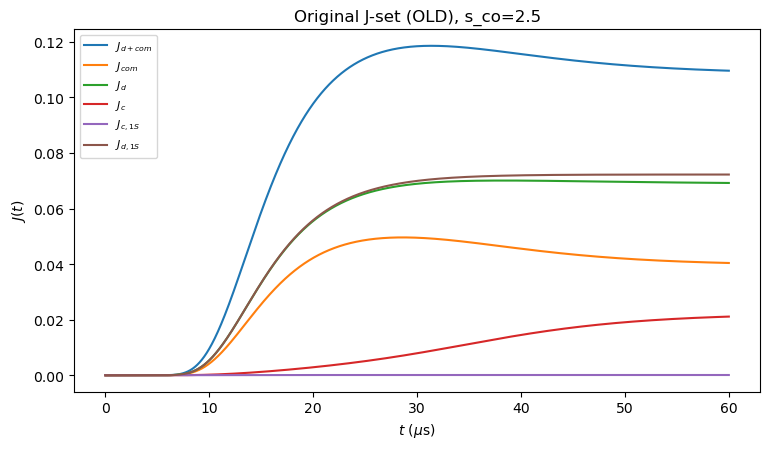

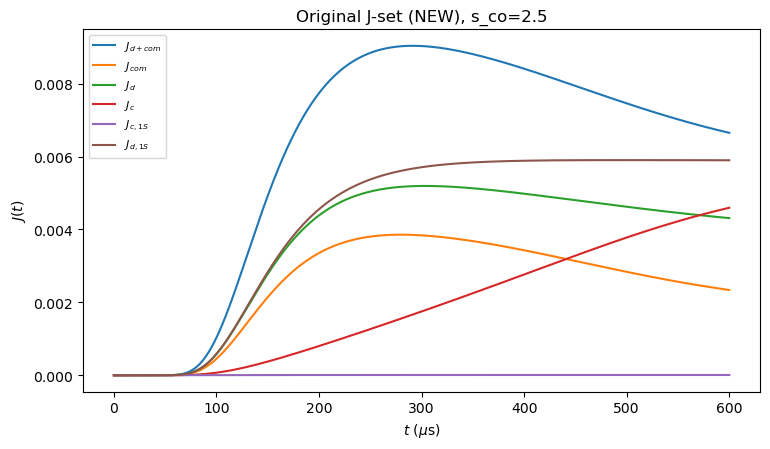

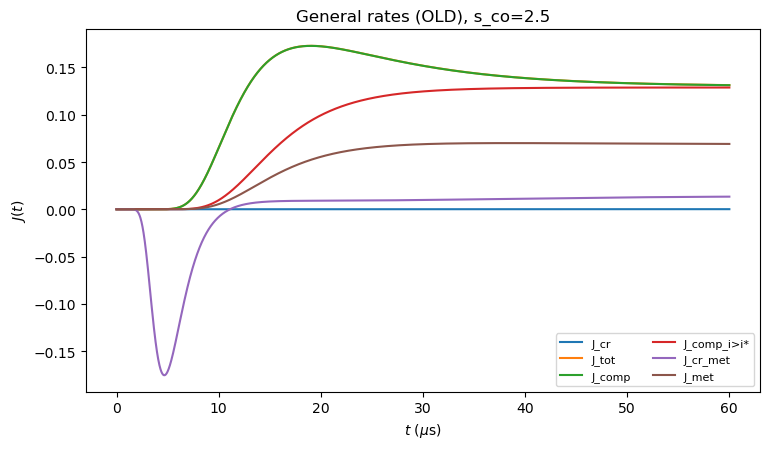

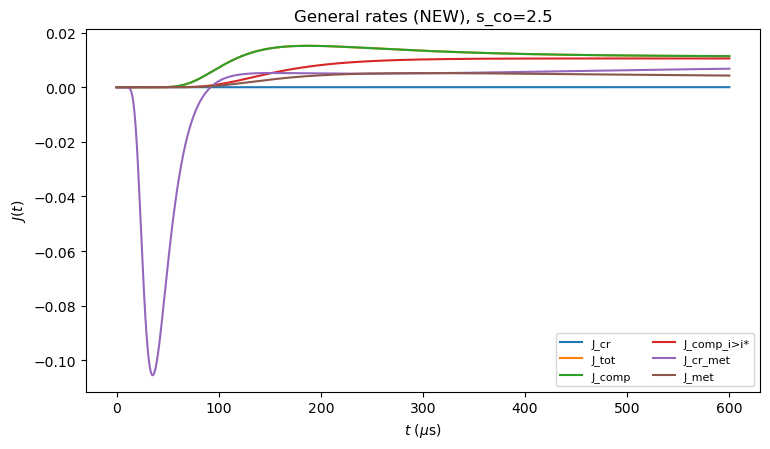

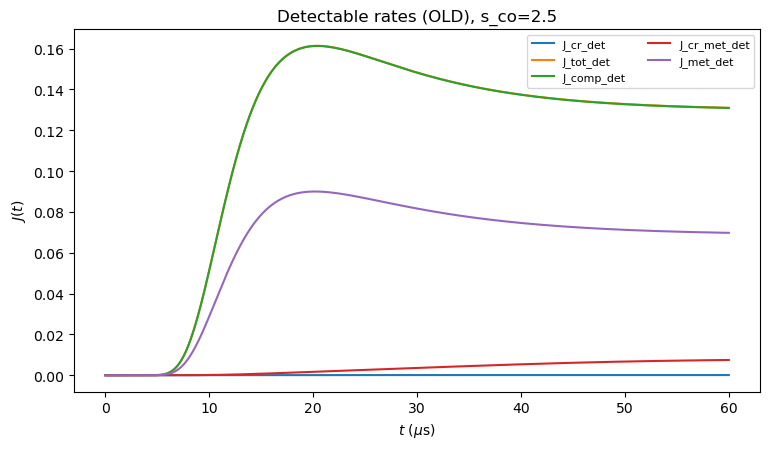

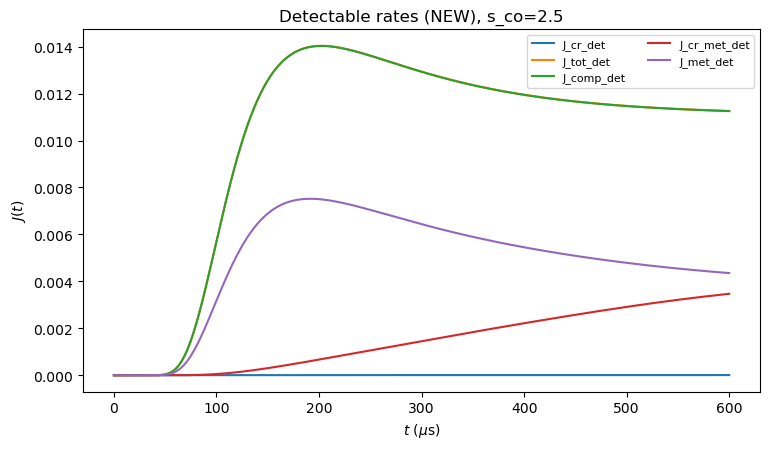

[Stage] s_co=3.0: precomputing W, C, coeffs …
[Done]  s_co=3.0: coeffs ready
[Solve] s_co=3.0: integrating OLD, t_max=60.00 μs …
[Solve] s_co=3.0: integrating NEW, t_max=0.60 ms …
[OLD] s_co=3.0: step 0/2999, t=0.000 μs
[OLD] s_co=3.0: step 200/2999, t=4.001 μs
[OLD] s_co=3.0: step 400/2999, t=8.003 μs
[OLD] s_co=3.0: step 600/2999, t=12.004 μs
[OLD] s_co=3.0: step 800/2999, t=16.005 μs
[OLD] s_co=3.0: step 1000/2999, t=20.007 μs
[OLD] s_co=3.0: step 1200/2999, t=24.008 μs
[OLD] s_co=3.0: step 1400/2999, t=28.009 μs
[OLD] s_co=3.0: step 1600/2999, t=32.011 μs
[OLD] s_co=3.0: step 1800/2999, t=36.012 μs
[OLD] s_co=3.0: step 2000/2999, t=40.013 μs
[OLD] s_co=3.0: step 2200/2999, t=44.015 μs
[OLD] s_co=3.0: step 2400/2999, t=48.016 μs
[OLD] s_co=3.0: step 2600/2999, t=52.017 μs
[OLD] s_co=3.0: step 2800/2999, t=56.019 μs
[NEW] s_co=3.0: step 0/2999, t=0.000 μs
[NEW] s_co=3.0: step 200/2999, t=40.013 μs
[NEW] s_co=3.0: step 400/2999, t=80.027 μs
[NEW] s_co=3.0: step 600/2999, t=120.040 μs


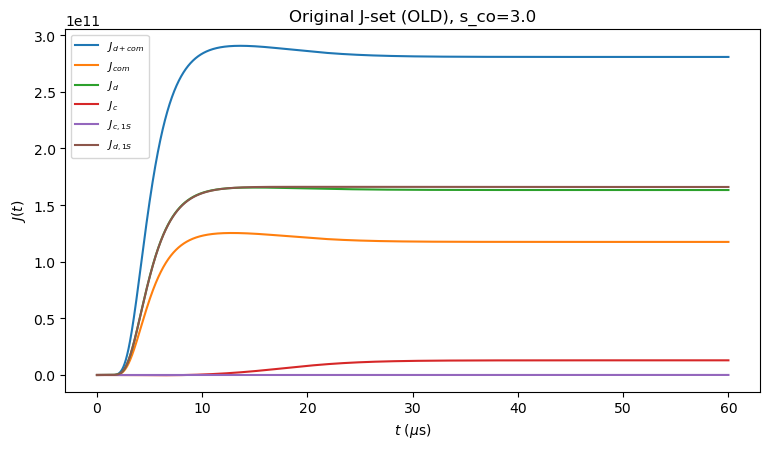

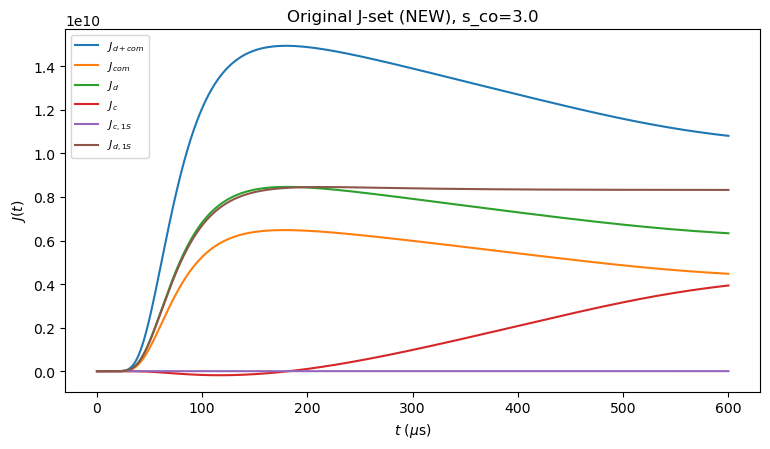

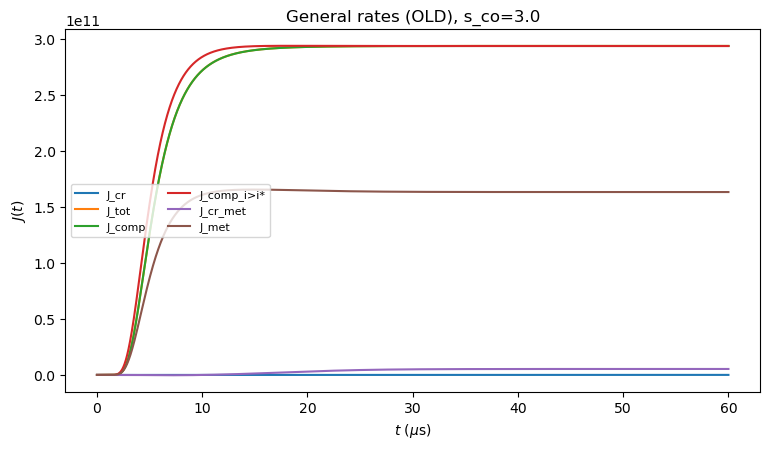

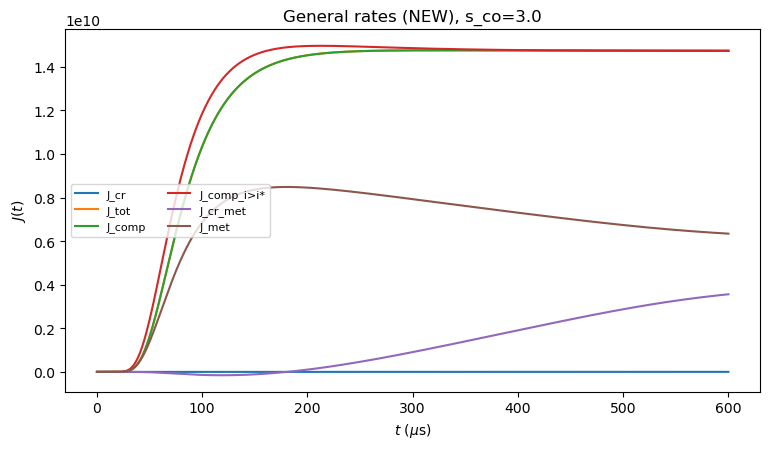

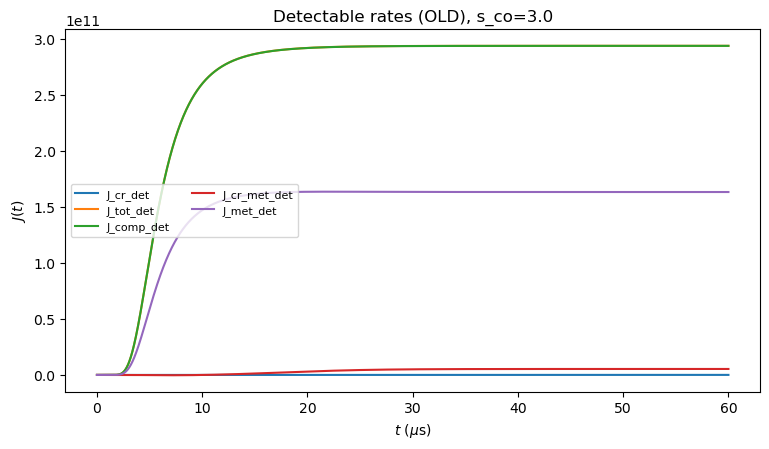

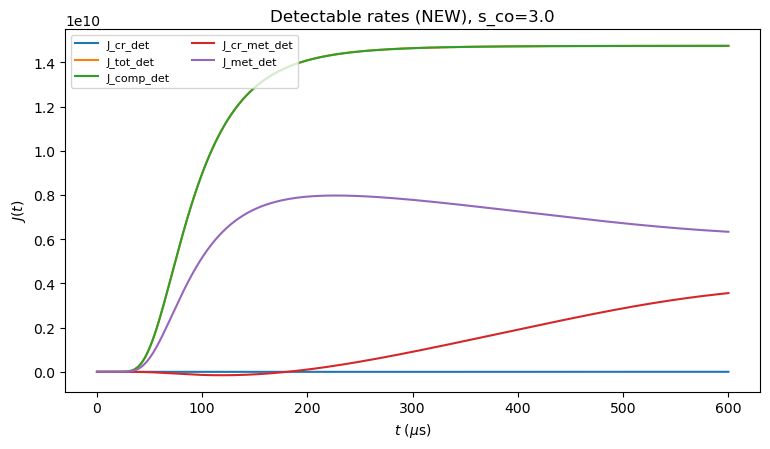

[Stage] s_co=5.0: precomputing W, C, coeffs …
[Done]  s_co=5.0: coeffs ready
[Solve] s_co=5.0: integrating OLD, t_max=60.00 μs …
[Solve] s_co=5.0: integrating NEW, t_max=0.60 ms …
[OLD] s_co=5.0: step 0/2999, t=0.000 μs


In [ ]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# Old vs New kinetics (attachment frequencies) comparison
# - Old: power-law fi ~ i^(2/3), gi ~ n^(2/3), ki ~ i^(2/3)
# - New: Boltzmann-symmetric rates with exp[-Δw/2]
# - Uses SciencePlots style if available
# - Old / New have different time windows
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Optional: SciencePlots for nicer figures
# ------------------------------------------------------------
try:
    import scienceplots  # pip install SciencePlots
    plt.style.use(['science', 'no-latex'])  # or ['science', 'notebook']
except Exception:
    # Fallback to default matplotlib style if SciencePlots not installed
    pass

# ------------------------
# 0) PARAMETERS
# ------------------------
T = 200.0
SCO_LIST = [2.5, 3.0, 5.0]
s_cm = 0.5
gamma_co, gamma_cm, gamma_mo = 15.4, 2.6, 12.8  # gamma_co = gamma_cm + gamma_mo

# kinetic prefactors (both old & new use these)
f0 = 1.0e5
g0 = 2.0e7
Q  = 0.5

C1_base = 1.6e21  # C1 = C1_base * exp(s_co)
M = 240           # max i (1 <= n <= i <= M-1)

# --- time windows (you can tune these) ---
t_max_old  = 60e-6      # OLD kinetics:  60 microseconds
N_eval_old = 3000

t_max_new  = 6e-4       # NEW kinetics:  6 milliseconds (100x longer, example)
N_eval_new = 3000

# max step in physical time (sec)
max_step = 1e-7
max_dx   = f0 * max_step   # max step in x = f0 t

# ------------------------
# 1) UTILS: triangular indexing (1 <= n <= i <= M-1)
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i+1):
            pair2idx[(i, n)] = k
            idx2pair.append((i, n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 2) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo):
    return -s_mo * i + gamma_mo * i**(2/3)

def w_cm(n):
    return -s_cm * n + gamma_cm * n**(2/3)

def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k, (i, n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1, 1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2*gamma_mo / (3*s_mo))**3
    n_star   = (2*gamma_cm / (3*s_cm))**3
    ico_star = (2*gamma_co / (3*s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ============================================================
# 3) Attachment frequencies: OLD vs NEW
# ============================================================

# ------------------------
# 3A) OLD model
# ------------------------
def f_in_val_old(i, s_co):
    return (1.0 - Q) * f0 * np.exp(s_co) * (i**(2/3))

def g_in_val_old(n):
    return g0 * np.exp(s_cm) * (n**(2/3))

def k_ii_val_old(i, s_co):
    return Q * f0 * np.exp(s_co) * (i**(2/3))

def build_coeffs_old(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)

    Wmap = {(i, n): W[PAIR2IDX[(i, n)]] for (i, n) in PAIR2IDX}

    for k, (i, n) in enumerate(IDX2PAIR):
        if n < i:
            b[k] = f_in_val_old(i, s_co) / f0
            d[k] = g_in_val_old(n)       / f0

            if i >= 2:
                a[k] = (f_in_val_old(i-1, s_co) / f0) * \
                       np.exp(Wmap[(i, n)] - Wmap[(i-1, n)])
            if n >= 2:
                c[k] = (g_in_val_old(n-1) / f0) * \
                       np.exp(Wmap[(i, n)] - Wmap[(i, n-1)])
        else:
            if i >= 2:
                e[k] = (k_ii_val_old(i-1, s_co) / f0) * \
                       np.exp(Wmap[(i, i)] - Wmap[(i-1, i-1)])
            h[k] = k_ii_val_old(i, s_co) / f0

    return a, b, c, d, e, h

# ------------------------
# 3B) NEW model
# ------------------------
def f_plus_new(i, n, s_co):
    if not (1 <= n <= i <= M-1):
        return 0.0
    w_in   = w_total_ij(i,   n, s_co)
    w_ip1n = w_total_ij(i+1, n, s_co)
    expo   = np.exp(-(w_in - w_ip1n) / 2.0)
    return (1.0 - Q) * f0 * expo * (i ** (2.0/3.0))

def g_plus_new(i, n, s_co):
    if not (1 <= n < i <= M-1):
        return 0.0
    w_in   = w_total_ij(i, n,   s_co)
    w_inp1 = w_total_ij(i, n+1, s_co)
    expo   = np.exp(-(w_in - w_inp1) / 2.0)
    return g0 * expo * (n ** (2.0/3.0))

def k_plus_new(i, s_co):
    if not (1 <= i <= M-1):
        return 0.0
    w_ii     = w_total_ij(i,   i,   s_co)
    w_ip1ip1 = w_total_ij(i+1, i+1, s_co)
    expo     = np.exp(-(w_ii - w_ip1ip1) / 2.0)
    return Q * f0 * expo * (i ** (2.0/3.0))

def build_coeffs_new(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)

    Wmap = {(i, n): W[PAIR2IDX[(i, n)]] for (i, n) in PAIR2IDX}

    for k, (i, n) in enumerate(IDX2PAIR):
        if n < i:
            b[k] = f_plus_new(i, n, s_co) / f0
            d[k] = g_plus_new(i, n, s_co) / f0

            if i >= 2 and n <= i-1:
                a[k] = (f_plus_new(i-1, n, s_co) / f0) * \
                       np.exp(Wmap[(i, n)] - Wmap[(i-1, n)])
            if n >= 2:
                c[k] = (g_plus_new(i, n-1, s_co) / f0) * \
                       np.exp(Wmap[(i, n)] - Wmap[(i, n-1)])
        else:
            if i >= 2:
                e[k] = (k_plus_new(i-1, s_co) / f0) * \
                       np.exp(Wmap[(i, i)] - Wmap[(i-1, i-1)])
            h[k] = k_plus_new(i, s_co) / f0

    return a, b, c, d, e, h

# ------------------------
# 4) Sparse Jacobian pattern
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []

    def add(r, c):
        rows.append(r); cols.append(c)

    for k, (i, n) in enumerate(IDX2PAIR):
        add(k, k)
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    S = sp.csr_matrix(
        (np.ones(len(rows), dtype=bool), (rows, cols)),
        shape=(Ntri, Ntri)
    )
    return S

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 5) RHS in x-domain: dF/dx
# ------------------------
def dFdx(x, F_flat, a, b, c, d, e, h):
    F = F_flat
    dF = np.zeros_like(F)

    # boundary F(1,1)=1
    F[PAIR2IDX[(1, 1)]] = 1.0

    for k, (i, n) in enumerate(IDX2PAIR):
        val = 0.0

        if n < i and i >= 2:
            val += a[k] * (F[PAIR2IDX[(i-1, n)]] - F[k])

        if n < i:
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            val -= b[k] * (F[k] - Fip)

        if n >= 2:
            val += c[k] * (F[PAIR2IDX[(i, n-1)]] - F[k])

        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k] * (F[k] - Finp)

        if n == i:
            if i >= 2:
                val += e[k] * (F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k] * (F[k] - Fipp)

        dF[k] = val

    return dF

# ------------------------
# 6) Fluxes I,G,K
# ------------------------
def fluxes_IGK_old(F_flat, C, s_co):
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat
    for (i, n), k in PAIR2IDX.items():
        Ckn = C[k]
        if n < i:
            fval = f_in_val_old(i, s_co)
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            I_map[(i, n)] = fval * Ckn * (F[k] - Fip)
        if n < i:
            gval = g_in_val_old(n)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i, n)] = gval * Ckn * (F[k] - Finp)
        if n == i:
            kval = k_ii_val_old(i, s_co)
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i, i)] = kval * Ckn * (F[k] - Fipp)
    return I_map, G_map, K_map

def fluxes_IGK_new(F_flat, C, s_co):
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat
    for (i, n), k in PAIR2IDX.items():
        Ckn = C[k]
        if n < i:
            fval = f_plus_new(i, n, s_co)
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            I_map[(i, n)] = fval * Ckn * (F[k] - Fip)
        if n < i:
            gval = g_plus_new(i, n, s_co)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i, n)] = gval * Ckn * (F[k] - Finp)
        if n == i:
            kval = k_plus_new(i, s_co)
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i, i)] = kval * Ckn * (F[k] - Fipp)
    return I_map, G_map, K_map

# ------------------------
# 7) J from fluxes
# ------------------------
def Js_from_fluxes(I_map, G_map, K_map, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)

    gi = lambda i, n: G_map.get((i, n), 0.0)
    ii = lambda i, n: I_map.get((i, n), 0.0)
    kk = lambda i:    K_map.get((i, i), 0.0)

    J_dcom = sum(ii(i_star, n) for n in range(1, i_star+1))
    for i in range(i_star+1, M):
        J_dcom += ii(i, i) - gi(i, i-1)

    J_d = ii(i_star, 1) - sum(gi(i, 1) for i in range(i_star+1, M))
    J_com = J_dcom - J_d

    J_c = kk(ico_star)
    for i in range(ico_star+1, M):
        J_c += gi(i, i-1) - ii(i, i)

    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)

    return {
        "J_d+com": J_dcom,
        "J_com":   J_com,
        "J_d":     J_d,
        "J_c":     J_c,
        "J_c,1S":  J_c_1S,
        "J_d,1S":  J_d_1S
    }

def Js_from_fluxes_figure(I_map, G_map, K_map, s_co, d=None):
    i_star, n_star, ico_star = crit_sizes(s_co)
    if d is None:
        d = min(ico_star + 1, M - 1)

    def I(i, n): return I_map.get((i, n), 0.0)
    def G(i, n): return G_map.get((i, n), 0.0)
    def K_diag(i): return K_map.get((i, i), 0.0)

    J_cr_det = K_diag(d) + sum(G(i, i) - I(i, i) for i in range(d, M))
    J_cr     = K_diag(ico_star) + sum(G(i, i) - I(i, i) for i in range(ico_star, M))

    J_tot_det = K_diag(d) + sum(I(d, n) for n in range(1, d+1))
    J_tot     = K_diag(ico_star) + sum(I(ico_star, n) for n in range(1, ico_star+1))

    J_comp_det = (
        sum(I(d, n) for n in range(1, d+1)) +
        sum(I(i, i) - G(i, i) for i in range(d, M))
    )
    J_comp = (
        sum(I(ico_star, n) for n in range(1, ico_star+1)) +
        sum(I(i, i) - G(i, i) for i in range(ico_star, M))
    )

    J_comp_i_gt_istar = (
        sum(I(i_star, n) for n in range(1, i_star+1)) +
        sum(I(i, i) - G(i, i) for i in range(i_star, M))
    )

    J_cr_met_det = (
        sum(I(i, i) for i in range(d, M)) +
        sum(G(i, d) - G(i, i) for i in range(d, M))
    )
    J_cr_met = (
        sum(I(i, i) for i in range(n_star, M)) +
        sum(G(i, n_star) - G(i, i) for i in range(n_star, M))
    )

    J_met_det = I(d, 1) - sum(G(i, 1) for i in range(d, M))
    J_met     = I(i_star, 1) - sum(G(i, 1) for i in range(i_star, M))

    return {
        "J_cr_det":      J_cr_det,
        "J_cr":          J_cr,
        "J_tot_det":     J_tot_det,
        "J_tot":         J_tot,
        "J_comp_det":    J_comp_det,
        "J_comp":        J_comp,
        "J_comp_i>i*":   J_comp_i_gt_istar,
        "J_cr_met_det":  J_cr_met_det,
        "J_cr_met":      J_cr_met,
        "J_met_det":     J_met_det,
        "J_met":         J_met,
    }

# ------------------------
# 8) MAIN SESSION: old vs new with separate time windows
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co}: precomputing W, C, coeffs …")
    W, C = make_wC(s_co)
    a_old, b_old, c_old, d_old, e_old, h_old = build_coeffs_old(W, s_co)
    a_new, b_new, c_new, d_new, e_new, h_new = build_coeffs_new(W, s_co)
    print(f"[Done]  s_co={s_co}: coeffs ready")

    # initial condition
    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1, 1)]] = 1.0

    # ---- OLD: time grid & solve ----
    t_eval_old = np.linspace(0.0, t_max_old, N_eval_old)
    x_eval_old = f0 * t_eval_old

    print(f"[Solve] s_co={s_co}: integrating OLD, t_max={t_max_old*1e6:.2f} μs …")
    sol_old = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a_old, b_old, c_old, d_old, e_old, h_old),
        t_span=(0.0, x_eval_old[-1]),
        y0=F0,
        method='BDF',
        t_eval=x_eval_old,
        jac_sparsity=JAC_SP,
        rtol=1e-6,
        atol=1e-9,
        max_step=max_dx
    )
    if not sol_old.success:
        raise RuntimeError(f"[OLD] solve_ivp failed: {sol_old.message}")

    # ---- NEW: time grid & solve ----
    t_eval_new = np.linspace(0.0, t_max_new, N_eval_new)
    x_eval_new = f0 * t_eval_new

    print(f"[Solve] s_co={s_co}: integrating NEW, t_max={t_max_new*1e3:.2f} ms …")
    sol_new = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a_new, b_new, c_new, d_new, e_new, h_new),
        t_span=(0.0, x_eval_new[-1]),
        y0=F0,
        method='BDF',
        t_eval=x_eval_new,
        jac_sparsity=JAC_SP,
        rtol=1e-6,
        atol=1e-9,
        max_step=max_dx
    )
    if not sol_new.success:
        raise RuntimeError(f"[NEW] solve_ivp failed: {sol_new.message}")

    # time grids in x and μs
    t_x_old  = sol_old.t
    t_us_old = t_x_old / f0 * 1e6

    t_x_new  = sol_new.t
    t_us_new = t_x_new / f0 * 1e6

    # rate names
    old_names = ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]
    general_names = ["J_cr", "J_tot", "J_comp", "J_comp_i>i*", "J_cr_met", "J_met"]
    det_names     = ["J_cr_det", "J_tot_det", "J_comp_det", "J_cr_met_det", "J_met_det"]

    # allocate arrays
    curves_orig_old = {k: np.zeros_like(t_x_old) for k in old_names}
    curves_orig_new = {k: np.zeros_like(t_x_new) for k in old_names}
    curves_gen_old  = {k: np.zeros_like(t_x_old) for k in general_names}
    curves_gen_new  = {k: np.zeros_like(t_x_new) for k in general_names}
    curves_det_old  = {k: np.zeros_like(t_x_old) for k in det_names}
    curves_det_new  = {k: np.zeros_like(t_x_new) for k in det_names}

    # ---- OLD: time loop ----
    for j, x in enumerate(t_x_old):
        F_old = sol_old.y[:, j]
        I_old, G_old, K_old = fluxes_IGK_old(F_old, C, s_co)

        Js_old_orig = Js_from_fluxes(I_old, G_old, K_old, s_co)
        Js_old_fig  = Js_from_fluxes_figure(I_old, G_old, K_old, s_co)

        for name in old_names:
            curves_orig_old[name][j] = Js_old_orig[name]
        for name in general_names:
            curves_gen_old[name][j]  = Js_old_fig[name]
        for name in det_names:
            curves_det_old[name][j]  = Js_old_fig[name]

        if j % 200 == 0:
            print(f"[OLD] s_co={s_co}: step {j}/{len(t_x_old)-1}, t={x/f0*1e6:.3f} μs")

    # ---- NEW: time loop ----
    for j, x in enumerate(t_x_new):
        F_new = sol_new.y[:, j]
        I_new, G_new, K_new = fluxes_IGK_new(F_new, C, s_co)

        Js_new_orig = Js_from_fluxes(I_new, G_new, K_new, s_co)
        Js_new_fig  = Js_from_fluxes_figure(I_new, G_new, K_new, s_co)

        for name in old_names:
            curves_orig_new[name][j] = Js_new_orig[name]
        for name in general_names:
            curves_gen_new[name][j]  = Js_new_fig[name]
        for name in det_names:
            curves_det_new[name][j]  = Js_new_fig[name]

        if j % 200 == 0:
            print(f"[NEW] s_co={s_co}: step {j}/{len(t_x_new)-1}, t={x/f0*1e6:.3f} μs")

    print(f"[Done]  s_co={s_co}: rates computed (OLD & NEW)")

    # ---- final values printout ----
    print(f"\n[Rates-OLD] s_co={s_co}: final at t={t_us_old[-1]:.3f} μs")
    for name in general_names:
        print(f"    {name:12s} = {curves_gen_old[name][-1]: .5e}")
    for name in det_names:
        print(f"    {name:12s} (det) = {curves_det_old[name][-1]: .5e}")

    print(f"\n[Rates-NEW] s_co={s_co}: final at t={t_us_new[-1]:.3f} μs")
    for name in general_names:
        print(f"    {name:12s} = {curves_gen_new[name][-1]: .5e}")
    for name in det_names:
        print(f"    {name:12s} (det) = {curves_det_new[name][-1]: .5e}")
    print()

    # ------------------------
    # 9) PLOTTING: OLD only / NEW only
    # ------------------------
    label_map_orig = {
        "J_d+com": r"$J_{d+com}$",
        "J_com":   r"$J_{com}$",
        "J_d":     r"$J_d$",
        "J_c":     r"$J_c$",
        "J_c,1S":  r"$J_{c,1S}$",
        "J_d,1S":  r"$J_{d,1S}$"
    }

    # (A) Original J-set: OLD
    plt.figure(figsize=(7.8, 4.6))
    for name in old_names:
        plt.plot(t_us_old, curves_orig_old[name], label=label_map_orig[name])
    plt.xlabel(r"$t$ ($\mu$s)")
    plt.ylabel(r"$J(t)$")
    plt.title(f"Original J-set (OLD), s_co={s_co}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # (A') Original J-set: NEW
    plt.figure(figsize=(7.8, 4.6))
    for name in old_names:
        plt.plot(t_us_new, curves_orig_new[name], label=label_map_orig[name])
    plt.xlabel(r"$t$ ($\mu$s)")
    plt.ylabel(r"$J(t)$")
    plt.title(f"Original J-set (NEW), s_co={s_co}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # (B) General J-set: OLD
    plt.figure(figsize=(7.8, 4.6))
    for name in general_names:
        plt.plot(t_us_old, curves_gen_old[name], label=name)
    plt.xlabel(r"$t$ ($\mu$s)")
    plt.ylabel(r"$J(t)$")
    plt.title(f"General rates (OLD), s_co={s_co}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    # (B') General J-set: NEW
    plt.figure(figsize=(7.8, 4.6))
    for name in general_names:
        plt.plot(t_us_new, curves_gen_new[name], label=name)
    plt.xlabel(r"$t$ ($\mu$s)")
    plt.ylabel(r"$J(t)$")
    plt.title(f"General rates (NEW), s_co={s_co}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    # (C) Detectable J-set: OLD
    plt.figure(figsize=(7.8, 4.6))
    for name in det_names:
        plt.plot(t_us_old, curves_det_old[name], label=name)
    plt.xlabel(r"$t$ ($\mu$s)")
    plt.ylabel(r"$J(t)$")
    plt.title(f"Detectable rates (OLD), s_co={s_co}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    # (C') Detectable J-set: NEW
    plt.figure(figsize=(7.8, 4.6))
    for name in det_names:
        plt.plot(t_us_new, curves_det_new[name], label=name)
    plt.xlabel(r"$t$ ($\mu$s)")
    plt.ylabel(r"$J(t)$")
    plt.title(f"Detectable rates (NEW), s_co={s_co}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

# ------------------------
# 10) RUN
# ------------------------
for sco in SCO_LIST:
    run_session(sco)
